# ⚡ Estudio Predictivo y Exploratorio del Mercado Global de Vehículos Eléctricos (2020-2026)

## 📝 Introducción y Alcance del Estudio
El sector de la automoción está viviendo la mayor transformación de su historia reciente a través de la electrificación. Este estudio avanzado de ciencia de datos tiene como objetivo analizar la estructura, el comportamiento y las dinámicas comerciales del mercado global de vehículos eléctricos (EV) en un período crítico de maduración tecnológica y adopción: **2020 a 2026**.

A través de un dataset robusto de **2,000 registros y 24 variables comerciales y técnicas**, este cuaderno aborda el problema desde una doble perspectiva: **Business Intelligence (Entendimiento del negocio)** y **Advanced Analytics / Machine Learning (Modelado predictivo)**. El fin último es responder a las preguntas estratégicas que determinan el éxito de un producto en esta industria: *¿Qué hace que un vehículo eléctrico se venda?*, *¿Cómo se fija su precio de forma óptima?* y *¿Qué busca realmente el consumidor actual?*

---

## 🎯 Objetivos Estratégicos y Casos de Uso
El análisis no se limita a una exploración superficial de los datos, sino que está guiado por un plan analítico estructurado en **8 casos de uso de negocio**:

1. **Modelado Predictivo de Precios (ML):** Desarrollar y evaluar algoritmos capaces de predecir el coste de un EV basándose en su ingeniería y segmento.
2. **Análisis de Valor (Eficiencia vs. Coste):** Identificar qué modelos ofrecen el mejor retorno de inversión en autonomía por cada dólar invertido y detectar anomalías o vehículos sobrevalorados.
3. **Panel Multidimensional de Marcas:** Comparar el rendimiento de los 16 principales fabricantes en términos de precio, autonomía, carga, satisfacción y seguridad.
4. **Evolución de Cuotas de Mercado:** Monitorear la trayectoria de ventas según el tipo de carrocería, segmento comercial y país de origen a lo largo de los 7 años del histórico.
5. **Maduración de la Tecnología de Baterías:** Auditar si realmente ha existido un salto disruptivo en la capacidad, velocidad de carga y eficiencia energética (millas/kWh) año tras año.
6. **Drivers de Satisfacción del Cliente:** Utilizar técnicas de importancia de variables (*Feature Importance*) para descubrir qué factores mueven realmente la aguja de la valoración del usuario.
7. **Elasticidad e Impulsores de Venta:** Determinar el peso real del activo intangible de la marca frente a las especificaciones técnicas puras al momento de traccionar volumen de ventas.
8. **Estratificación del Mercado (Budget vs. Luxury):** Contrastar el comportamiento de los modelos económicos (<$35k) frente a los de gran lujo (>$100k) para descubrir el verdadero "punto dulce" (*sweet spot*) de compra.

---

## 🛠️ Stack Tecnológico Utilizado
Para asegurar la reproducibilidad, la escalabilidad y el rigor estadístico del estudio, se ha construido un pipeline de datos de extremo a extremo utilizando el ecosistema científico de **Python**:

* **Manipulación y Procesamiento de Datos:** `pandas` y `numpy`.
* **Visualización Avanzada y Análisis Exploratorio (EDA):** `matplotlib` y `seaborn`.
* **Modelado Predictivo y Machine Learning:** `scikit-learn` (implementando Regresión Lineal, Ridge, Gradient Boosting y Random Forest Regressor).
* **Validación Estadística:** `scipy.stats` (para pruebas no paramétricas de contraste de hipótesis).

---
*Nota: Este pipeline de datos y sus conclusiones analíticas sirven como base de datos enriquecida para el despliegue posterior del cuadro de mando interactivo en **Power BI**.*

# 1) Importar galerias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# 2) Importar funciones

In [2]:
def exploracion_inicial(df, tipo=None):
    print("¿Cuántas filas y columnas hay en el conjunto de datos?")
    num_filas, num_columnas = df.shape
    print(f"\tHay {num_filas:,} filas y {num_columnas:,} columnas.")
    print('#' * 90)

    if tipo == 'simple':
        print("¿Cuáles son las primeras dos filas del conjunto de datos?")
        display(df.head(2))
    else:
        print("¿Cuáles son las primeras cinco filas del conjunto de datos?")
        display(df.head())

        print("¿Cuáles son las últimas cinco filas del conjunto de datos?")
        display(df.tail())

        print("¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?")
        display(df.sample(n=5))

        print("¿Cuáles son las columnas del conjunto de datos?")
        print("\n".join(f"\t- {col}" for col in df.columns))

        print("¿Cuál es el tipo de datos de cada columna?")
        print(df.dtypes)

        print("¿Cuántas columnas hay de cada tipo de datos?")
        print(df.dtypes.value_counts())

        print("¿Cómo podríamos obtener información más completa sobre la estructura y el contenido del DataFrame?")
        df.info()

        print("¿Cuántos valores únicos tiene cada columna?")
        print(df.nunique())

        print("¿Cuáles son las estadísticas descriptivas básicas de todas las columnas?")
        display(df.describe(include='all').fillna(''))

        print("¿Hay valores nulos en el conjunto de datos?")
        print(df.isnull().sum())

        print("¿Cuál es la proporción de valores nulos en cada columna?")
        print((df.isnull().sum() / len(df) * 100).round(2))

        print("¿Cuántas filas duplicadas hay?")
        print(df.duplicated().sum())
        

    print('#' * 90)

# 3) Cargar Dataset

In [3]:
df = pd.read_csv(r"C:\Users\andy_\Documents\Datasets\ev_market_2026.csv")
df.head(5)

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
0,Volkswagen,ID. Buzz,2023,Performance,104880.80,118.7,400.0,234.5,3.04,195.0,...,Truck,54.2,2015.0,4,2,Germany,Luxury,202182,4.00,4
1,Toyota,bZ Compact SUV,2022,Premium,48217.41,58.8,219.0,148.1,5.77,159.0,...,SUV,69.0,1709.0,4,0,Japan,Mid-range,7146,3.56,3
2,GM/Chevrolet,Bolt EV,2024,Premium,49651.12,58.2,225.0,104.9,6.84,148.0,...,Van,77.0,1533.0,4,1,US,Mid-range,16590,3.70,3
3,Kia,Sportage EV,2024,Long Range,38131.56,102.5,349.0,66.5,4.66,176.0,...,SUV,65.8,1935.0,4,2,South Korea,Mid-range,127201,3.81,3
4,Tesla,Model 3,2022,Long Range,144079.87,93.9,314.0,298.5,5.64,165.0,...,SUV,38.3,2229.0,4,2,US,Luxury,196401,3.83,4


# 4) ETL

In [4]:
exploracion_inicial(df)

¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 2,000 filas y 24 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
0,Volkswagen,ID. Buzz,2023,Performance,104880.80,118.7,400.0,234.5,3.04,195.0,...,Truck,54.2,2015.0,4,2,Germany,Luxury,202182,4.00,4
1,Toyota,bZ Compact SUV,2022,Premium,48217.41,58.8,219.0,148.1,5.77,159.0,...,SUV,69.0,1709.0,4,0,Japan,Mid-range,7146,3.56,3
2,GM/Chevrolet,Bolt EV,2024,Premium,49651.12,58.2,225.0,104.9,6.84,148.0,...,Van,77.0,1533.0,4,1,US,Mid-range,16590,3.70,3
3,Kia,Sportage EV,2024,Long Range,38131.56,102.5,349.0,66.5,4.66,176.0,...,SUV,65.8,1935.0,4,2,South Korea,Mid-range,127201,3.81,3
4,Tesla,Model 3,2022,Long Range,144079.87,93.9,314.0,298.5,5.64,165.0,...,SUV,38.3,2229.0,4,2,US,Luxury,196401,3.83,4


¿Cuáles son las últimas cinco filas del conjunto de datos?


,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
1995,BMW,i3,2023,Long Range,122665.71,102.1,360.0,92.0,4.21,190.0,...,Hatchback,38.3,1500.0,5,2,Germany,Luxury,66187,3.78,7
1996,Toyota,bZ4X,2024,Performance,66816.55,110.6,367.0,236.3,4.25,181.0,...,Hatchback,23.1,1863.0,4,0,Japan,Premium,11062,3.79,4
1997,Tesla,Model 3,2025,Long Range,49281.26,90.6,325.0,325.6,5.55,167.0,...,Truck,74.6,2920.0,3,3,US,Mid-range,224804,4.10,6
1998,Tesla,Model X,2026,Premium,139665.73,70.7,248.0,330.7,5.07,175.0,...,Coupe,34.8,1500.0,3,2,US,Luxury,165373,3.66,4
1999,BYD,Qin,2025,Premium,47547.88,67.4,246.0,67.2,6.76,156.0,...,Coupe,28.5,1512.0,4,0,China,Mid-range,214113,3.41,4


¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
1920,GM/Chevrolet,Silverado EV,2024,Premium,80871.59,62.6,196.0,135.2,5.27,170.0,...,Hatchback,15.1,1778.0,3,1,US,Premium,24840,3.52,3
1697,Tesla,Model X,2021,Long Range,118192.05,92.9,329.0,280.7,5.55,162.0,...,Coupe,18.7,1733.0,5,2,US,Luxury,123098,3.96,5
547,BMW,i7,2026,Performance,116974.41,71.9,251.0,175.3,3.87,190.0,...,Truck,53.7,2650.0,5,2,Germany,Luxury,50944,3.38,6
162,BMW,i5,2025,Standard,97046.62,60.0,209.0,79.6,7.79,131.0,...,Hatchback,18.3,1510.0,5,2,Germany,Premium,66065,3.41,5
1557,Volkswagen,ID. Aero,2022,Long Range,73265.41,102.2,363.0,88.3,4.82,187.0,...,Truck,50.8,2433.0,3,1,Germany,Premium,255210,3.55,4


¿Cuáles son las columnas del conjunto de datos?
	- brand
	- model
	- year
	- variant
	- price_usd
	- battery_capacity_kwh
	- range_miles
	- charging_speed_kw
	- acceleration_0_60_mph
	- top_speed_mph
	- horsepower
	- torque_nm
	- drive_type
	- seating_capacity
	- body_type
	- cargo_volume_cubic_ft
	- weight_kg
	- safety_rating
	- autopilot_level
	- country_of_origin
	- market_segment
	- annual_sales_units
	- customer_rating
	- warranty_years
¿Cuál es el tipo de datos de cada columna?
brand                        str
model                        str
year                       int64
variant                      str
price_usd                float64
battery_capacity_kwh     float64
range_miles              float64
charging_speed_kw        float64
acceleration_0_60_mph    float64
top_speed_mph            float64
horsepower               float64
torque_nm                float64
drive_type                   str
seating_capacity           int64
body_type                    str
cargo_volume_cub

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
count,2000,2000,2000.0,2000,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,...,2000,2000.0,2000.0,2000.0,2000.0,2000,2000,2000.0,2000.0,2000.0
unique,20,76,,5,,,,,,,...,6,,,,,6,4,,,
top,Tesla,Model S,,Base,,,,,,,...,Truck,,,,,US,Premium,,,
freq,434,93,,420,,,,,,,...,427,,,,,774,712,,,
mean,,,2024.0285,,78873.90715,74.6628,261.8255,155.2063,5.630635,164.8845,...,,46.10585,1886.1645,4.377,1.1245,,,129653.592,3.572045,4.579
std,,,1.410561,,35296.621782,20.082879,71.028238,80.982301,1.417733,20.781244,...,,19.850264,383.772906,0.661127,0.919469,,,105775.154465,0.270398,1.218812
min,,,2020.0,,16394.33,40.0,150.0,50.0,2.5,118.0,...,,15.0,1500.0,3.0,0.0,,,656.0,3.0,3.0
25%,,,2023.0,,52325.92,58.475,204.0,90.975,4.62,148.0,...,,28.175,1570.0,4.0,0.0,,,44296.5,3.38,4.0
50%,,,2024.0,,73013.015,75.1,261.0,132.1,5.67,165.0,...,,41.25,1740.5,4.0,1.0,,,111188.0,3.56,4.0
75%,,,2025.0,,99780.1575,87.55,310.0,217.3,6.77,181.0,...,,64.7,2149.5,5.0,2.0,,,202496.75,3.75,5.0


¿Hay valores nulos en el conjunto de datos?
brand                    0
model                    0
year                     0
variant                  0
price_usd                0
battery_capacity_kwh     0
range_miles              0
charging_speed_kw        0
acceleration_0_60_mph    0
top_speed_mph            0
horsepower               0
torque_nm                0
drive_type               0
seating_capacity         0
body_type                0
cargo_volume_cubic_ft    0
weight_kg                0
safety_rating            0
autopilot_level          0
country_of_origin        0
market_segment           0
annual_sales_units       0
customer_rating          0
warranty_years           0
dtype: int64
¿Cuál es la proporción de valores nulos en cada columna?
brand                    0.0
model                    0.0
year                     0.0
variant                  0.0
price_usd                0.0
battery_capacity_kwh     0.0
range_miles              0.0
charging_speed_kw        0.0
accele

### 4.1) Bloque de validación previo a EDA

### 4.2) Outliers

In [5]:
cols_numericas = [
    'price_usd', 'battery_capacity_kwh', 'range_miles',
    'charging_speed_kw', 'acceleration_0_60_mph', 'top_speed_mph',
    'horsepower', 'torque_nm', 'cargo_volume_cubic_ft',
    'weight_kg', 'annual_sales_units', 'customer_rating'
]

resumen_outliers = []
for col in cols_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    resumen_outliers.append({
        'columna': col,
        'min': df[col].min(),
        'max': df[col].max(),
        'límite_inferior': round(lower, 2),
        'límite_superior': round(upper, 2),
        'n_outliers': n_out,
        '% sobre total': round(n_out / len(df) * 100, 2)
    })

pd.DataFrame(resumen_outliers).set_index('columna')

,min,max,límite_inferior,límite_superior,n_outliers,% sobre total
columna,,,,,,
price_usd,16394.33,269775.20,-18855.44,170961.51,32,1.60
battery_capacity_kwh,40.00,119.90,14.86,131.16,0,0.00
range_miles,150.00,447.00,45.00,469.00,0,0.00
charging_speed_kw,50.00,349.90,-98.51,406.79,0,0.00
acceleration_0_60_mph,2.50,8.00,1.40,9.99,0,0.00
top_speed_mph,118.00,200.00,98.50,230.50,0,0.00
horsepower,150.00,1000.00,-302.00,1684.00,0,0.00
torque_nm,200.00,988.00,-288.12,1524.88,0,0.00
cargo_volume_cubic_ft,15.00,80.00,-26.61,119.49,0,0.00


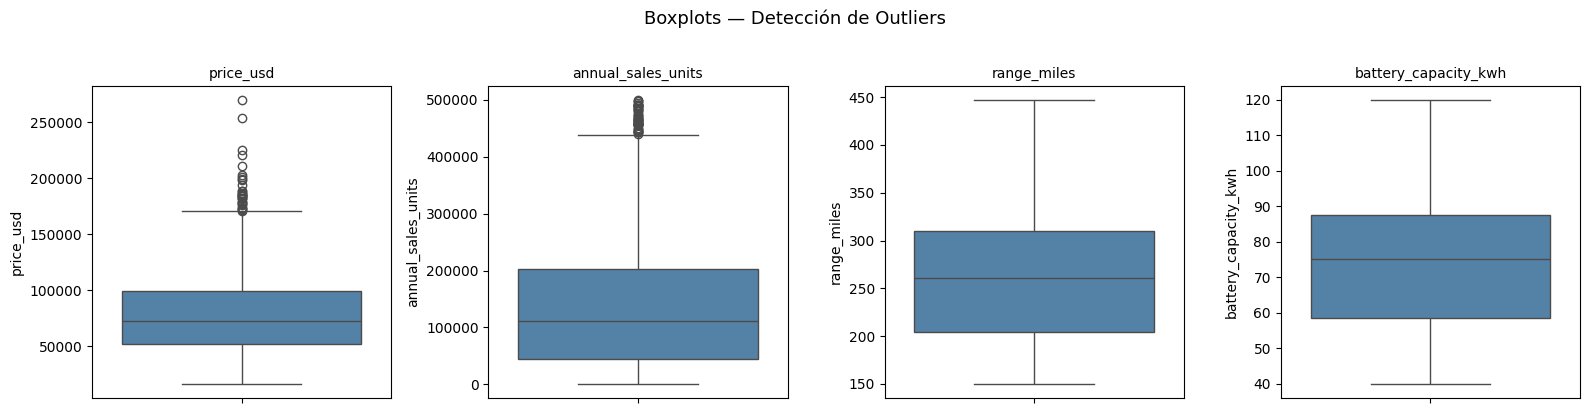

In [6]:
# Boxplots visuales para las columnas con más outliers
cols_plot = ['price_usd', 'annual_sales_units', 'range_miles', 'battery_capacity_kwh']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, cols_plot):
    sns.boxplot(y=df[col], ax=ax, color='steelblue')
    ax.set_title(col, fontsize=10)
plt.suptitle('Boxplots — Detección de Outliers', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4.3)  Rangos lógicos
Verificamos que las columnas ordinales y acotadas tengan valores dentro del dominio esperado.

In [7]:
rangos_esperados = {
    'year':            (2015, 2026),
    'safety_rating':   (1, 5),
    'autopilot_level': (0, 5),
    'customer_rating': (0.0, 5.0),
    'warranty_years':  (1, 20),
    'seating_capacity':(2, 9),
    'price_usd':       (10_000, 500_000),
    'range_miles':     (50, 700),
    'horsepower':      (50, 2000),
}

print(f"{'Columna':<22} {'Min':>10} {'Max':>10}  {'Rango esperado':<20} {'Fuera de rango':>14}")
print('-' * 80)
for col, (lo, hi) in rangos_esperados.items():
    fuera = ((df[col] < lo) | (df[col] > hi)).sum()
    estado = '✅' if fuera == 0 else f'⚠️  {fuera} filas'
    print(f"{col:<22} {df[col].min():>10.1f} {df[col].max():>10.1f}  [{lo}, {hi}]{'':>10} {estado}")

Columna                       Min        Max  Rango esperado       Fuera de rango
--------------------------------------------------------------------------------
year                       2020.0     2026.0  [2015, 2026]           ✅
safety_rating                 3.0        5.0  [1, 5]           ✅
autopilot_level               0.0        3.0  [0, 5]           ✅
customer_rating               3.0        4.5  [0.0, 5.0]           ✅
warranty_years                3.0        8.0  [1, 20]           ✅
seating_capacity              2.0        7.0  [2, 9]           ✅
price_usd                 16394.3   269775.2  [10000, 500000]           ✅
range_miles                 150.0      447.0  [50, 700]           ✅
horsepower                  150.0     1000.0  [50, 2000]           ✅


### 4.4)  Cardinalidad de variables categóricas
Cuántas categorías únicas tiene cada variable y si alguna está muy poco representada.

In [8]:
cols_cat = ['brand', 'country_of_origin', 'body_type', 'drive_type', 'market_segment', 'variant']

for col in cols_cat:
    vc = df[col].value_counts()
    raras = (vc < 10).sum()   # categorías con menos de 10 registros
    print(f"\n{'='*50}")
    print(f"📂 {col}  |  {vc.shape[0]} categorías únicas  |  {raras} con < 10 registros")
    print(vc.head(10).to_string())
    if raras > 0:
        print(f"  ⚠️  Categorías poco representadas: {list(vc[vc < 10].index)}")


📂 brand  |  20 categorías únicas  |  4 con < 10 registros
brand
Tesla           434
BYD             282
Volkswagen      194
Kia             166
Hyundai         152
BMW             150
GM/Chevrolet    143
Ford            129
Mercedes         96
Audi             77
  ⚠️  Categorías poco representadas: ['Polestar', 'Xiaomi', 'Lucid', 'Honda']

📂 country_of_origin  |  6 categorías únicas  |  0 con < 10 registros
country_of_origin
US             774
Germany        531
South Korea    318
China          313
Japan           43
Sweden          21

📂 body_type  |  6 categorías únicas  |  0 con < 10 registros
body_type
Truck        427
SUV          364
Hatchback    324
Coupe        303
Sedan        301
Van          281

📂 drive_type  |  3 categorías únicas  |  0 con < 10 registros
drive_type
AWD    754
RWD    678
FWD    568

📂 market_segment  |  4 categorías únicas  |  0 con < 10 registros
market_segment
Premium      712
Mid-range    642
Luxury       495
Budget       151

📂 variant  |  5 categor

C:\Users\andy_\AppData\Local\Temp\ipykernel_16624\1592646238.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=orden, ax=ax, palette='Blues_r')
C:\Users\andy_\AppData\Local\Temp\ipykernel_16624\1592646238.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=orden, ax=ax, palette='Blues_r')
C:\Users\andy_\AppData\Local\Temp\ipykernel_16624\1592646238.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=orden, ax=ax, palette='Blues_r')
C:\Users\andy_\AppData\Local\Temp\ipy

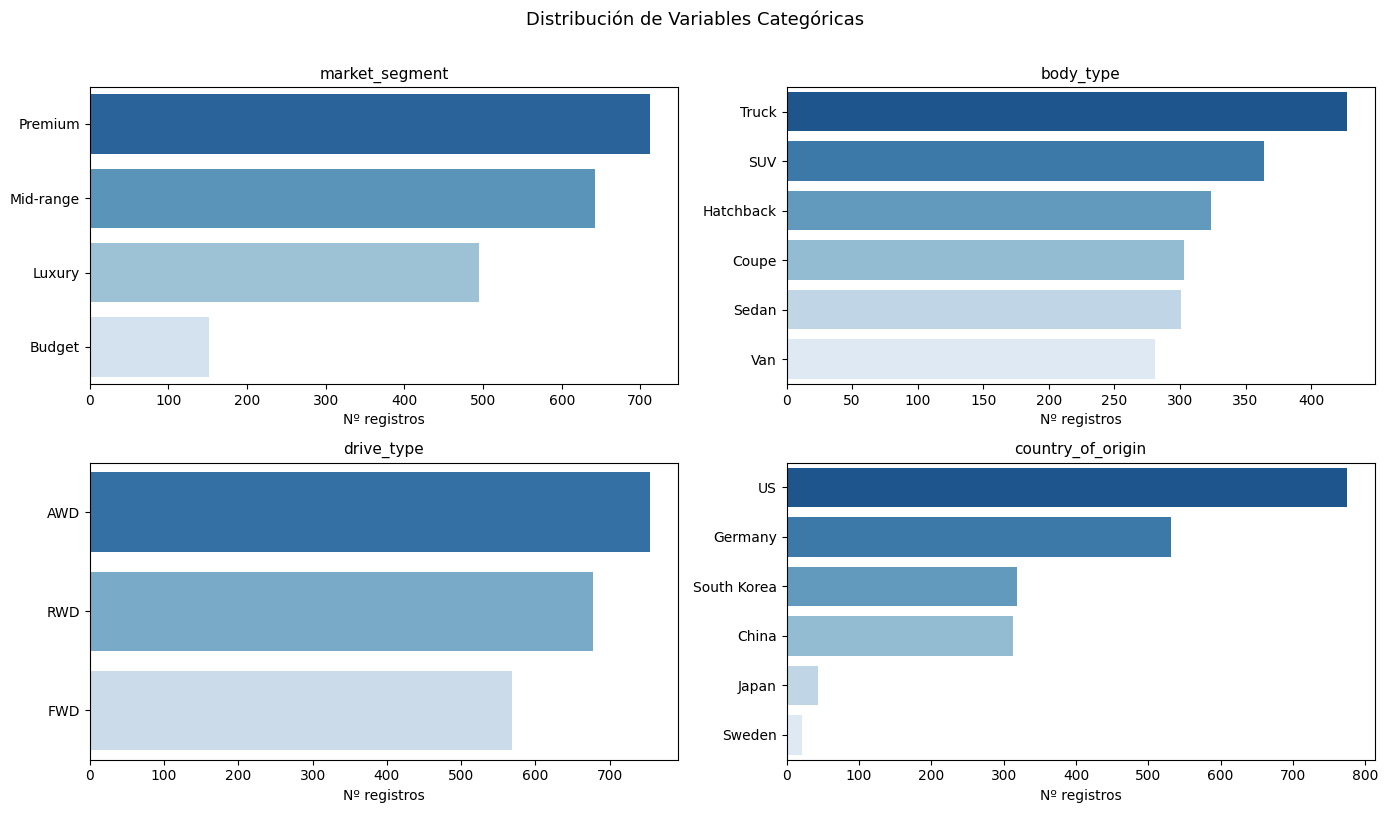

In [9]:
# Visualización rápida de distribución de las categóricas principales
cols_plot_cat = ['market_segment', 'body_type', 'drive_type', 'country_of_origin']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), cols_plot_cat):
    orden = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=orden, ax=ax, palette='Blues_r')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Nº registros')
    ax.set_ylabel('')
plt.suptitle('Distribución de Variables Categóricas', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 4.5) Resumen final de validación

In [10]:
print('=' * 55)
print('      RESUMEN VALIDACIÓN PREVIA AL EDA')
print('=' * 55)
print(f'  Filas              : {len(df)}')
print(f'  Columnas           : {df.shape[1]}')
print(f'  Nulos              : {df.isnull().sum().sum()} ✅')
print(f'  Duplicados         : {df.duplicated().sum()} ✅')

# Outliers totales
total_out = 0
for col in cols_numericas:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    total_out += ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
print(f'  Outliers detectados: {total_out} filas afectadas (revisar antes de modelar)')
print('=' * 55)
print('  ✅ Dataset listo para EDA')
print('=' * 55)

      RESUMEN VALIDACIÓN PREVIA AL EDA
  Filas              : 2000
  Columnas           : 24
  Nulos              : 0 ✅
  Duplicados         : 0 ✅
  Outliers detectados: 94 filas afectadas (revisar antes de modelar)
  ✅ Dataset listo para EDA


# 5) EDA

## Fase 1 EDA & Contexto general

## Brand Dashboard

In [11]:
# ── Estilo global ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Blues_r')
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.facecolor': 'white',
})

df = pd.read_csv(r"C:\Users\andy_\Documents\Datasets\ev_market_2026.csv")

# Marcas principales (excluimos las 4 con < 10 registros para análisis de marca)
marcas_principales = df['brand'].value_counts()[df['brand'].value_counts() >= 10].index
df_main = df[df['brand'].isin(marcas_principales)].copy()

print(f'Marcas incluidas en el análisis: {len(marcas_principales)}')
print(f'Registros: {len(df_main)} / {len(df)}')

Marcas incluidas en el análisis: 16
Registros: 1975 / 2000


### 5.1.1) Precio promedio por marca

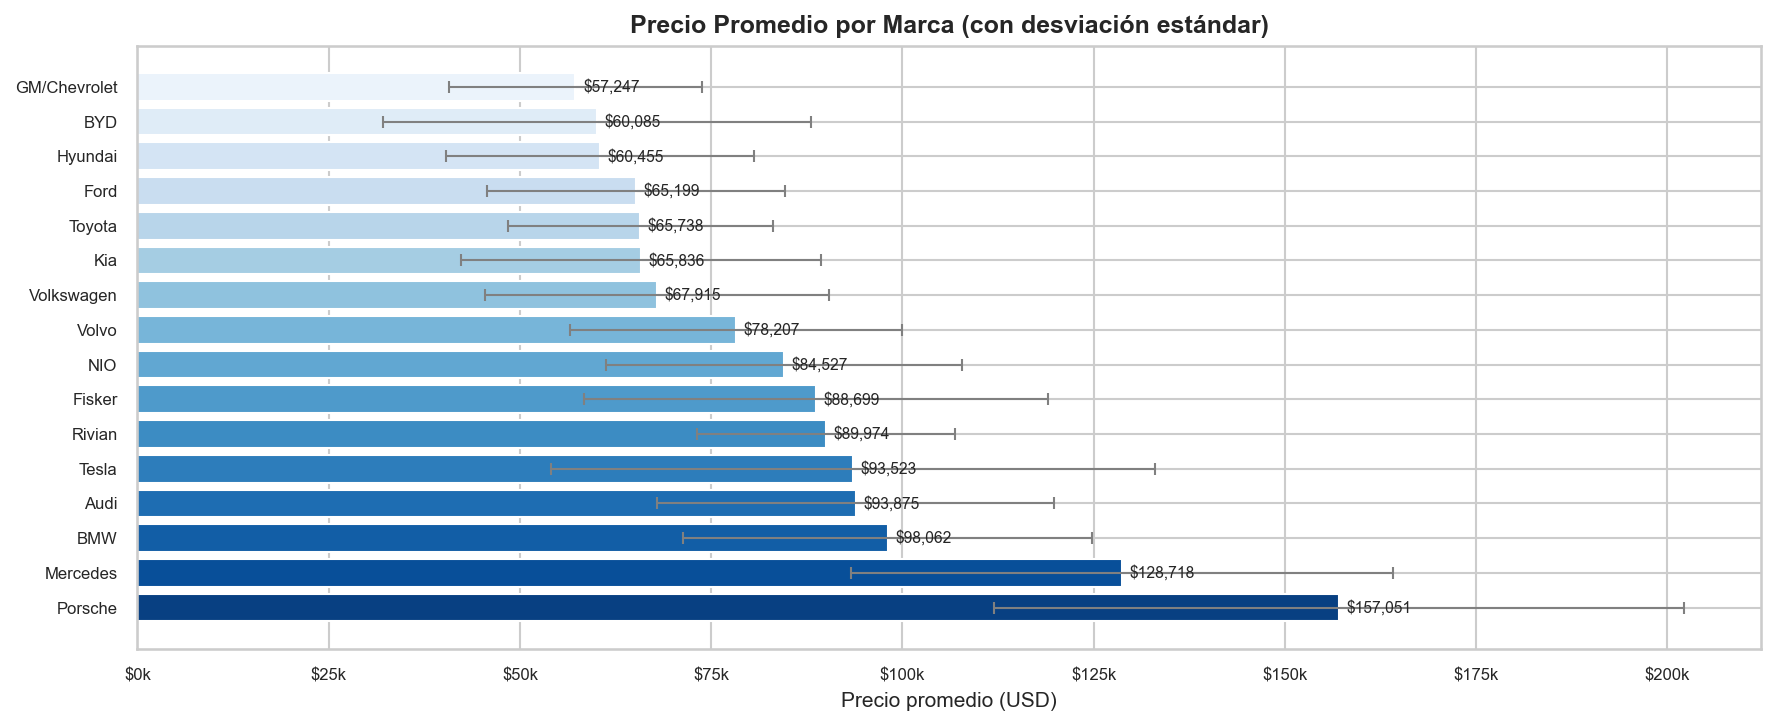

,Media,Mediana,Std,Mín,Máx
brand,,,,,
Porsche,157051.0,144345.0,45073.0,101898.0,254017.0
Mercedes,128718.0,124978.0,35428.0,59152.0,210812.0
BMW,98062.0,93953.0,26693.0,47597.0,162823.0
Audi,93875.0,91070.0,25950.0,48523.0,163471.0
Tesla,93523.0,93637.0,39451.0,24980.0,188965.0
Rivian,89974.0,86120.0,16887.0,60979.0,118076.0
Fisker,88699.0,85586.0,30340.0,47757.0,159067.0
NIO,84527.0,78059.0,23266.0,53544.0,144157.0
Volvo,78207.0,77428.0,21685.0,45993.0,111533.0


In [12]:
precio_marca = (
    df_main.groupby('brand')['price_usd']
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .round(0)
    .sort_values('mean', ascending=False)
)
precio_marca.columns = ['Media', 'Mediana', 'Std', 'Mín', 'Máx']

fig, ax = plt.subplots(figsize=(12, 5))
colores = sns.color_palette('Blues_r', len(precio_marca))
bars = ax.barh(precio_marca.index, precio_marca['Media'], color=colores, edgecolor='white')

# Líneas de error (std)
ax.errorbar(
    precio_marca['Media'], precio_marca.index,
    xerr=precio_marca['Std'], fmt='none', color='gray', capsize=3, linewidth=1
)

# Etiquetas de valor
for bar, val in zip(bars, precio_marca['Media']):
    ax.text(val + 1000, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=7.5)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_title('Precio Promedio por Marca (con desviación estándar)', fontweight='bold')
ax.set_xlabel('Precio promedio (USD)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('3_1_precio_por_marca.png', bbox_inches='tight')
plt.show()

display(precio_marca)

### 5.1.2) Autonomia promedio por marca

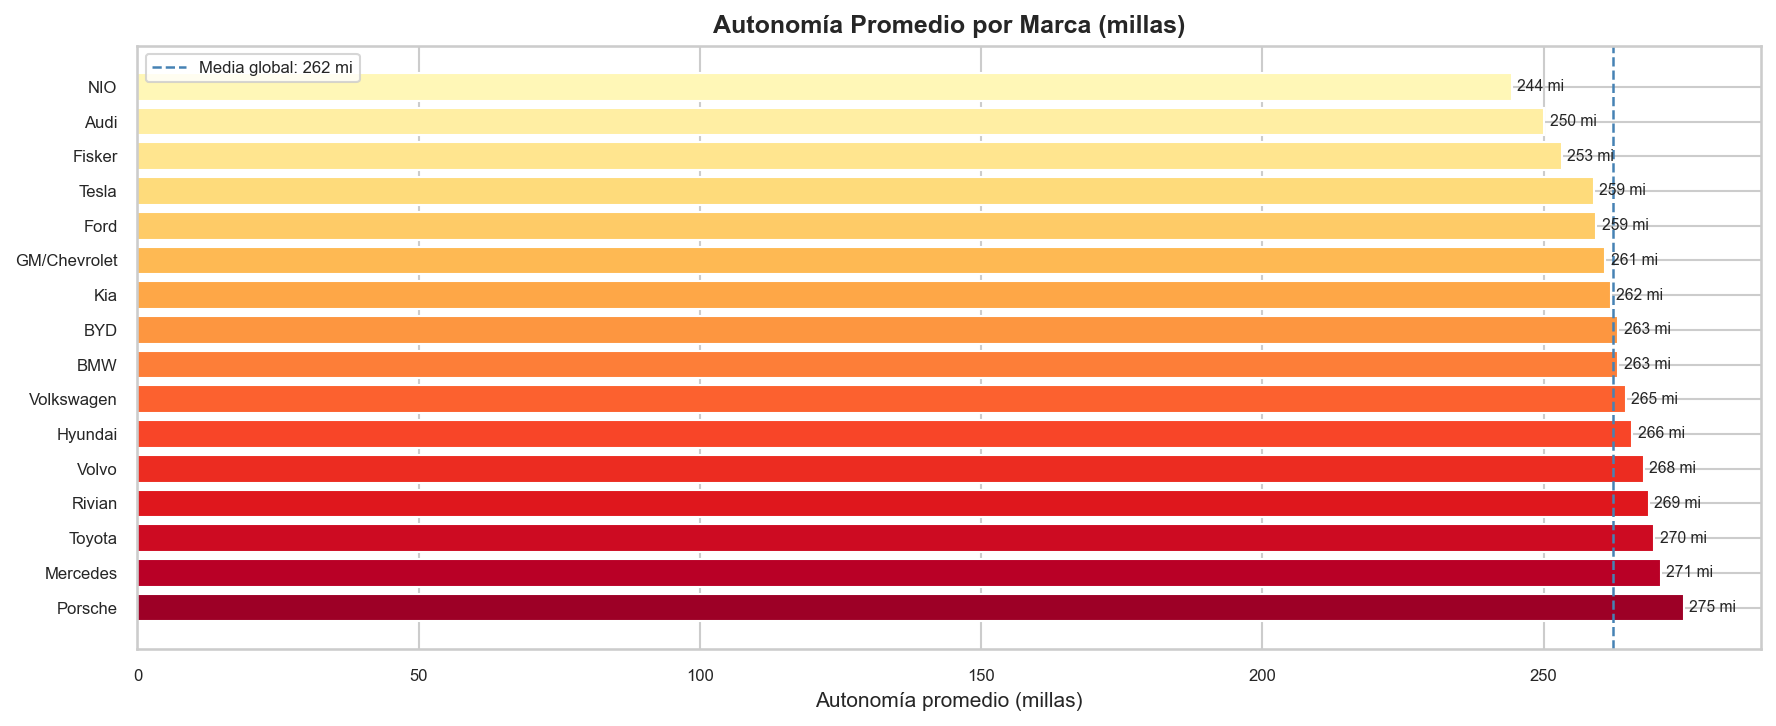

In [13]:
autonomia_marca = (
    df_main.groupby('brand')['range_miles']
    .mean()
    .round(1)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
colores = sns.color_palette('YlOrRd_r', len(autonomia_marca))
bars = ax.barh(autonomia_marca.index, autonomia_marca.values, color=colores, edgecolor='white')

for bar, val in zip(bars, autonomia_marca.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f} mi', va='center', fontsize=7.5)

ax.axvline(autonomia_marca.mean(), color='steelblue', linestyle='--', linewidth=1.2,
           label=f'Media global: {autonomia_marca.mean():.0f} mi')
ax.legend(fontsize=8)
ax.set_title('Autonomía Promedio por Marca (millas)', fontweight='bold')
ax.set_xlabel('Autonomía promedio (millas)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('3_2_autonomia_por_marca.png', bbox_inches='tight')
plt.show()

### 5.1.3) Velocidad de carga promedio por marca

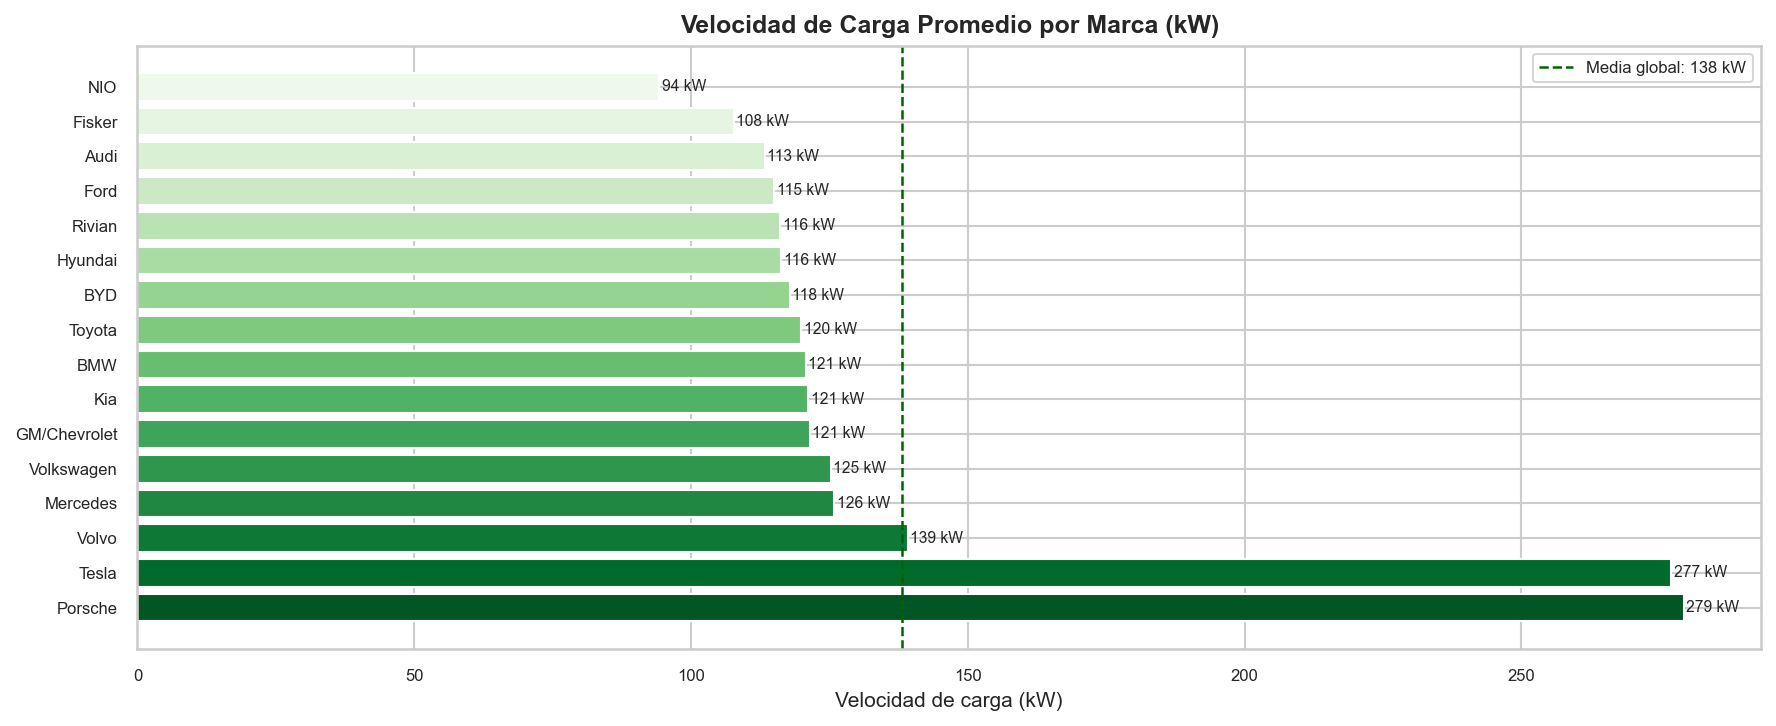

In [14]:
carga_marca = (
    df_main.groupby('brand')['charging_speed_kw']
    .mean()
    .round(1)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
colores = sns.color_palette('Greens_r', len(carga_marca))
bars = ax.barh(carga_marca.index, carga_marca.values, color=colores, edgecolor='white')

for bar, val in zip(bars, carga_marca.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f} kW', va='center', fontsize=7.5)

ax.axvline(carga_marca.mean(), color='darkgreen', linestyle='--', linewidth=1.2,
           label=f'Media global: {carga_marca.mean():.0f} kW')
ax.legend(fontsize=8)
ax.set_title('Velocidad de Carga Promedio por Marca (kW)', fontweight='bold')
ax.set_xlabel('Velocidad de carga (kW)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('3_3_carga_por_marca.png', bbox_inches='tight')
plt.show()

### 5.1.4) Valoración del cliente por marca

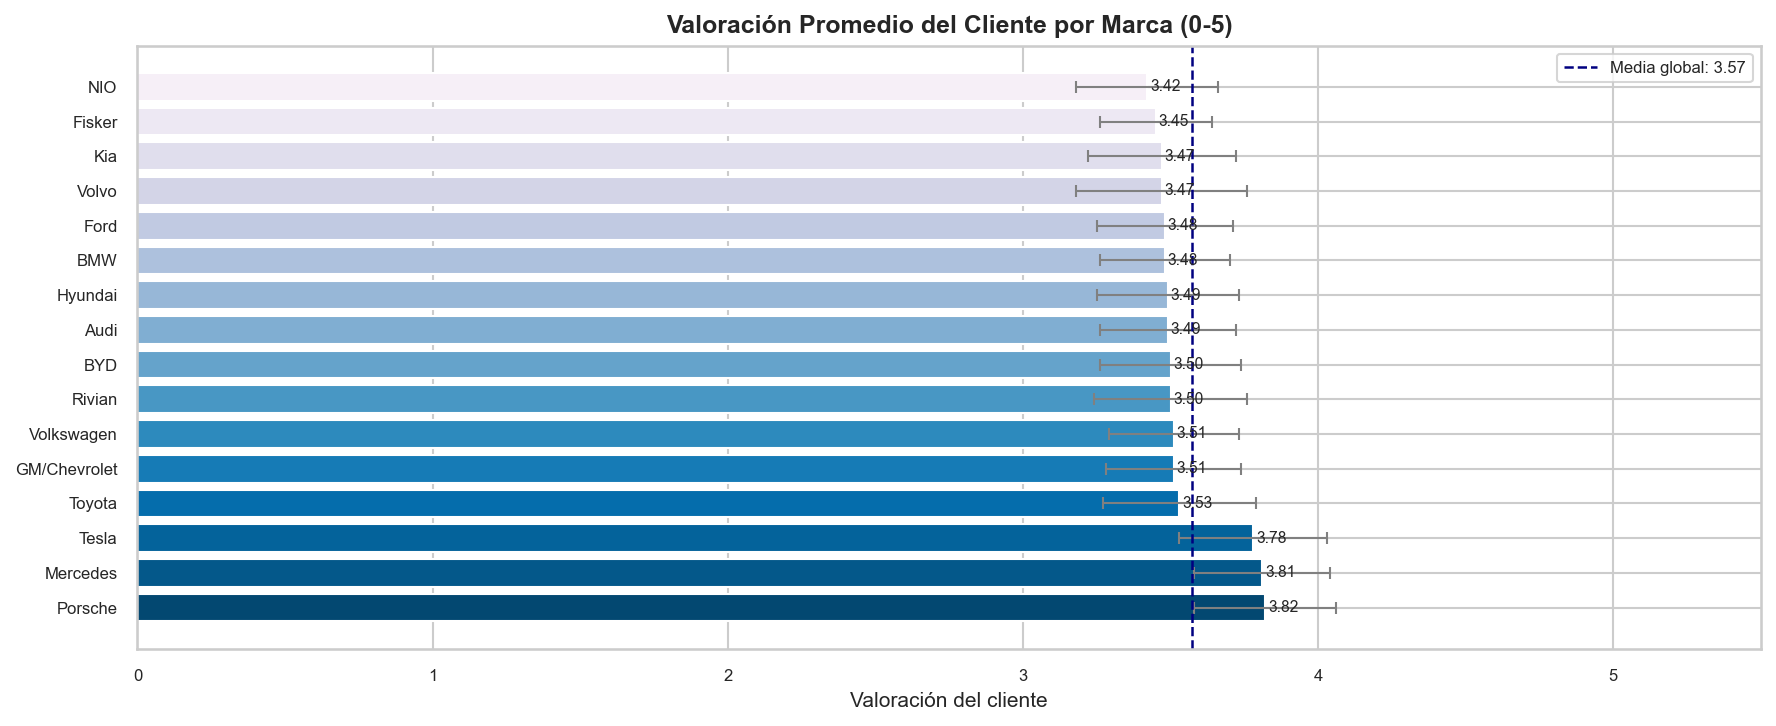

,Media,Std,N
brand,,,
Porsche,3.82,0.24,14
Mercedes,3.81,0.23,96
Tesla,3.78,0.25,434
Toyota,3.53,0.26,41
GM/Chevrolet,3.51,0.23,143
Volkswagen,3.51,0.22,194
Rivian,3.50,0.26,37
BYD,3.50,0.24,282
Audi,3.49,0.23,77


In [15]:
rating_marca = (
    df_main.groupby('brand')['customer_rating']
    .agg(['mean', 'std', 'count'])
    .round(2)
    .sort_values('mean', ascending=False)
)
rating_marca.columns = ['Media', 'Std', 'N']

fig, ax = plt.subplots(figsize=(12, 5))
colores = sns.color_palette('PuBu_r', len(rating_marca))
bars = ax.barh(rating_marca.index, rating_marca['Media'], color=colores, edgecolor='white')

ax.errorbar(
    rating_marca['Media'], rating_marca.index,
    xerr=rating_marca['Std'], fmt='none', color='gray', capsize=3, linewidth=1
)

for bar, val in zip(bars, rating_marca['Media']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=7.5)

ax.axvline(df_main['customer_rating'].mean(), color='navy', linestyle='--', linewidth=1.2,
           label=f'Media global: {df_main["customer_rating"].mean():.2f}')
ax.set_xlim(0, 5.5)
ax.legend(fontsize=8)
ax.set_title('Valoración Promedio del Cliente por Marca (0-5)', fontweight='bold')
ax.set_xlabel('Valoración del cliente')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('3_4_rating_por_marca.png', bbox_inches='tight')
plt.show()

display(rating_marca)

### 5.1.5) Distribución por segmento de mercado por marca

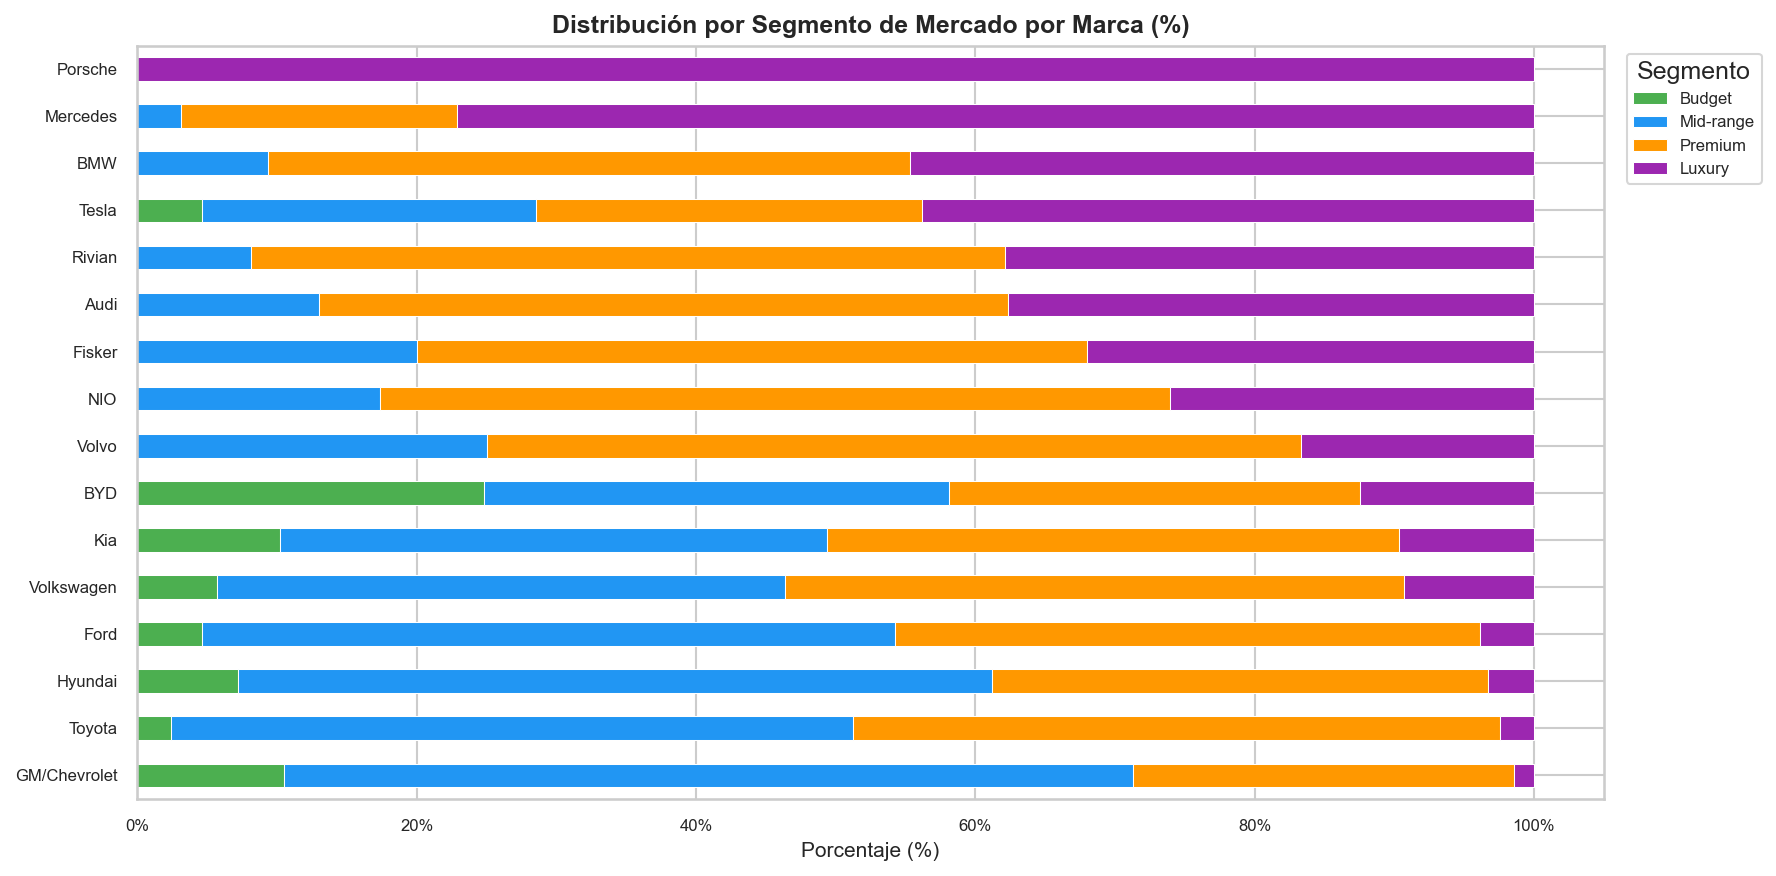

In [16]:
segmento_marca = (
    df_main.groupby(['brand', 'market_segment'])
    .size()
    .unstack(fill_value=0)
)
# Normalizar a porcentaje
segmento_pct = segmento_marca.div(segmento_marca.sum(axis=1), axis=0) * 100
# Ordenar por presencia en Luxury
orden = segmento_pct.get('Luxury', pd.Series(0, index=segmento_pct.index)).sort_values(ascending=True).index
segmento_pct = segmento_pct.loc[orden]

colores_seg = {'Budget': '#4CAF50', 'Mid-range': '#2196F3', 'Premium': '#FF9800', 'Luxury': '#9C27B0'}
cols_presentes = [c for c in ['Budget', 'Mid-range', 'Premium', 'Luxury'] if c in segmento_pct.columns]

fig, ax = plt.subplots(figsize=(12, 6))
segmento_pct[cols_presentes].plot(
    kind='barh', stacked=True, ax=ax,
    color=[colores_seg[c] for c in cols_presentes], edgecolor='white', linewidth=0.5
)
ax.set_title('Distribución por Segmento de Mercado por Marca (%)', fontweight='bold')
ax.set_xlabel('Porcentaje (%)')
ax.set_ylabel('')
ax.legend(title='Segmento', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig('3_5_segmento_por_marca.png', bbox_inches='tight')
plt.show()

### 3.1.6) Tendencias anuales de precio por marca (Top 6)

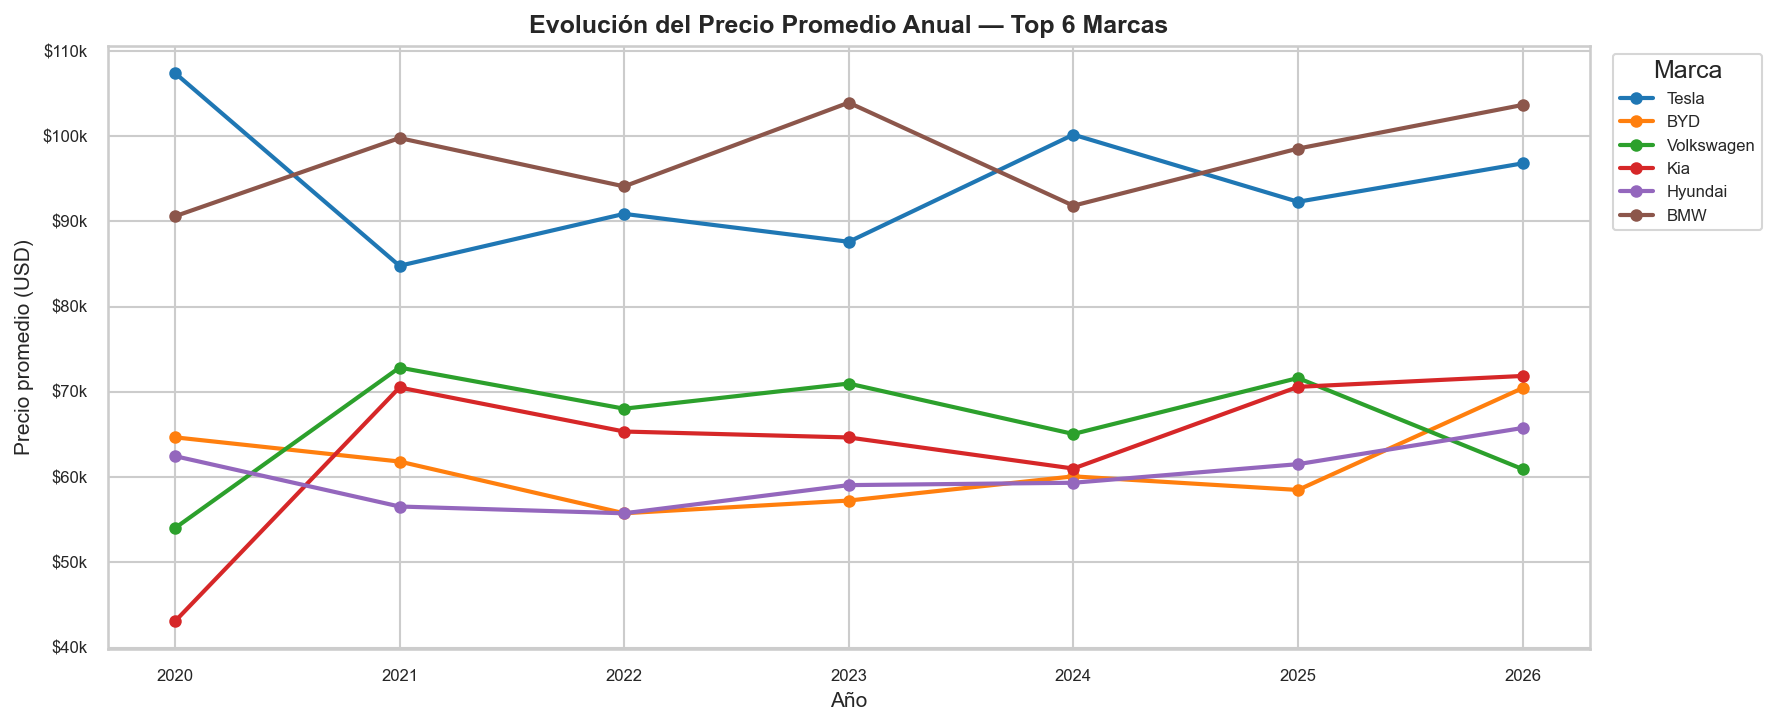

In [17]:
# Top 6 marcas por volumen de ventas
top6 = df_main.groupby('brand')['annual_sales_units'].sum().nlargest(6).index

precio_anual = (
    df_main[df_main['brand'].isin(top6)]
    .groupby(['brand', 'year'])['price_usd']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
paleta = sns.color_palette('tab10', len(top6))

for i, marca in enumerate(top6):
    datos = precio_anual[precio_anual['brand'] == marca].sort_values('year')
    ax.plot(datos['year'], datos['price_usd'], marker='o', label=marca,
            color=paleta[i], linewidth=2, markersize=5)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_title('Evolución del Precio Promedio Anual — Top 6 Marcas', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Precio promedio (USD)')
ax.legend(title='Marca', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('3_6_precio_anual_top6.png', bbox_inches='tight')
plt.show()

### 3.1.7) Safety rating por marca

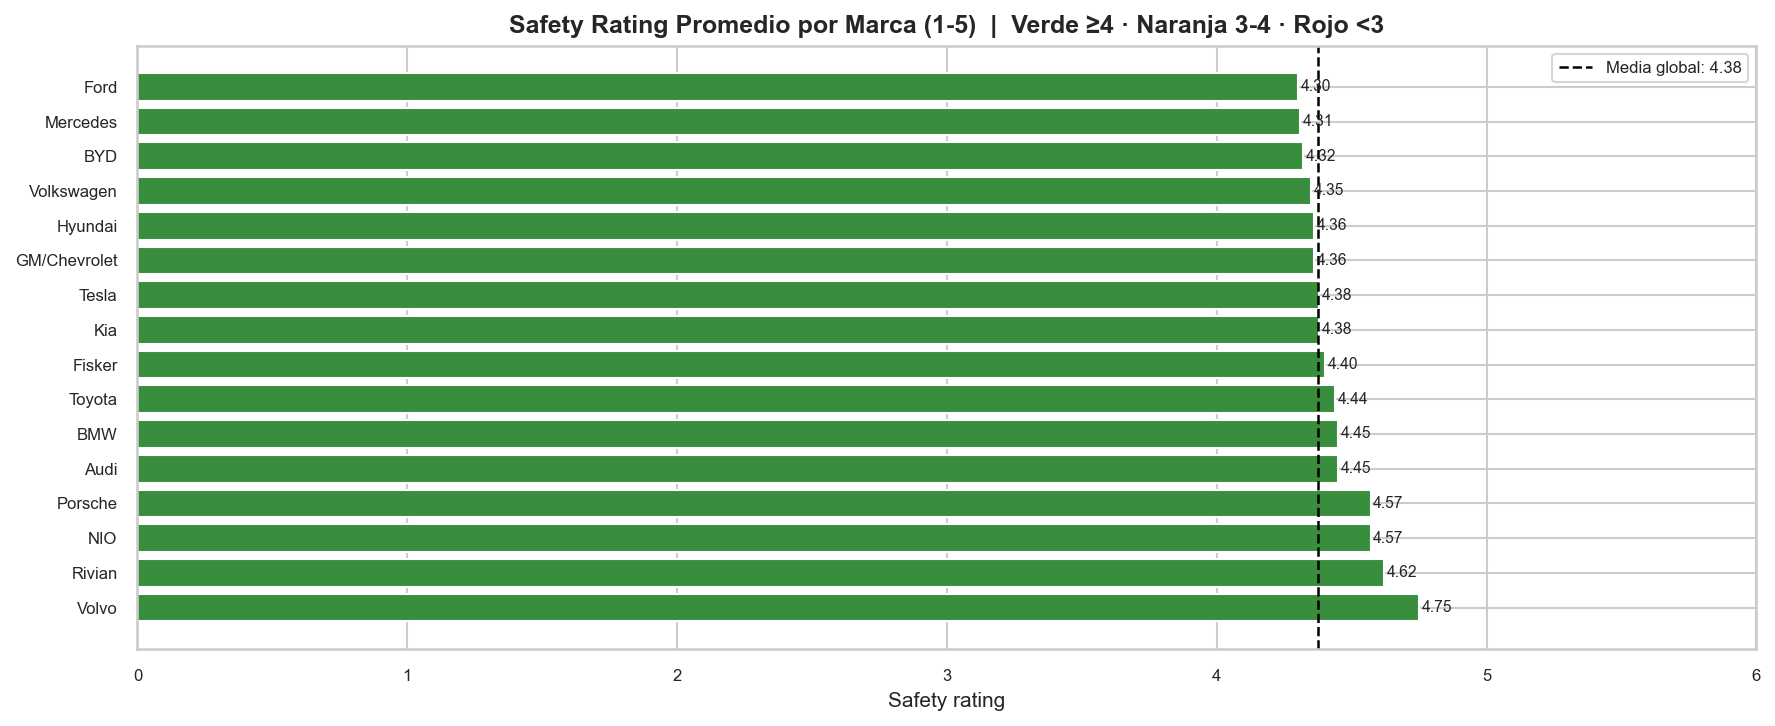

,Safety Rating Promedio
brand,
Volvo,4.75
Rivian,4.62
NIO,4.57
Porsche,4.57
Audi,4.45
BMW,4.45
Toyota,4.44
Fisker,4.40
Kia,4.38


In [18]:
safety_marca = (
    df_main.groupby('brand')['safety_rating']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
colores = ['#d32f2f' if v < 3 else '#f57c00' if v < 4 else '#388e3c' for v in safety_marca.values]
bars = ax.barh(safety_marca.index, safety_marca.values, color=colores, edgecolor='white')

for bar, val in zip(bars, safety_marca.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=7.5)

ax.axvline(df_main['safety_rating'].mean(), color='black', linestyle='--', linewidth=1.2,
           label=f'Media global: {df_main["safety_rating"].mean():.2f}')
ax.set_xlim(0, 6)
ax.legend(fontsize=8)
ax.set_title('Safety Rating Promedio por Marca (1-5)  |  Verde ≥4 · Naranja 3-4 · Rojo <3',
             fontweight='bold')
ax.set_xlabel('Safety rating')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('3_7_safety_por_marca.png', bbox_inches='tight')
plt.show()

display(safety_marca.to_frame('Safety Rating Promedio'))

### 5.1.8) Ranking global de marcas

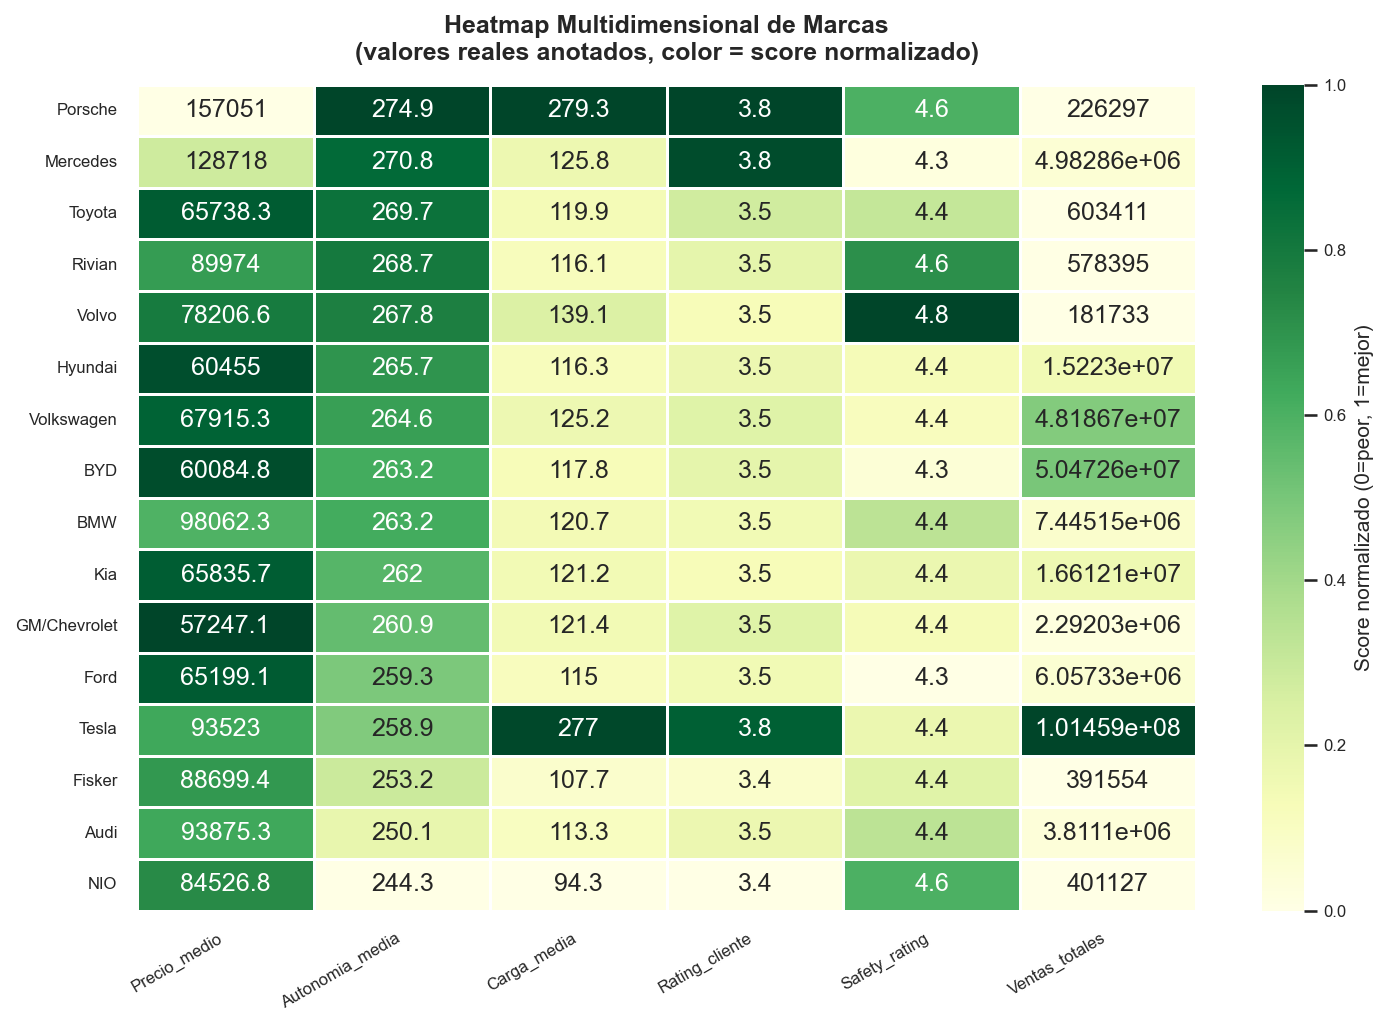

,Precio_medio,Autonomia_media,Carga_media,Rating_cliente,Safety_rating,Ventas_totales
brand,,,,,,
Audi,93875.34,250.08,113.29,3.49,4.45,3811099
BMW,98062.34,263.21,120.68,3.48,4.45,7445149
BYD,60084.84,263.24,117.81,3.50,4.32,50472617
Fisker,88699.36,253.20,107.74,3.45,4.40,391554
Ford,65199.07,259.30,114.96,3.48,4.30,6057329
GM/Chevrolet,57247.11,260.92,121.42,3.51,4.36,2292030
Hyundai,60454.97,265.66,116.32,3.49,4.36,15223045
Kia,65835.66,261.95,121.22,3.47,4.38,16612129
Mercedes,128717.87,270.79,125.85,3.81,4.31,4982856


In [19]:
# Tabla resumen normalizada (0-1) para comparar marcas en todas las dimensiones
resumen = df_main.groupby('brand').agg(
    Precio_medio       = ('price_usd',          'mean'),
    Autonomia_media    = ('range_miles',         'mean'),
    Carga_media        = ('charging_speed_kw',   'mean'),
    Rating_cliente     = ('customer_rating',     'mean'),
    Safety_rating      = ('safety_rating',       'mean'),
    Ventas_totales     = ('annual_sales_units',  'sum'),
).round(2)

# Normalizar 0-1 para el heatmap
resumen_norm = (resumen - resumen.min()) / (resumen.max() - resumen.min())
# Para precio, invertir (menor precio = mejor puntuación relativa)
resumen_norm['Precio_medio'] = 1 - resumen_norm['Precio_medio']

resumen_norm = resumen_norm.sort_values('Autonomia_media', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    resumen_norm,
    annot=resumen.loc[resumen_norm.index].round(1),
    fmt='g',
    cmap='YlGn',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Score normalizado (0=peor, 1=mejor)'}
)
ax.set_title('Heatmap Multidimensional de Marcas\n(valores reales anotados, color = score normalizado)',
             fontweight='bold', pad=12)
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('3_8_heatmap_marcas.png', bbox_inches='tight')
plt.show()

display(resumen)

Tesla → ~101 millones de unidades -- BYD → ~50 millones de unidades
- BYD ofrece una autonomía prácticamente idéntica a Tesla a $33k menos de precio promedio, con un safety rating superior (4.32 vs 4.38) y un volumen de ventas de ~50M de unidades. Sin embargo, Tesla domina en velocidad de carga (277 vs 118 kW), valoración del cliente (3.78 vs 3.50) y lidera en ventas totales con ~101M de unidades. BYD es la compra inteligente para el comprador orientado al precio; Tesla justifica su premium principalmente por la infraestructura de carga y la experiencia de usuario.

## Cuota de mercado y tendencias de ventas 2020-2026

### 5.2.1) Imports y preparacion

In [20]:
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.facecolor': 'white',
})

df = pd.read_csv(r"C:\Users\andy_\Documents\Datasets\ev_market_2026.csv")
marcas_principales = df['brand'].value_counts()[df['brand'].value_counts() >= 10].index
df_main = df[df['brand'].isin(marcas_principales)].copy()

### 5.2.2) Ventas totales por marca (ranking)

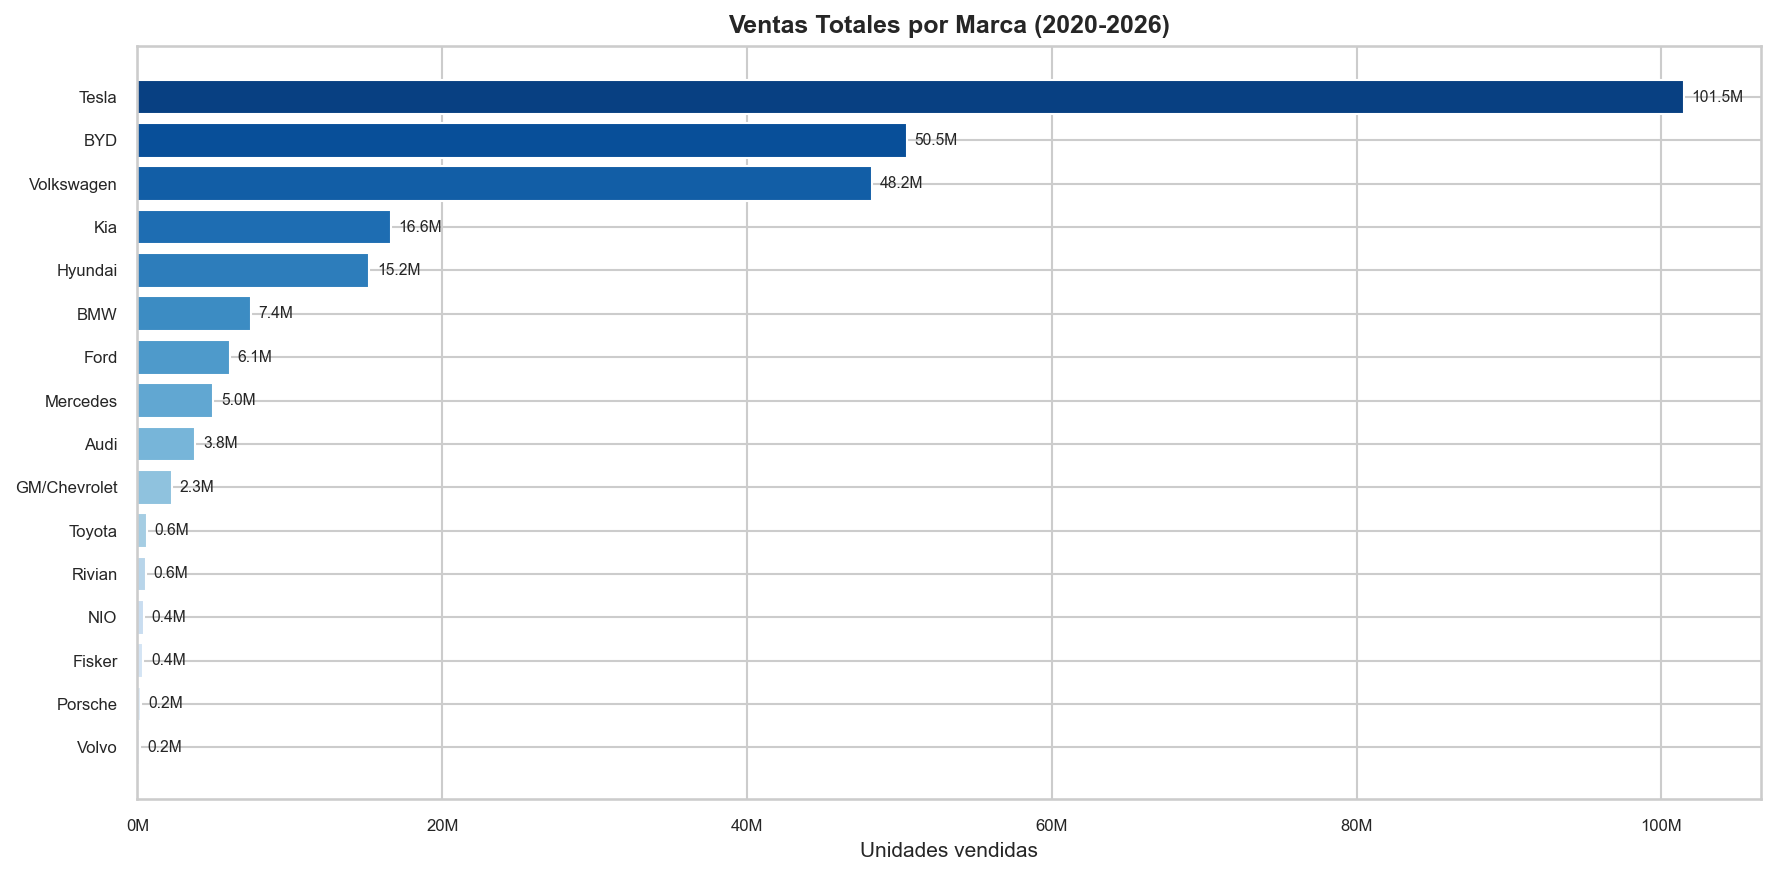

In [21]:
ventas_marca = (
    df_main.groupby('brand')['annual_sales_units']
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 6))
colores = sns.color_palette('Blues', len(ventas_marca))
bars = ax.barh(ventas_marca.index, ventas_marca.values, color=colores, edgecolor='white')

for bar, val in zip(bars, ventas_marca.values):
    ax.text(val + 500_000, bar.get_y() + bar.get_height()/2,
            f'{val/1e6:.1f}M', va='center', fontsize=7.5)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.set_title('Ventas Totales por Marca (2020-2026)', fontweight='bold')
ax.set_xlabel('Unidades vendidas')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('4_1_ventas_por_marca.png', bbox_inches='tight')
plt.show()

### 5.2.3) Ventas anuales por marca (top 6, evolución)

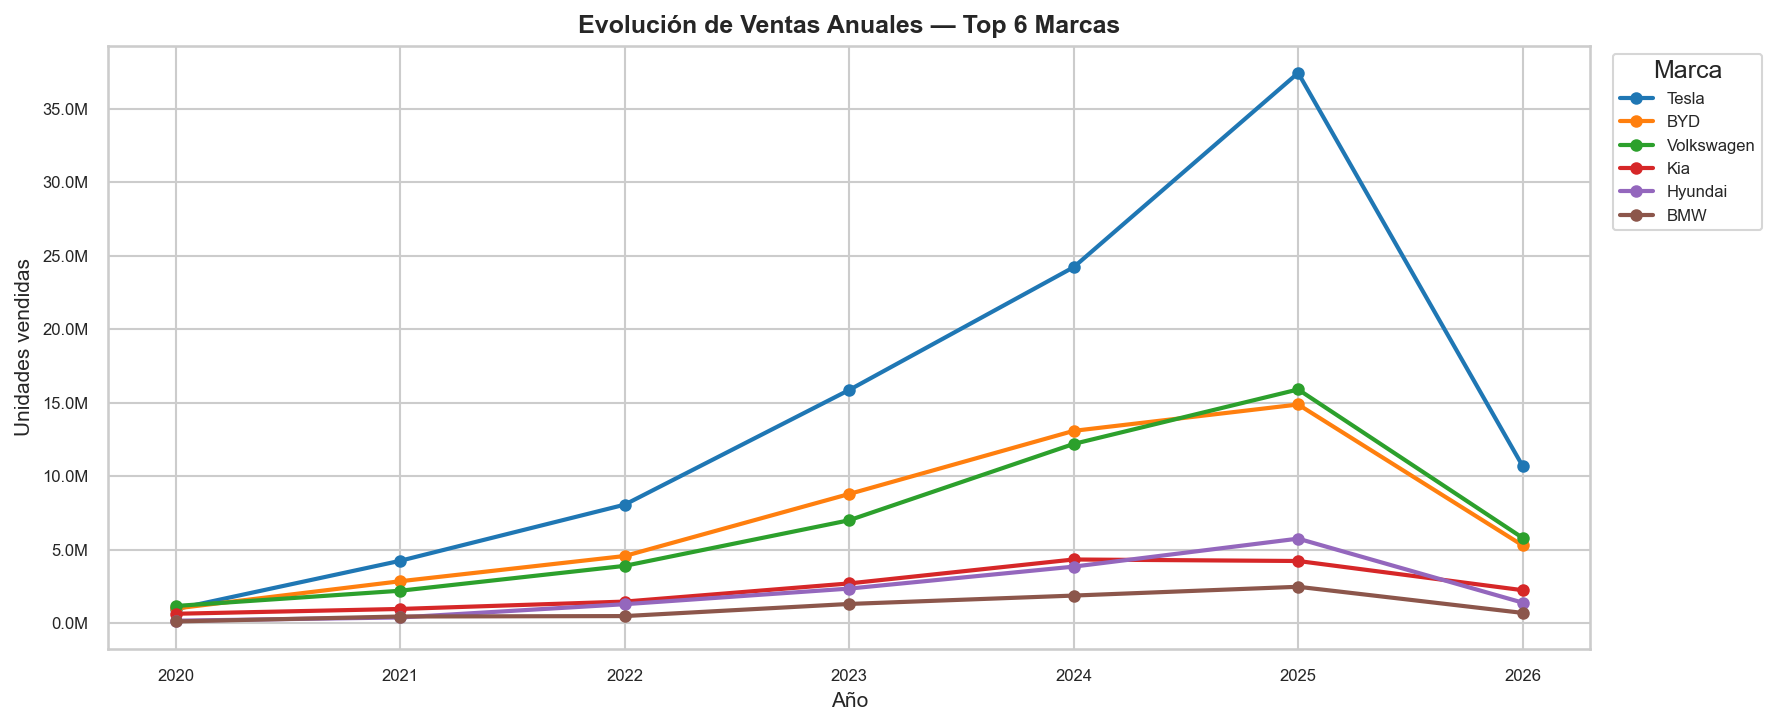

In [22]:
top6 = df_main.groupby('brand')['annual_sales_units'].sum().nlargest(6).index

ventas_anuales = (
    df_main[df_main['brand'].isin(top6)]
    .groupby(['brand', 'year'])['annual_sales_units']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
paleta = sns.color_palette('tab10', len(top6))

for i, marca in enumerate(top6):
    datos = ventas_anuales[ventas_anuales['brand'] == marca].sort_values('year')
    ax.plot(datos['year'], datos['annual_sales_units'], marker='o',
            label=marca, color=paleta[i], linewidth=2, markersize=5)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_title('Evolución de Ventas Anuales — Top 6 Marcas', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Unidades vendidas')
ax.legend(title='Marca', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('4_2_ventas_anuales_top6.png', bbox_inches='tight')
plt.show()

### 5.2.4) Crecimiento por segmento de mercado

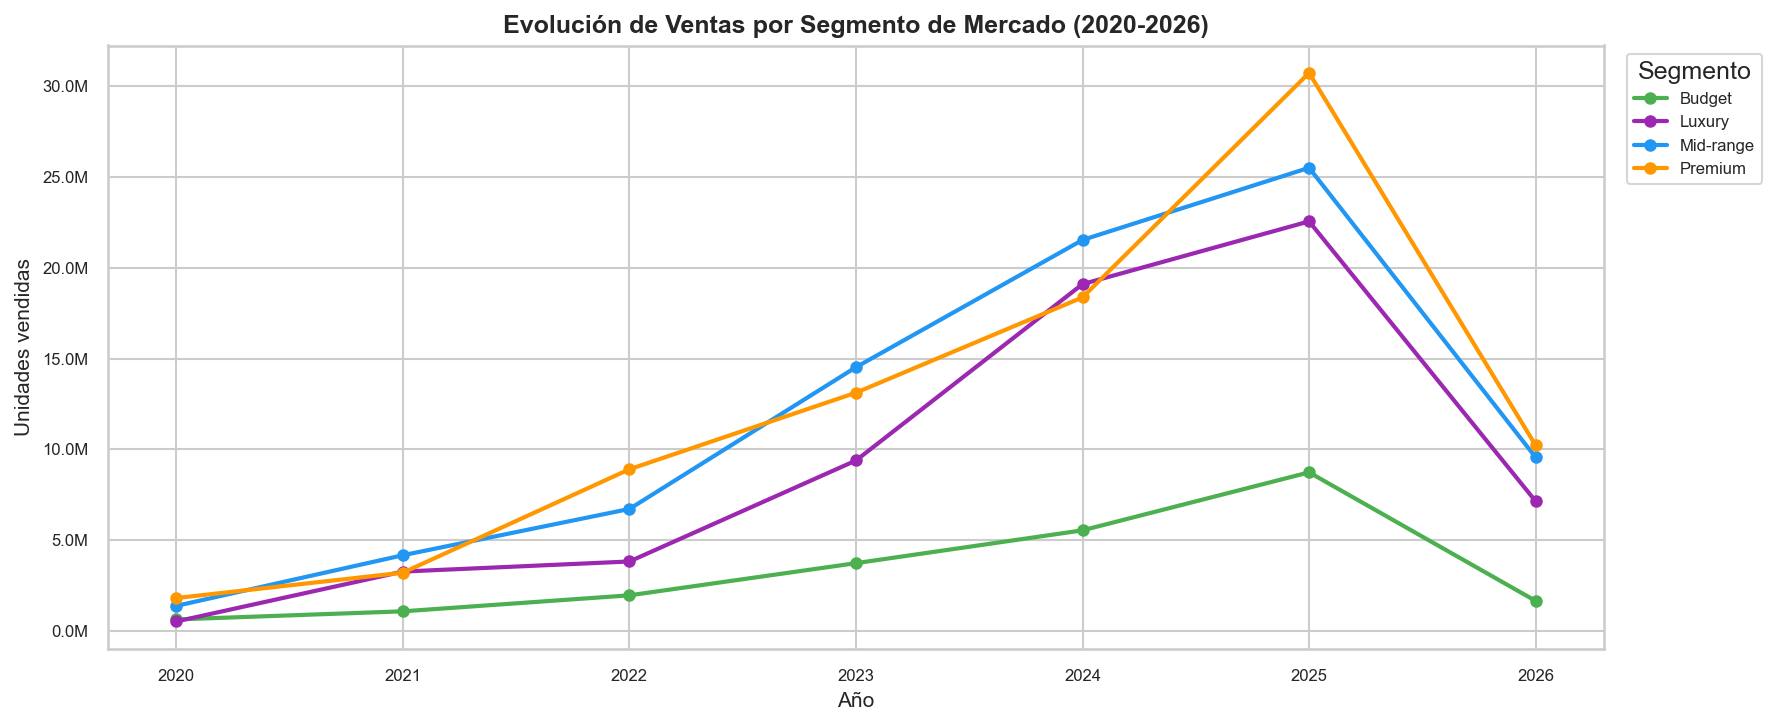

In [23]:
ventas_segmento = (
    df_main.groupby(['year', 'market_segment'])['annual_sales_units']
    .sum()
    .reset_index()
)

colores_seg = {
    'Budget': '#4CAF50',
    'Mid-range': '#2196F3',
    'Premium': '#FF9800',
    'Luxury': '#9C27B0'
}

fig, ax = plt.subplots(figsize=(12, 5))
for seg, grupo in ventas_segmento.groupby('market_segment'):
    grupo = grupo.sort_values('year')
    ax.plot(grupo['year'], grupo['annual_sales_units'], marker='o',
            label=seg, color=colores_seg[seg], linewidth=2, markersize=5)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_title('Evolución de Ventas por Segmento de Mercado (2020-2026)', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Unidades vendidas')
ax.legend(title='Segmento', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('4_3_ventas_por_segmento.png', bbox_inches='tight')
plt.show()

### 5.2.5) Tendencias por body type

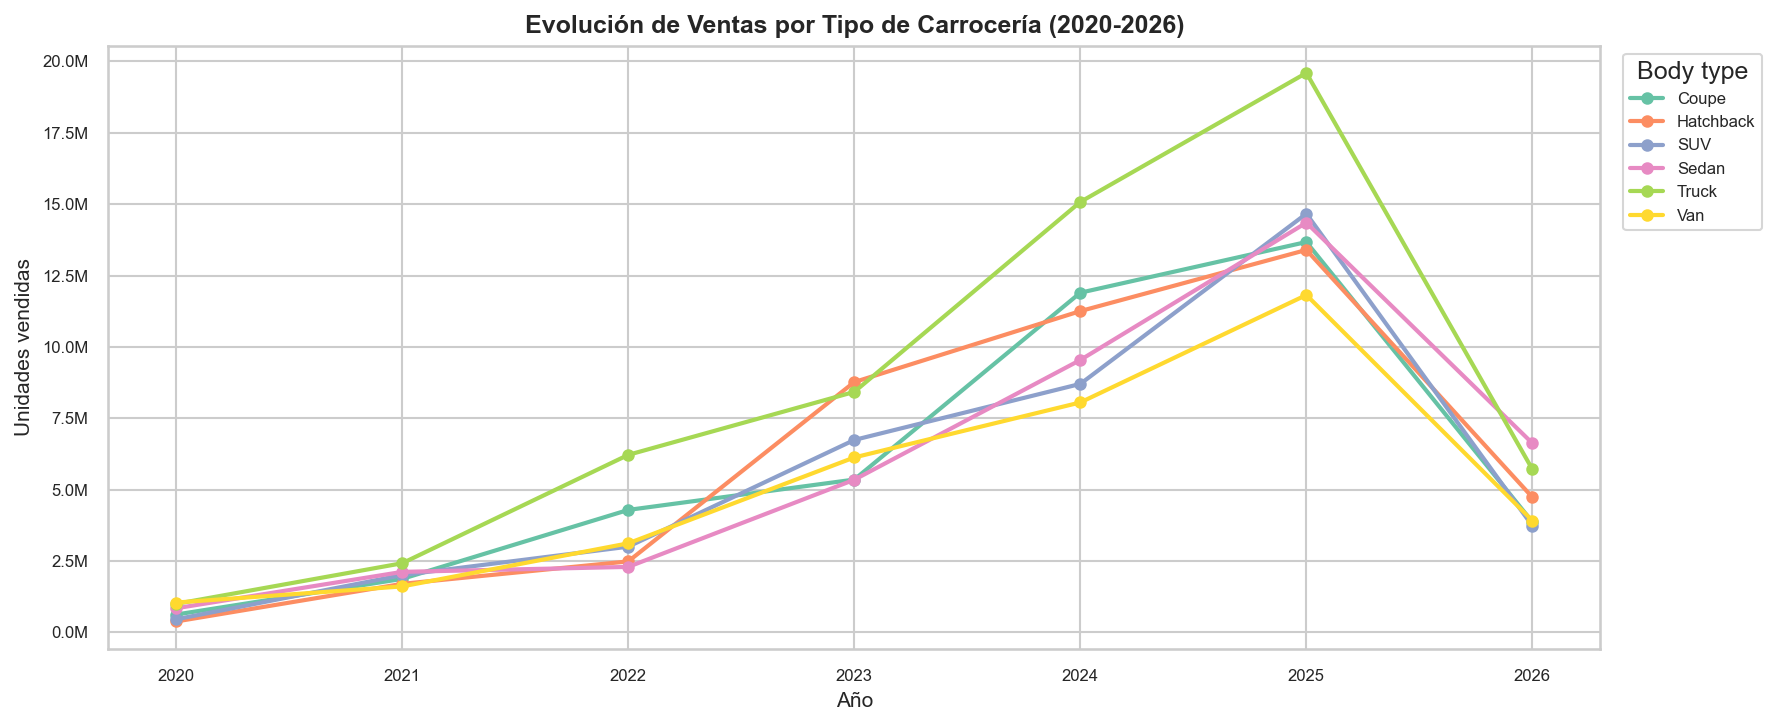

In [24]:
ventas_body = (
    df_main.groupby(['year', 'body_type'])['annual_sales_units']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
paleta_body = sns.color_palette('Set2', df_main['body_type'].nunique())

for i, (bt, grupo) in enumerate(ventas_body.groupby('body_type')):
    grupo = grupo.sort_values('year')
    ax.plot(grupo['year'], grupo['annual_sales_units'], marker='o',
            label=bt, color=paleta_body[i], linewidth=2, markersize=5)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_title('Evolución de Ventas por Tipo de Carrocería (2020-2026)', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Unidades vendidas')
ax.legend(title='Body type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('4_4_ventas_por_body_type.png', bbox_inches='tight')
plt.show()

### 5.2.6) Penetración por país de origen

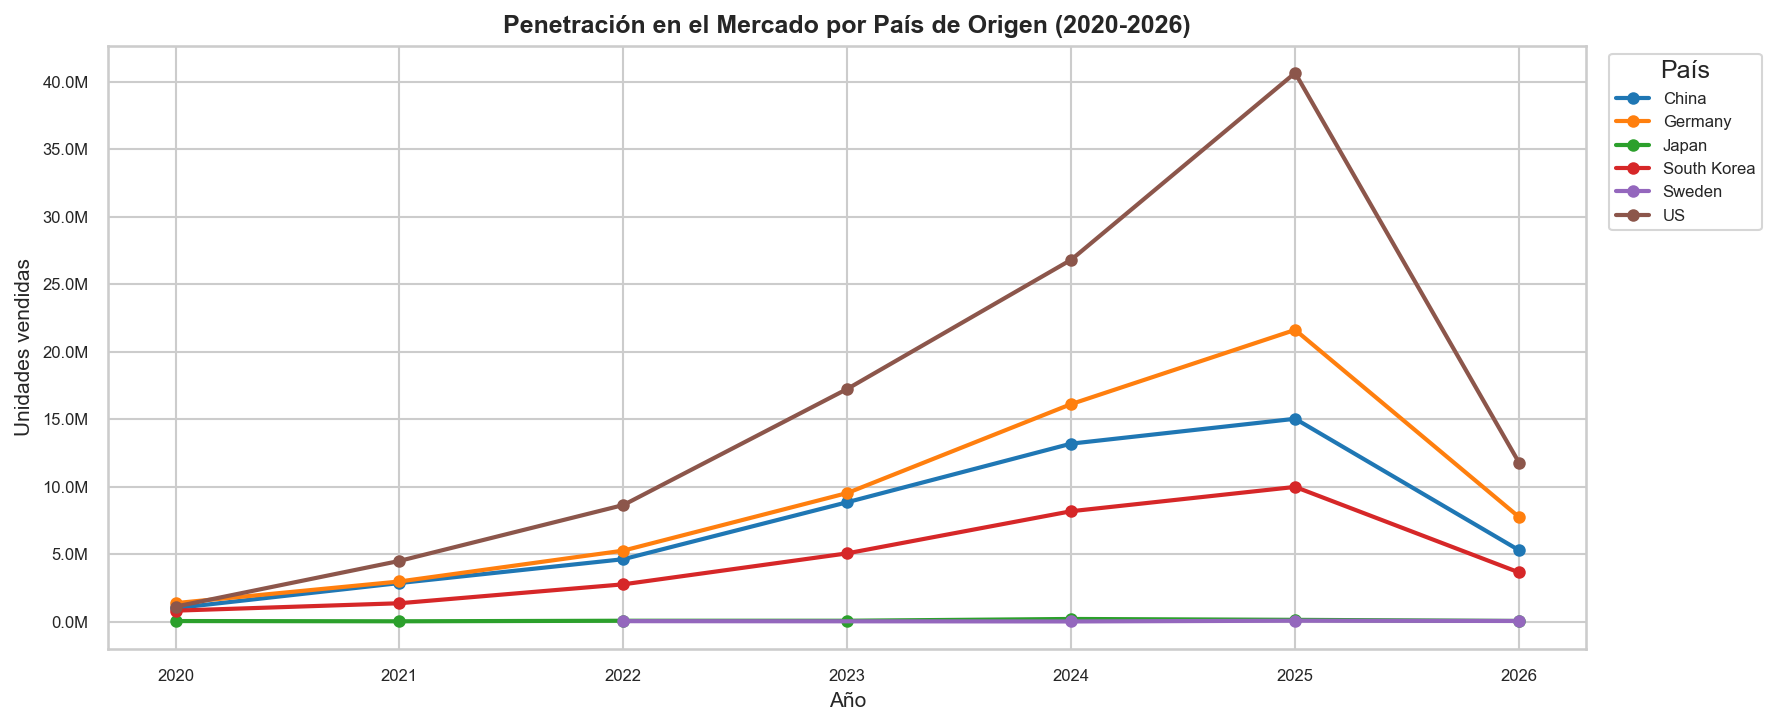

In [25]:
ventas_pais = (
    df_main.groupby(['year', 'country_of_origin'])['annual_sales_units']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
paleta_pais = sns.color_palette('tab10', df_main['country_of_origin'].nunique())

for i, (pais, grupo) in enumerate(ventas_pais.groupby('country_of_origin')):
    grupo = grupo.sort_values('year')
    ax.plot(grupo['year'], grupo['annual_sales_units'], marker='o',
            label=pais, color=paleta_pais[i], linewidth=2, markersize=5)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_title('Penetración en el Mercado por País de Origen (2020-2026)', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Unidades vendidas')
ax.legend(title='País', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('4_5_ventas_por_pais.png', bbox_inches='tight')
plt.show()

### 5.2.7) Cuota de mercado por país (stacked área)

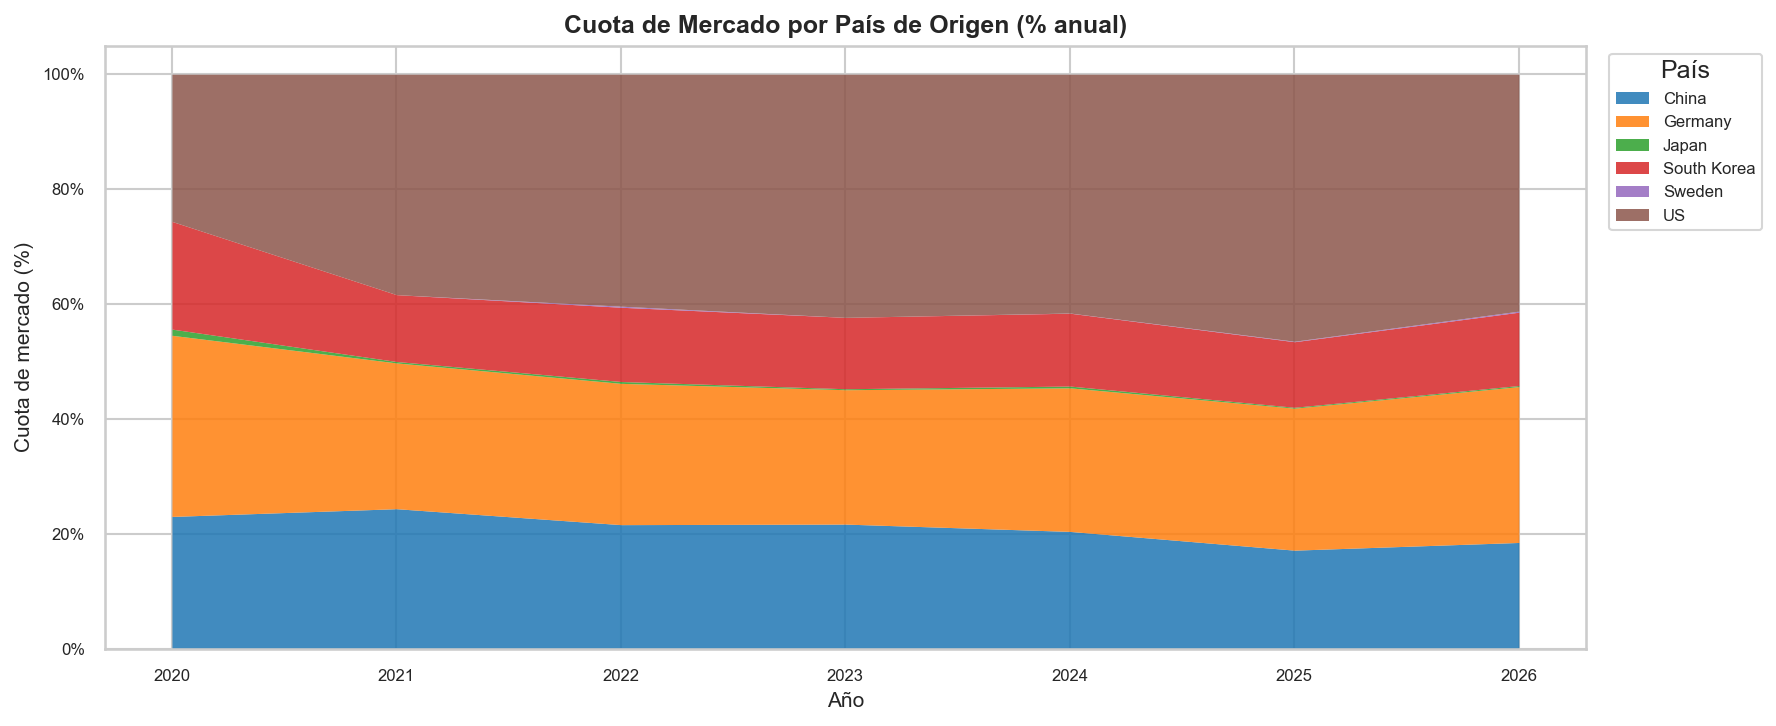

In [26]:
cuota_pais = (
    df_main.groupby(['year', 'country_of_origin'])['annual_sales_units']
    .sum()
    .unstack(fill_value=0)
)
cuota_pct = cuota_pais.div(cuota_pais.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
cuota_pct.plot(kind='area', stacked=True, ax=ax,
               color=sns.color_palette('tab10', cuota_pct.shape[1]),
               alpha=0.85, linewidth=0)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_title('Cuota de Mercado por País de Origen (% anual)', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Cuota de mercado (%)')
ax.legend(title='País', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('4_6_cuota_pais_area.png', bbox_inches='tight')
plt.show()

## Rango vs Precio

### 5.3.1) Imports y métrica de eficiencia

In [27]:
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.facecolor': 'white',
})

df = pd.read_csv(r"C:\Users\andy_\Documents\Datasets\ev_market_2026.csv")
marcas_principales = df['brand'].value_counts()[df['brand'].value_counts() >= 10].index
df_main = df[df['brand'].isin(marcas_principales)].copy()

# Métrica de eficiencia: millas por dólar (escalada x 1000 para legibilidad)
df_main['efficiency'] = (df_main['range_miles'] / df_main['price_usd']) * 1000

print("Estadísticas de la métrica efficiency (miles/$ x1000):")
print(df_main['efficiency'].describe().round(4))

Estadísticas de la métrica efficiency (miles/$ x1000):
count    1975.0000
mean        4.0211
std         2.1328
min         0.8244
25%         2.4596
50%         3.4915
75%         4.9905
max        15.7504
Name: efficiency, dtype: float64


### 5.3.2) Scatter precio vs autonomia

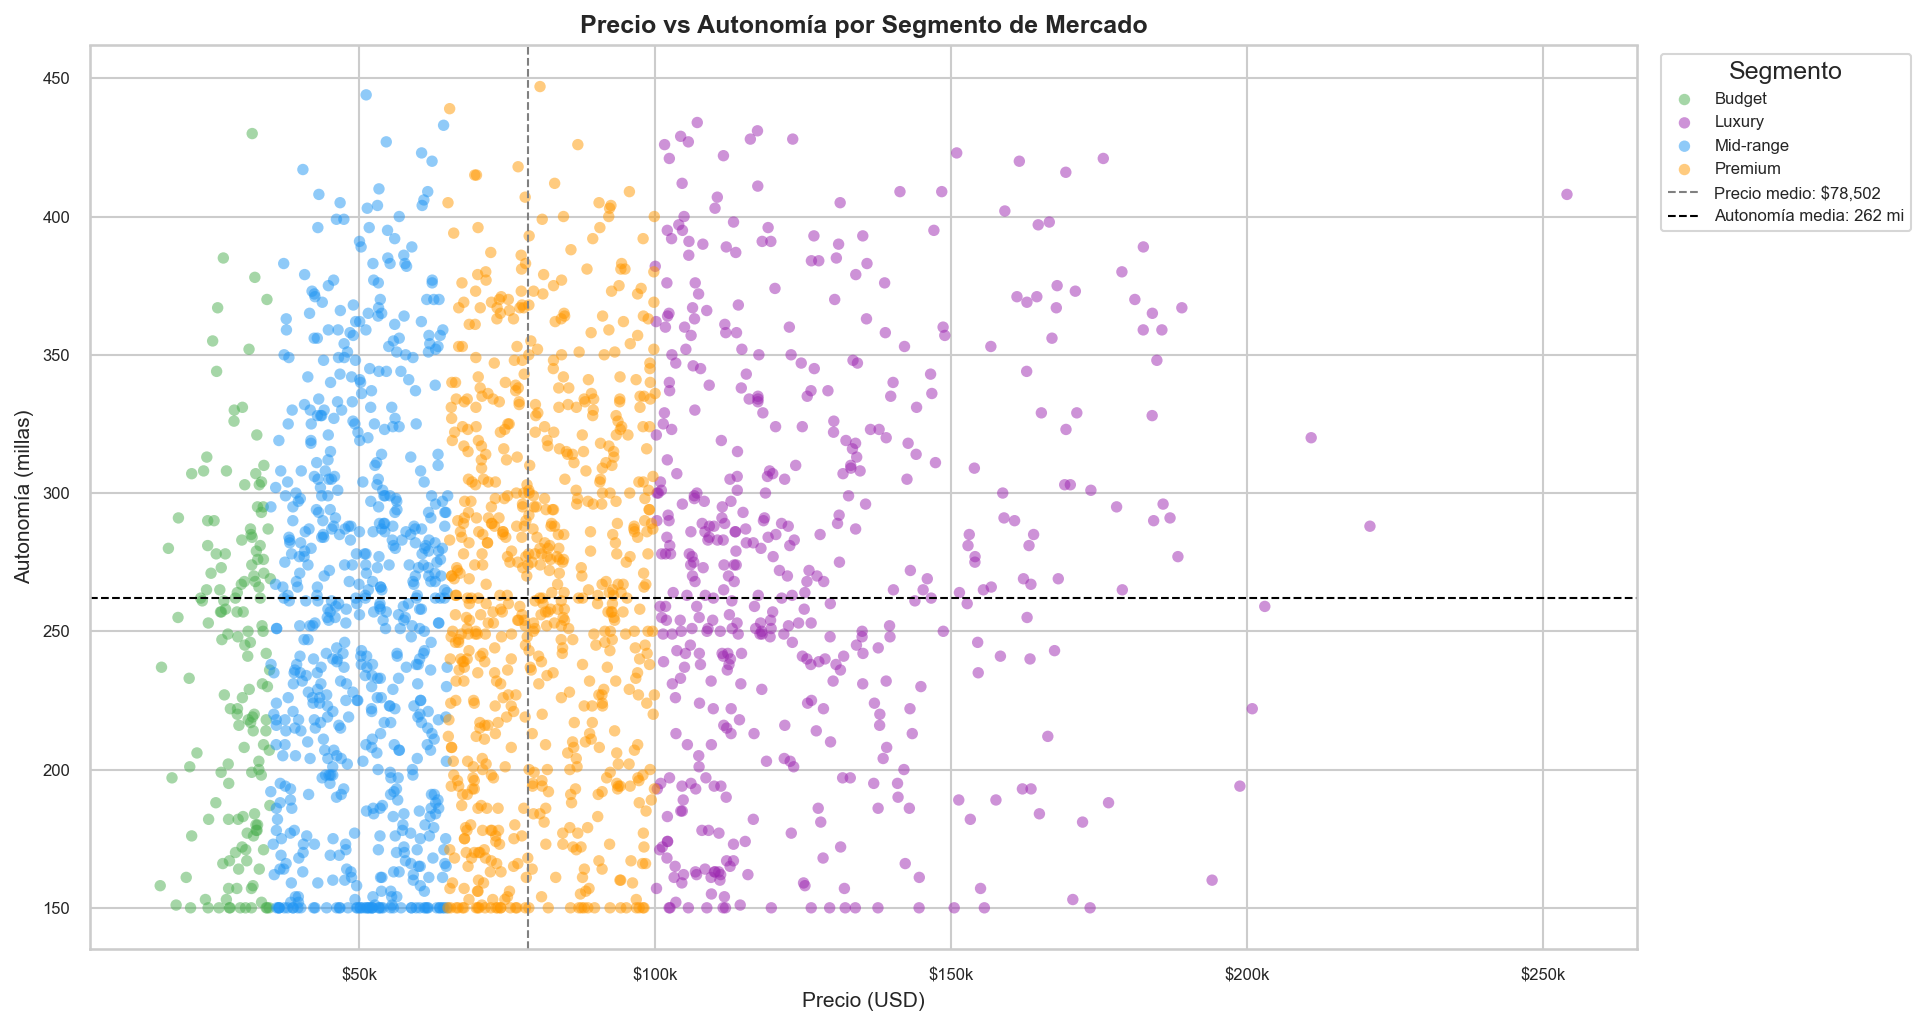

In [28]:
colores_seg = {
    'Budget': '#4CAF50',
    'Mid-range': '#2196F3',
    'Premium': '#FF9800',
    'Luxury': '#9C27B0'
}

fig, ax = plt.subplots(figsize=(13, 7))

for seg, grupo in df_main.groupby('market_segment'):
    ax.scatter(
        grupo['price_usd'], grupo['range_miles'],
        label=seg, color=colores_seg[seg],
        alpha=0.5, s=30, edgecolors='none'
    )

# Líneas de referencia: medias globales
ax.axvline(df_main['price_usd'].mean(), color='gray', linestyle='--', linewidth=1,
           label=f'Precio medio: ${df_main["price_usd"].mean():,.0f}')
ax.axhline(df_main['range_miles'].mean(), color='black', linestyle='--', linewidth=1,
           label=f'Autonomía media: {df_main["range_miles"].mean():.0f} mi')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_title('Precio vs Autonomía por Segmento de Mercado', fontweight='bold')
ax.set_xlabel('Precio (USD)')
ax.set_ylabel('Autonomía (millas)')
ax.legend(title='Segmento', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('2_1_scatter_precio_autonomia.png', bbox_inches='tight')
plt.show()

### 5.3.3) Top20 modelos más eficientes (mejor autonomía por dólar)

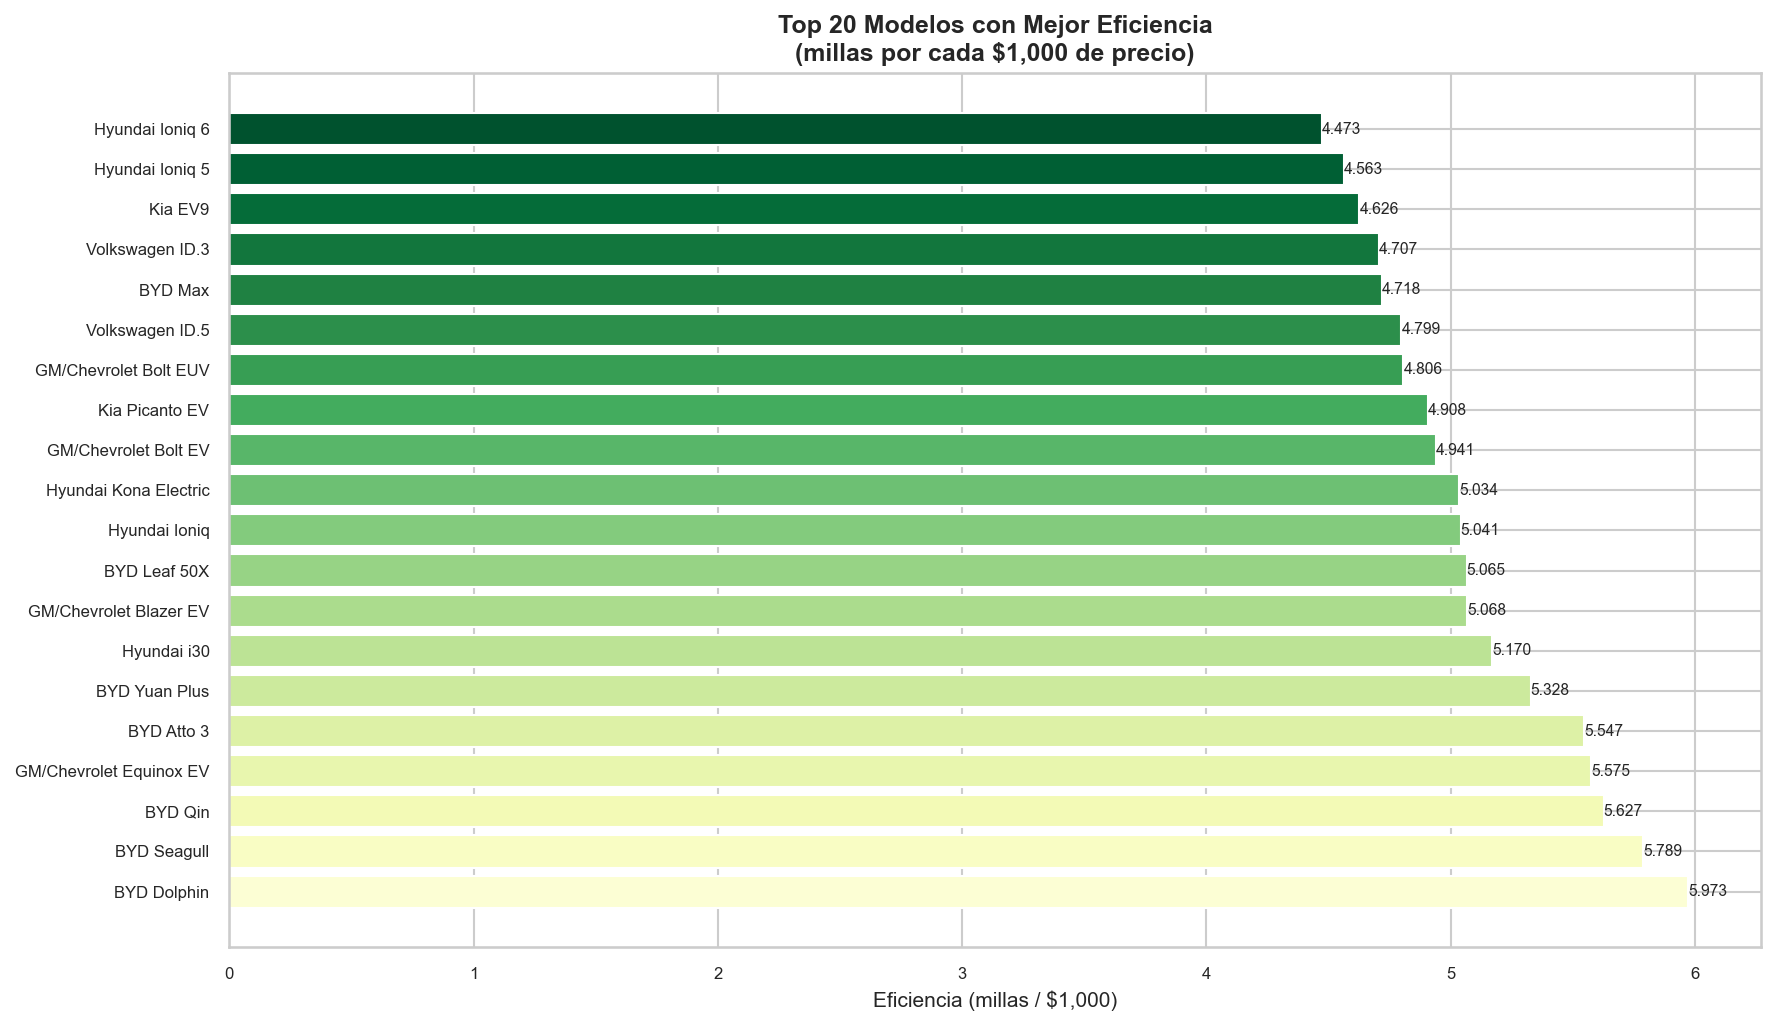

In [29]:
top_eficiencia = (
    df_main.groupby(['brand', 'model'])['efficiency']
    .mean()
    .reset_index()
    .sort_values('efficiency', ascending=False)
    .head(20)
)
top_eficiencia['label'] = top_eficiencia['brand'] + ' ' + top_eficiencia['model']

fig, ax = plt.subplots(figsize=(12, 7))
colores = sns.color_palette('YlGn', 20)
bars = ax.barh(top_eficiencia['label'], top_eficiencia['efficiency'],
               color=colores, edgecolor='white')

for bar, val in zip(bars, top_eficiencia['efficiency']):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7.5)

ax.set_title('Top 20 Modelos con Mejor Eficiencia\n(millas por cada $1,000 de precio)',
             fontweight='bold')
ax.set_xlabel('Eficiencia (millas / $1,000)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('2_2_top20_eficiencia.png', bbox_inches='tight')
plt.show()

### 5.3.4) Eficiencia promedio por marca

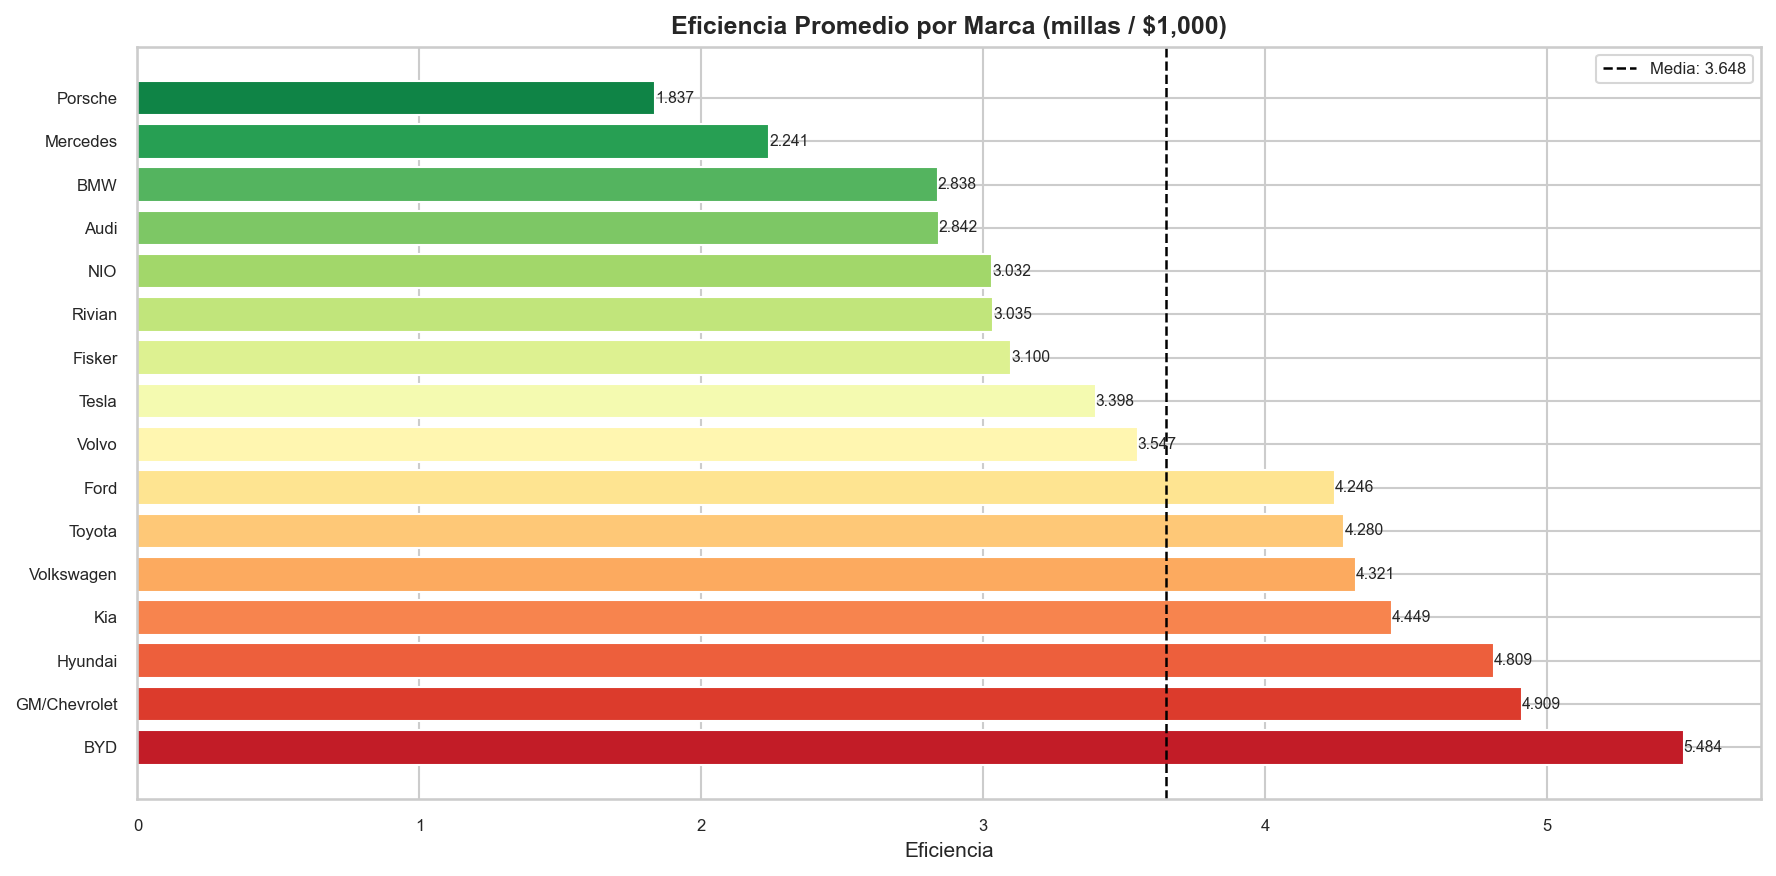

In [30]:
eficiencia_marca = (
    df_main.groupby('brand')['efficiency']
    .mean()
    .round(4)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))
colores = sns.color_palette('RdYlGn', len(eficiencia_marca))
bars = ax.barh(eficiencia_marca.index, eficiencia_marca.values,
               color=colores, edgecolor='white')

for bar, val in zip(bars, eficiencia_marca.values):
    ax.text(val + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7.5)

ax.axvline(eficiencia_marca.mean(), color='black', linestyle='--', linewidth=1.2,
           label=f'Media: {eficiencia_marca.mean():.3f}')
ax.legend(fontsize=8)
ax.set_title('Eficiencia Promedio por Marca (millas / $1,000)', fontweight='bold')
ax.set_xlabel('Eficiencia')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('2_3_eficiencia_por_marca.png', bbox_inches='tight')
plt.show()

### 5.3.5) Modelos de lujos: los más vendidos vs los sobrevalorados

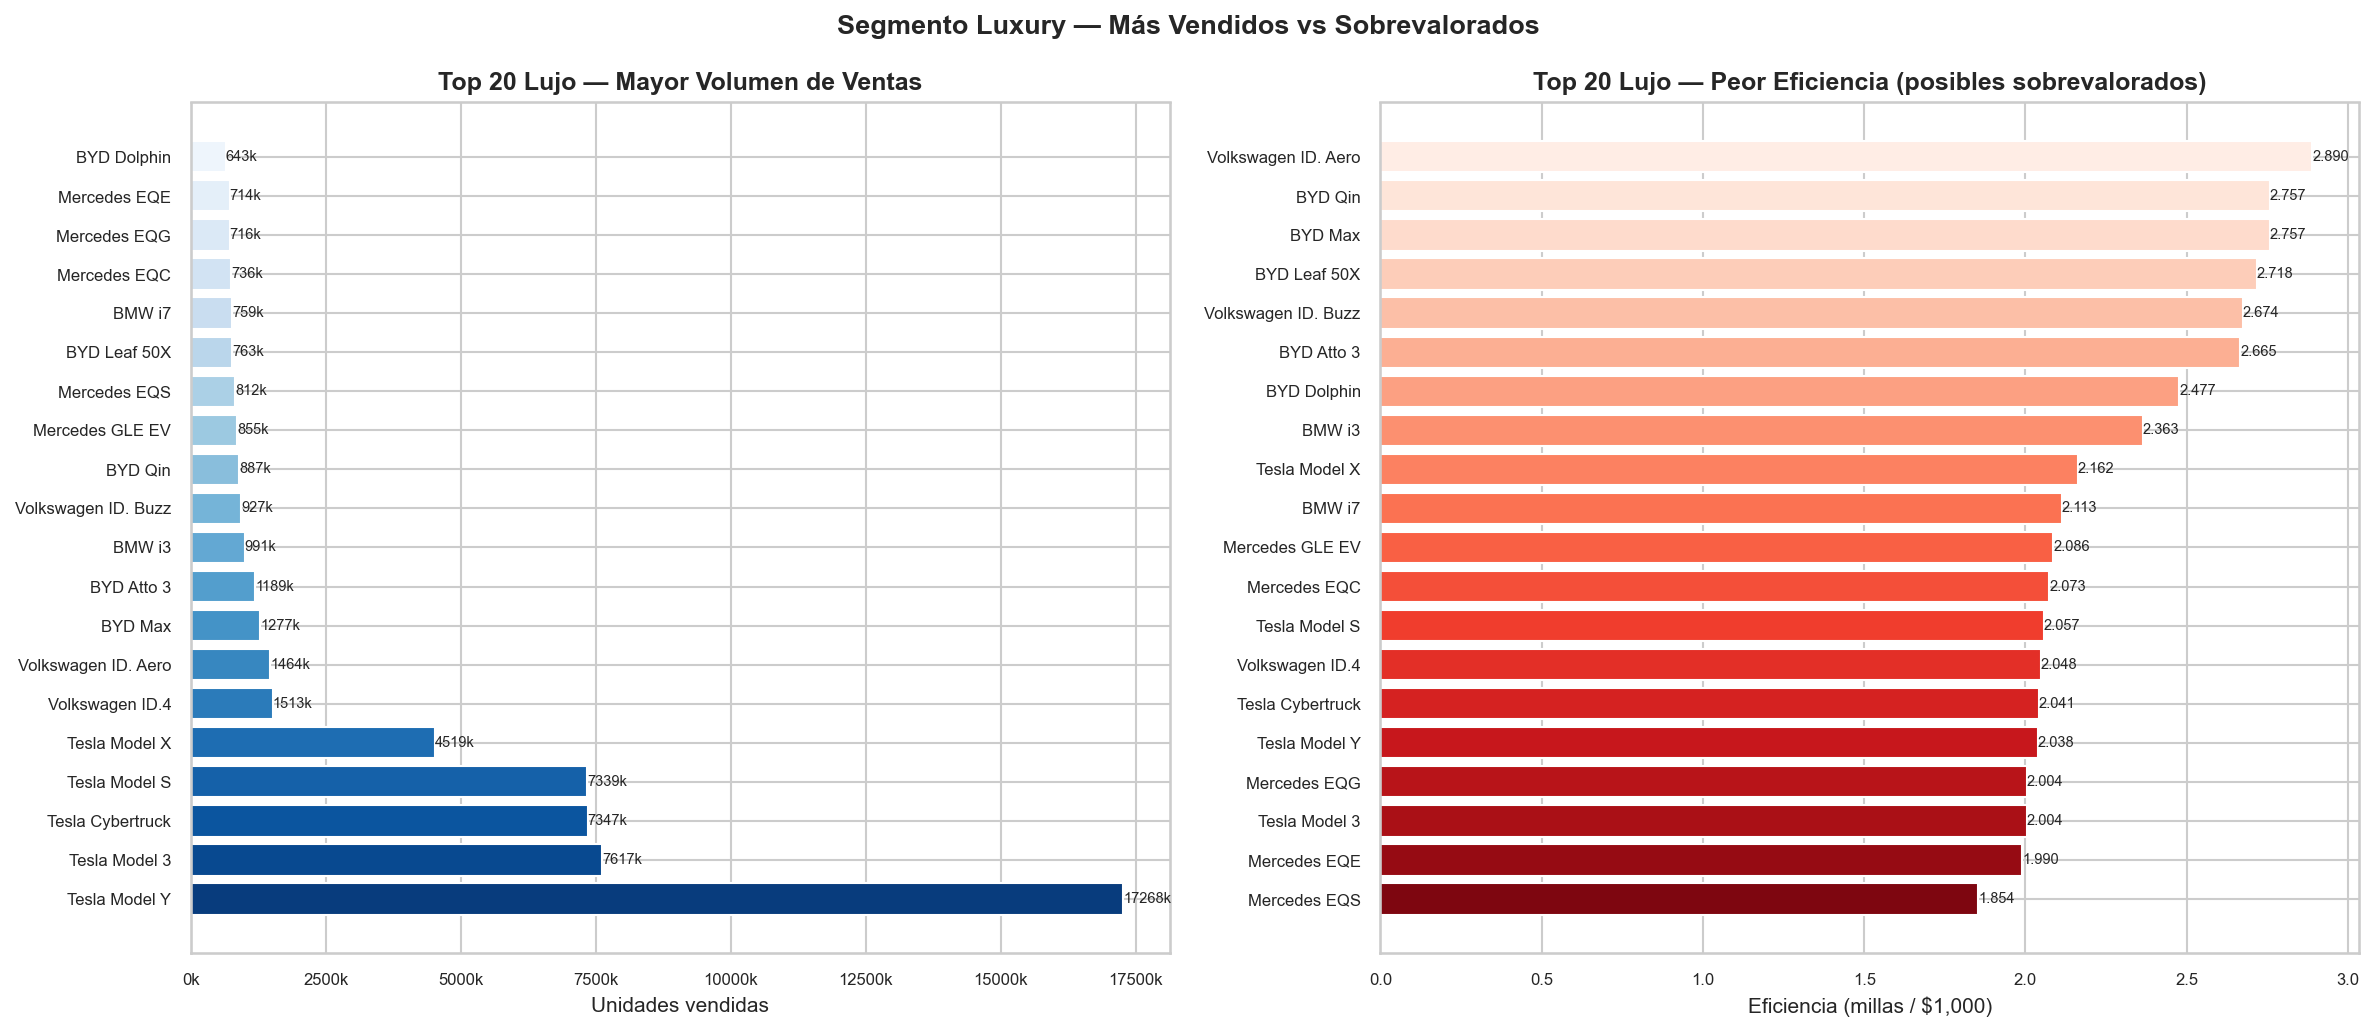

,label,precio_medio,autonomia_media,eficiencia,ventas
34,Mercedes EQS,143249.62,263.67,1.85,812227
32,Mercedes EQE,133503.78,257.77,1.99,713986
47,Tesla Model 3,132441.86,262.48,2.00,7617396
33,Mercedes EQG,138186.65,269.87,2.00,715525
50,Tesla Model Y,127737.66,258.92,2.04,17268152
46,Tesla Cybertruck,131888.61,264.20,2.04,7347345
54,Volkswagen ID.4,108948.98,221.50,2.05,1513484
48,Tesla Model S,132639.25,267.83,2.06,7339121
31,Mercedes EQC,150708.29,300.56,2.07,736312
35,Mercedes GLE EV,140834.81,277.60,2.09,855163


In [31]:
lujo = df_main[df_main['market_segment'] == 'Luxury'].copy()

lujo_resumen = (
    lujo.groupby(['brand', 'model'])
    .agg(
        precio_medio    = ('price_usd',           'mean'),
        autonomia_media = ('range_miles',          'mean'),
        eficiencia      = ('efficiency',           'mean'),
        ventas          = ('annual_sales_units',   'sum'),
    )
    .reset_index()
    .sort_values('ventas', ascending=False)
    .head(20)
)
lujo_resumen['label'] = lujo_resumen['brand'] + ' ' + lujo_resumen['model']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Izquierda: más vendidos
ax = axes[0]
colores_v = sns.color_palette('Blues_r', len(lujo_resumen))
bars = ax.barh(lujo_resumen['label'], lujo_resumen['ventas'],
               color=colores_v, edgecolor='white')
for bar, val in zip(bars, lujo_resumen['ventas']):
    ax.text(val + 500, bar.get_y() + bar.get_height()/2,
            f'{val/1e3:.0f}k', va='center', fontsize=7)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.set_title('Top 20 Lujo — Mayor Volumen de Ventas', fontweight='bold')
ax.set_xlabel('Unidades vendidas')

# Derecha: peor eficiencia (sobrevalorados)
lujo_sob = lujo_resumen.sort_values('eficiencia', ascending=True).head(20)
ax = axes[1]
colores_e = sns.color_palette('Reds_r', len(lujo_sob))
bars = ax.barh(lujo_sob['label'], lujo_sob['eficiencia'],
               color=colores_e, edgecolor='white')
for bar, val in zip(bars, lujo_sob['eficiencia']):
    ax.text(val + 0.0001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7)
ax.set_title('Top 20 Lujo — Peor Eficiencia (posibles sobrevalorados)', fontweight='bold')
ax.set_xlabel('Eficiencia (millas / $1,000)')

plt.suptitle('Segmento Luxury — Más Vendidos vs Sobrevalorados', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('2_4_lujo_ventas_vs_eficiencia.png', bbox_inches='tight')
plt.show()

display(lujo_resumen.sort_values('eficiencia').head(10)[
    ['label','precio_medio','autonomia_media','eficiencia','ventas']
].round(2))

### 5.3.6) Boxplot de eficiencia por segmento

C:\Users\andy_\AppData\Local\Temp\ipykernel_16624\3307067097.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


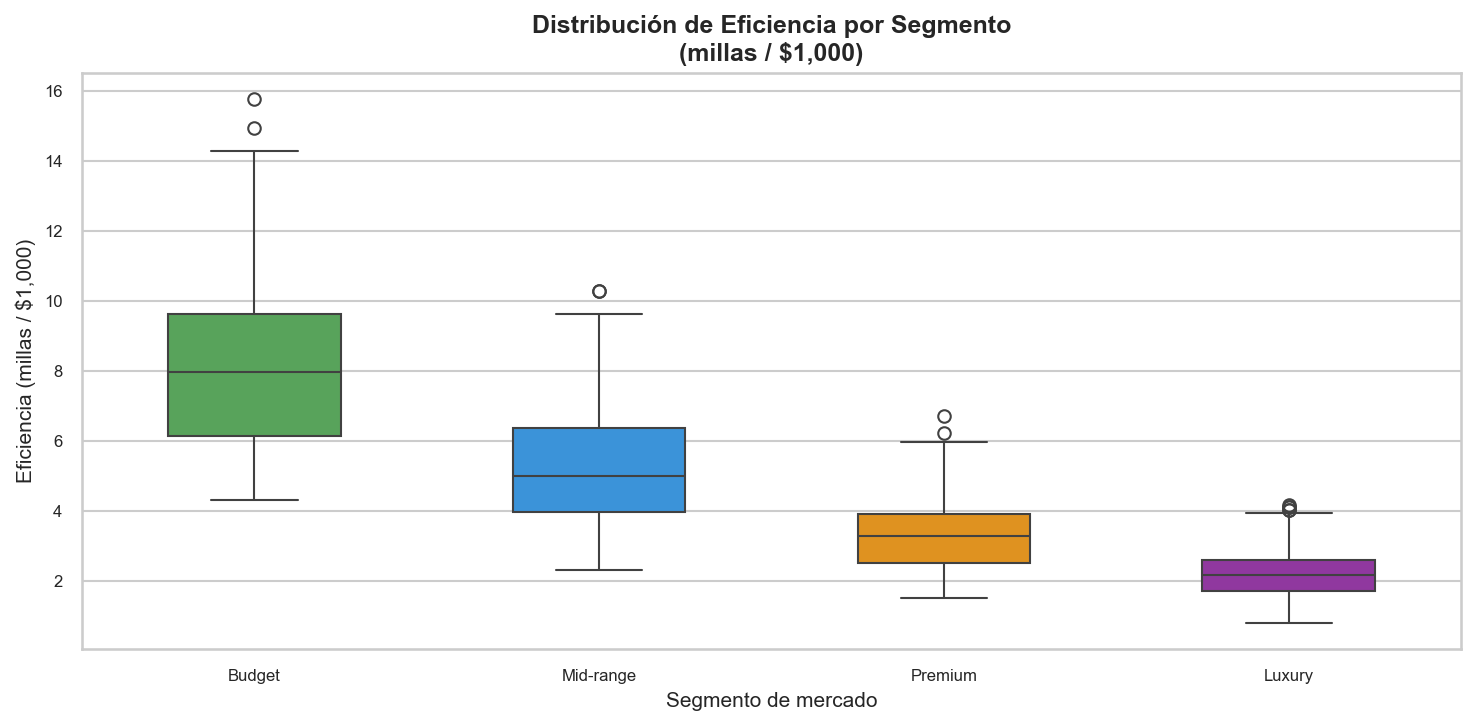

In [32]:
orden_seg = ['Budget', 'Mid-range', 'Premium', 'Luxury']

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df_main,
    x='market_segment', y='efficiency',
    order=orden_seg,
    palette=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0'],
    ax=ax, width=0.5
)
ax.set_title('Distribución de Eficiencia por Segmento\n(millas / $1,000)',
             fontweight='bold')
ax.set_xlabel('Segmento de mercado')
ax.set_ylabel('Eficiencia (millas / $1,000)')
plt.tight_layout()
plt.savefig('2_5_eficiencia_por_segmento.png', bbox_inches='tight')
plt.show()

- El scatter lo confirma perfectamente — pagar más no garantiza más autonomía, especialmente en Luxury. Y el dato de BYD Dolphin liderando eficiencia con 5.97 millas/$1k frente a Porsche con 1.84 es brutal.
- Un matiz sobre el gráfico de lujo: que los BYD y Volkswagen aparezcan como "peor eficiencia en lujo" no significa que sean malos coches, sino que sus modelos clasificados como Luxury en el dataset tienen precios altos para lo que ofrecen — son marcas que normalmente brillan en otros segmentos.

## Evolución de tecnología de las baterías

### 5.4.1) Imports y preparación

In [33]:
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.facecolor': 'white',
})

df = pd.read_csv(r"C:\Users\andy_\Documents\Datasets\ev_market_2026.csv")
marcas_principales = df['brand'].value_counts()[df['brand'].value_counts() >= 10].index
df_main = df[df['brand'].isin(marcas_principales)].copy()

# Métrica adicional: eficiencia energética (millas por kWh)
df_main['miles_per_kwh'] = df_main['range_miles'] / df_main['battery_capacity_kwh']

print(df_main.groupby('year')[['battery_capacity_kwh','charging_speed_kw','miles_per_kwh']].mean().round(2))

      battery_capacity_kwh  charging_speed_kw  miles_per_kwh
year                                                        
2020                 77.75             125.34           3.47
2021                 79.15             159.66           3.49
2022                 74.03             152.31           3.50
2023                 73.45             157.72           3.50
2024                 75.38             154.39           3.52
2025                 73.56             156.10           3.51
2026                 76.49             155.26           3.52


### 5.4.2) Capacidad media de batería por año

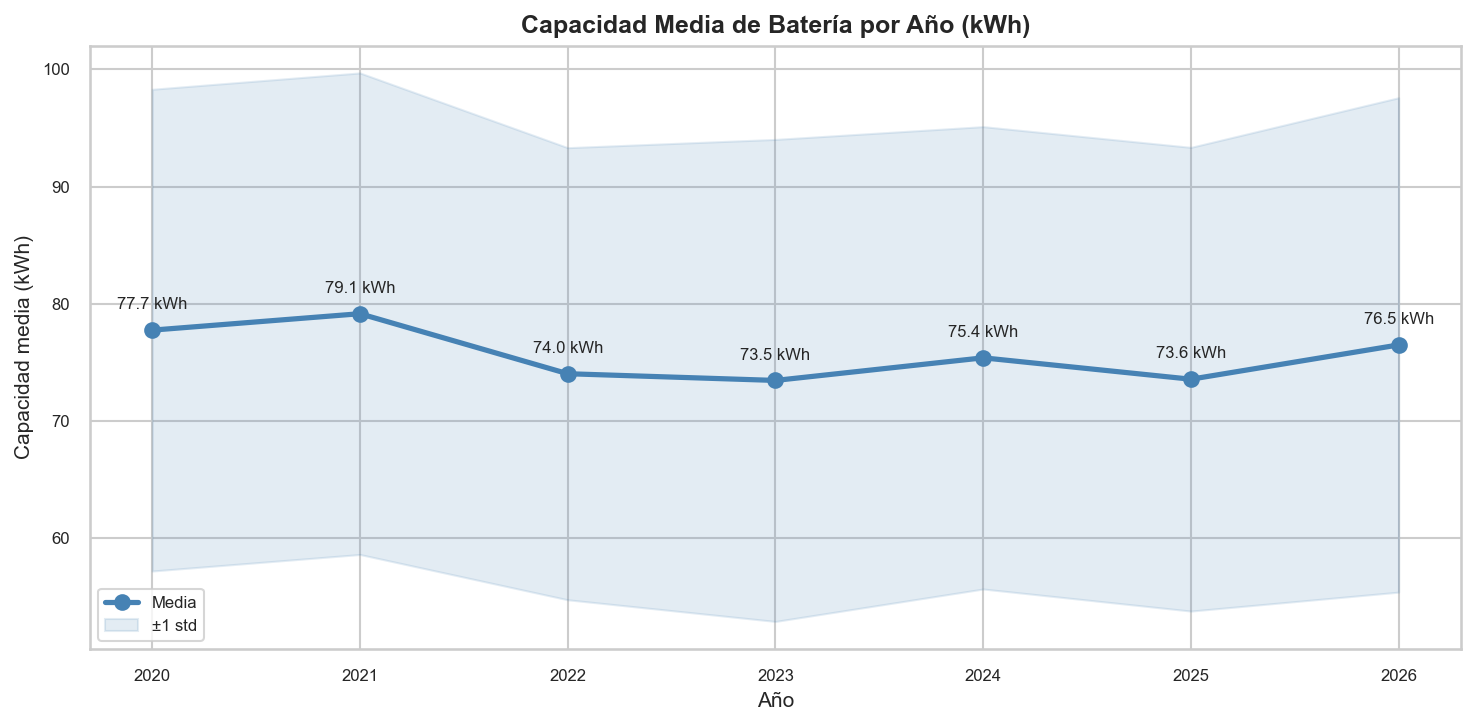

In [34]:
bateria_anual = df_main.groupby('year')['battery_capacity_kwh'].agg(['mean','std']).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(bateria_anual['year'], bateria_anual['mean'], marker='o',
        color='steelblue', linewidth=2.5, markersize=7, label='Media')
ax.fill_between(bateria_anual['year'],
                bateria_anual['mean'] - bateria_anual['std'],
                bateria_anual['mean'] + bateria_anual['std'],
                alpha=0.15, color='steelblue', label='±1 std')

for _, row in bateria_anual.iterrows():
    ax.annotate(f"{row['mean']:.1f} kWh", (row['year'], row['mean']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8)

ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_title('Capacidad Media de Batería por Año (kWh)', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Capacidad media (kWh)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('5_1_bateria_por_anio.png', bbox_inches='tight')
plt.show()

### 5.4.3) Velocidad de carga media por año

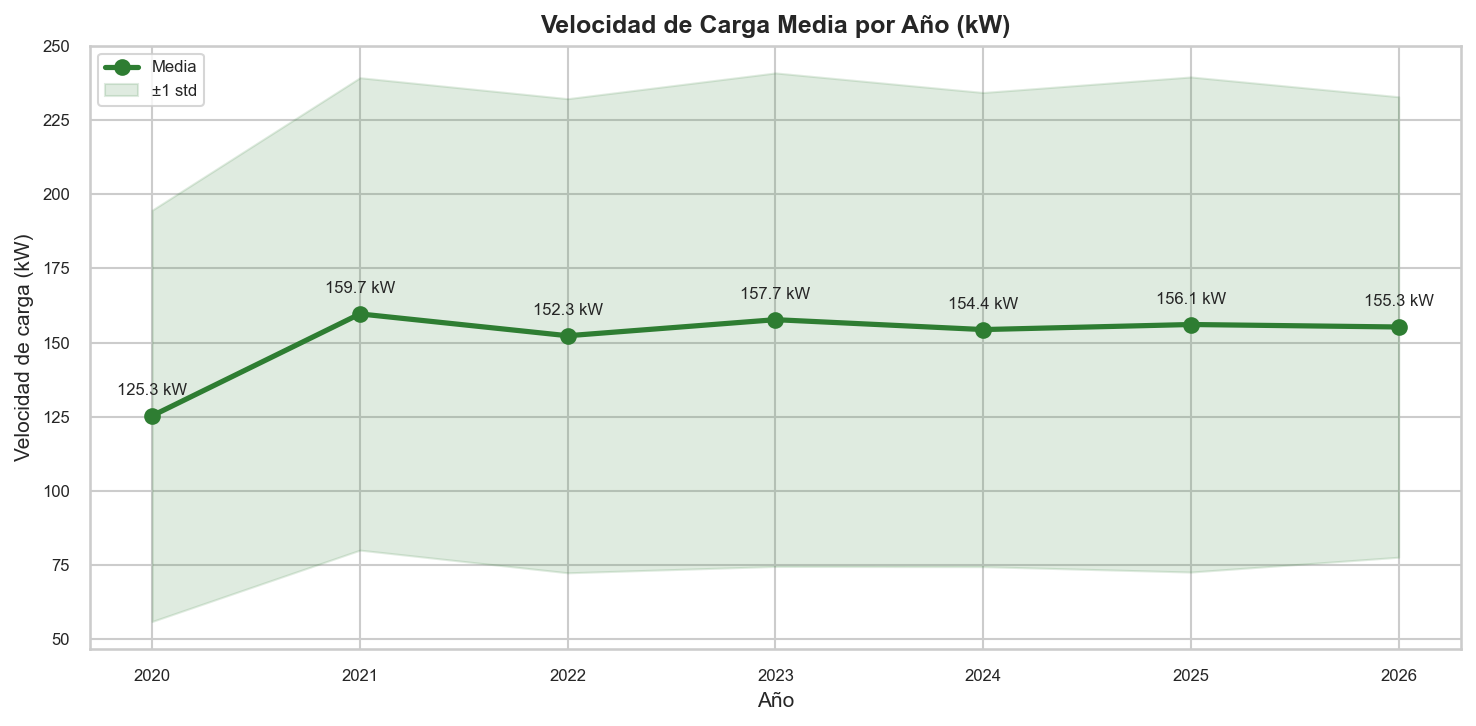

In [35]:
carga_anual = df_main.groupby('year')['charging_speed_kw'].agg(['mean','std']).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(carga_anual['year'], carga_anual['mean'], marker='o',
        color='#2e7d32', linewidth=2.5, markersize=7, label='Media')
ax.fill_between(carga_anual['year'],
                carga_anual['mean'] - carga_anual['std'],
                carga_anual['mean'] + carga_anual['std'],
                alpha=0.15, color='#2e7d32', label='±1 std')

for _, row in carga_anual.iterrows():
    ax.annotate(f"{row['mean']:.1f} kW", (row['year'], row['mean']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8)

ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_title('Velocidad de Carga Media por Año (kW)', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Velocidad de carga (kW)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('5_2_carga_por_anio.png', bbox_inches='tight')
plt.show()

### 5.4.4) Eficiencia energética: millas por kWh por año

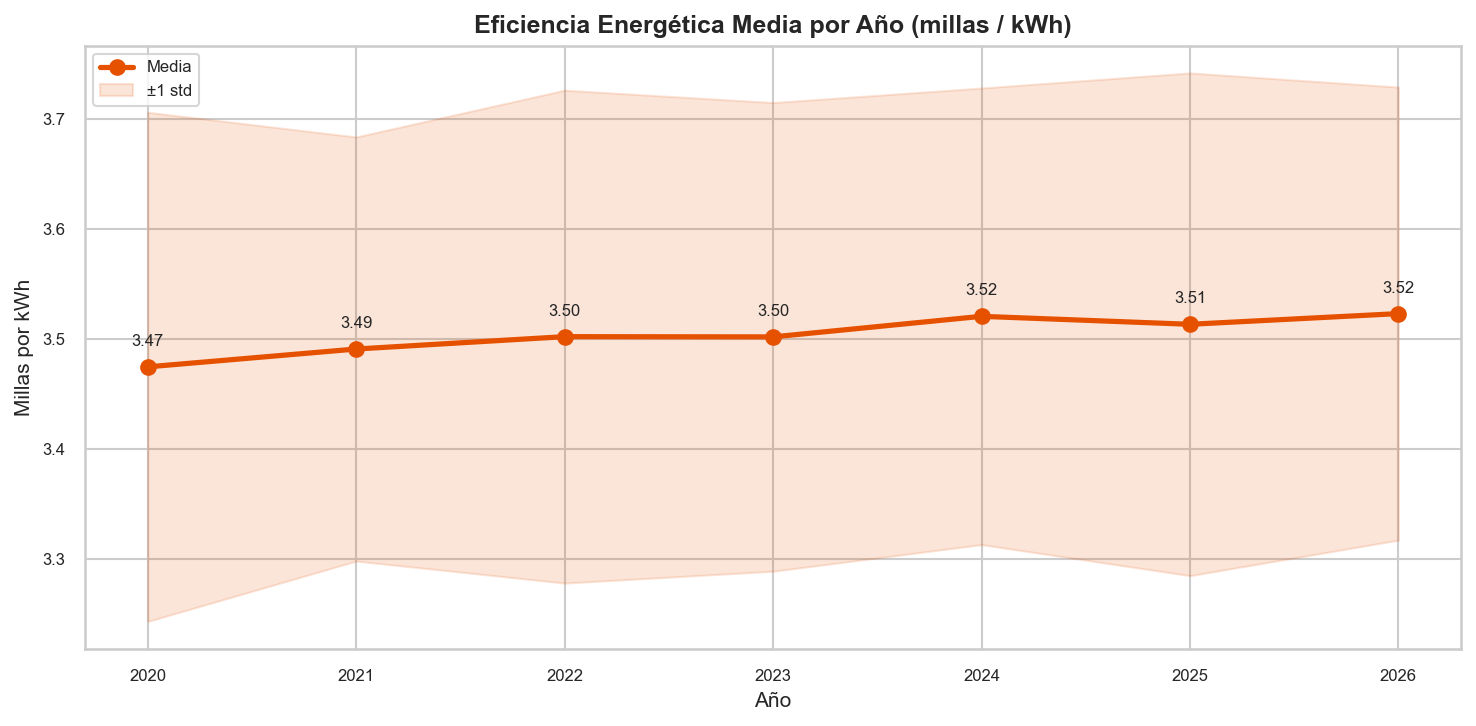

In [36]:
eficiencia_anual = df_main.groupby('year')['miles_per_kwh'].agg(['mean','std']).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(eficiencia_anual['year'], eficiencia_anual['mean'], marker='o',
        color='#e65100', linewidth=2.5, markersize=7, label='Media')
ax.fill_between(eficiencia_anual['year'],
                eficiencia_anual['mean'] - eficiencia_anual['std'],
                eficiencia_anual['mean'] + eficiencia_anual['std'],
                alpha=0.15, color='#e65100', label='±1 std')

for _, row in eficiencia_anual.iterrows():
    ax.annotate(f"{row['mean']:.2f}", (row['year'], row['mean']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8)

ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_title('Eficiencia Energética Media por Año (millas / kWh)', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Millas por kWh')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('5_3_eficiencia_kwh_anio.png', bbox_inches='tight')
plt.show()

### 5.4.5) Las 3 métricas juntas (panel comparativo)

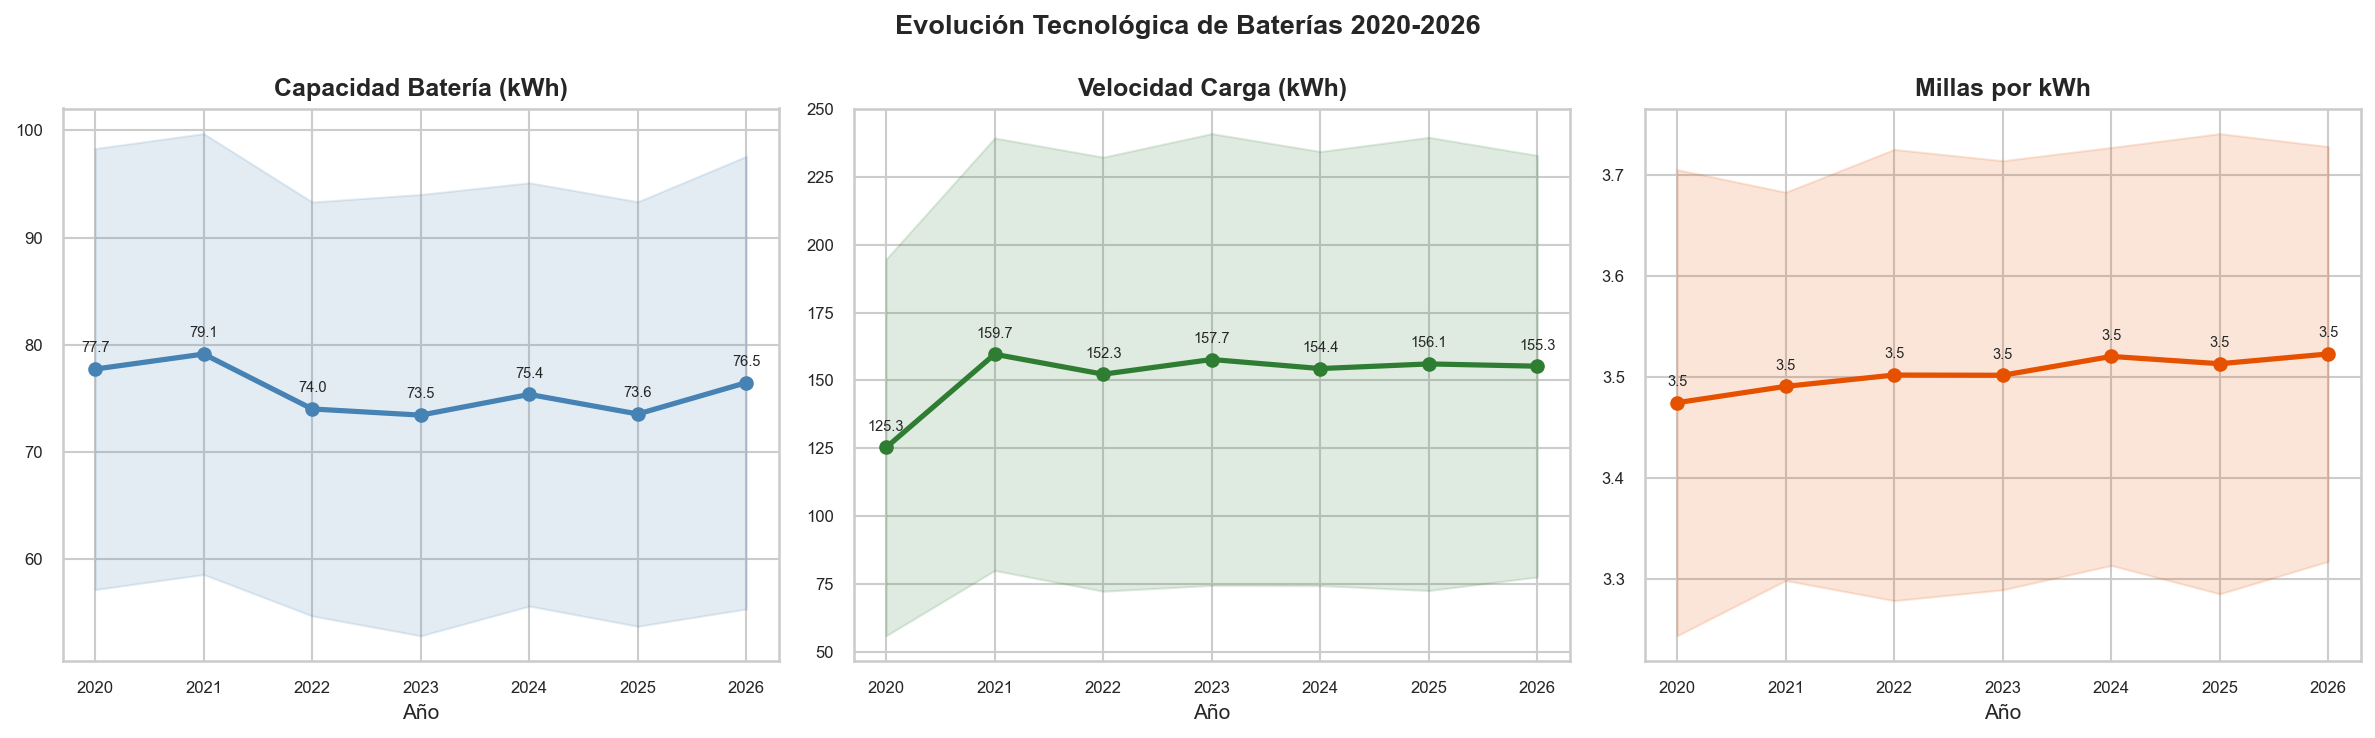

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metricas = [
    ('battery_capacity_kwh', 'Capacidad Batería (kWh)', 'steelblue'),
    ('charging_speed_kw',    'Velocidad Carga (kWh)',   '#2e7d32'),
    ('miles_per_kwh',        'Millas por kWh',          '#e65100'),
]

for ax, (col, titulo, color) in zip(axes, metricas):
    datos = df_main.groupby('year')[col].agg(['mean','std']).reset_index()
    ax.plot(datos['year'], datos['mean'], marker='o', color=color,
            linewidth=2.5, markersize=6)
    ax.fill_between(datos['year'],
                    datos['mean'] - datos['std'],
                    datos['mean'] + datos['std'],
                    alpha=0.15, color=color)
    for _, row in datos.iterrows():
        ax.annotate(f"{row['mean']:.1f}", (row['year'], row['mean']),
                    textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=7)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Año')

plt.suptitle('Evolución Tecnológica de Baterías 2020-2026', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('5_4_panel_tecnologia.png', bbox_inches='tight')
plt.show()

### 5.4.6) Distribución de capacidad de batería por segmento y año

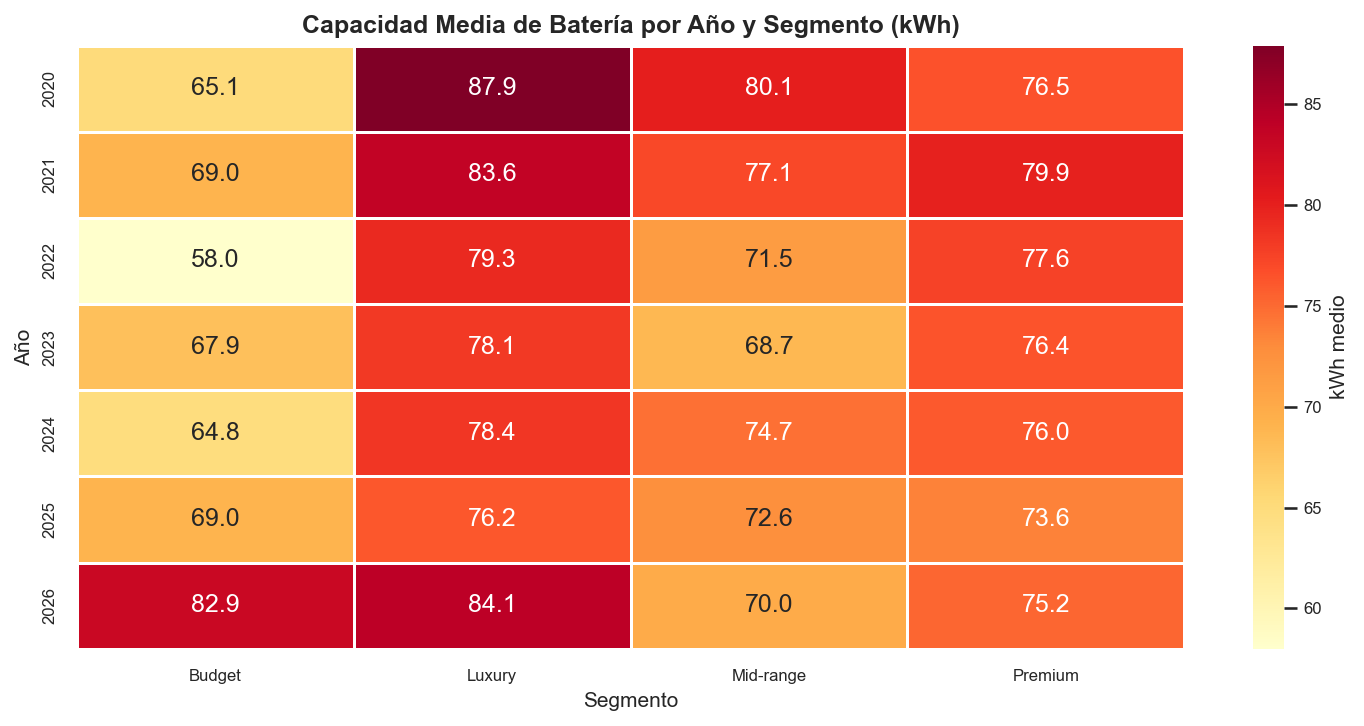

In [38]:
heat_data = (
    df_main.groupby(['year', 'market_segment'])['battery_capacity_kwh']
    .mean()
    .round(1)
    .unstack()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    heat_data,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'kWh medio'}
)
ax.set_title('Capacidad Media de Batería por Año y Segmento (kWh)', fontweight='bold')
ax.set_ylabel('Año')
ax.set_xlabel('Segmento')
plt.tight_layout()
plt.savefig('5_5_heatmap_bateria_segmento.png', bbox_inches='tight')
plt.show()

### 5.4.7) Autonomía media por año y segmento

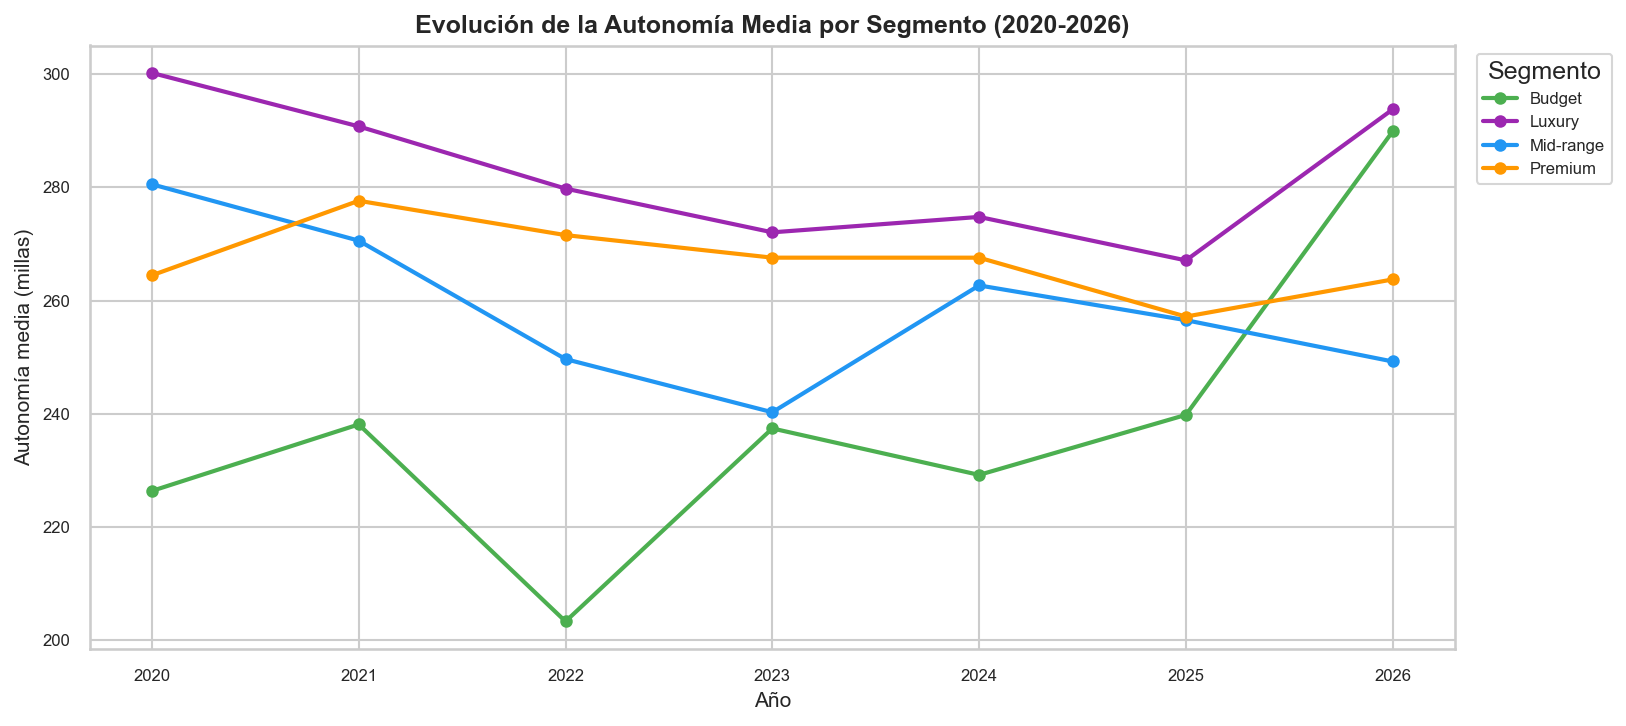

In [39]:
autonomia_seg_anio = (
    df_main.groupby(['year', 'market_segment'])['range_miles']
    .mean()
    .reset_index()
)

colores_seg = {
    'Budget': '#4CAF50',
    'Mid-range': '#2196F3',
    'Premium': '#FF9800',
    'Luxury': '#9C27B0'
}

fig, ax = plt.subplots(figsize=(11, 5))
for seg, grupo in autonomia_seg_anio.groupby('market_segment'):
    grupo = grupo.sort_values('year')
    ax.plot(grupo['year'], grupo['range_miles'], marker='o',
            label=seg, color=colores_seg[seg], linewidth=2, markersize=5)

ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_title('Evolución de la Autonomía Media por Segmento (2020-2026)', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Autonomía media (millas)')
ax.legend(title='Segmento', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('5_6_autonomia_segmento_anio.png', bbox_inches='tight')
plt.show()

La caída de Mid-range de 80 a 70 kWh en 6 años sí es llamativa — sugiere que los fabricantes están apostando por baterías más pequeñas y eficientes en ese segmento, priorizando el precio sobre la capacidad bruta. Coherente con lo que vimos en millas/kWh, donde la eficiencia sí mejora ligeramente.

## Fase 2 Análisis de negocio

## Budget vs Luxury

### 5.5.1) Import y definición de segmentos

In [40]:
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.facecolor': 'white',
})

df = pd.read_csv(r"C:\Users\andy_\Documents\Datasets\ev_market_2026.csv")

# Definición estricta por precio según el enunciado
budget  = df[df['price_usd'] < 35_000].copy()
luxury  = df[df['price_usd'] > 100_000].copy()
midzone = df[(df['price_usd'] >= 35_000) & (df['price_usd'] <= 100_000)].copy()

print(f"Budget  (<$35k):      {len(budget):>5} registros | precio medio: ${budget['price_usd'].mean():,.0f}")
print(f"Mid zone ($35-100k):  {len(midzone):>5} registros | precio medio: ${midzone['price_usd'].mean():,.0f}")
print(f"Luxury  (>$100k):     {len(luxury):>5} registros | precio medio: ${luxury['price_usd'].mean():,.0f}")

Budget  (<$35k):        151 registros | precio medio: $29,321
Mid zone ($35-100k):   1354 registros | precio medio: $66,682
Luxury  (>$100k):       495 registros | precio medio: $127,340


### 5.5.2) Comparativa de métricas clave

                      Budget  Mid zone  Luxury
Autonomía (mi)        236.09    259.77  275.29
Carga (kW)            127.69    143.48  195.68
Aceleración 0-60 (s)    6.19      5.69    5.30
Batería (kWh)          67.53     74.01   78.64
Potencia (hp)         231.49    624.23  911.78
Safety rating           4.33      4.37    4.41
Customer rating         3.45      3.54    3.70
Garantía (años)         4.01      4.36    5.35


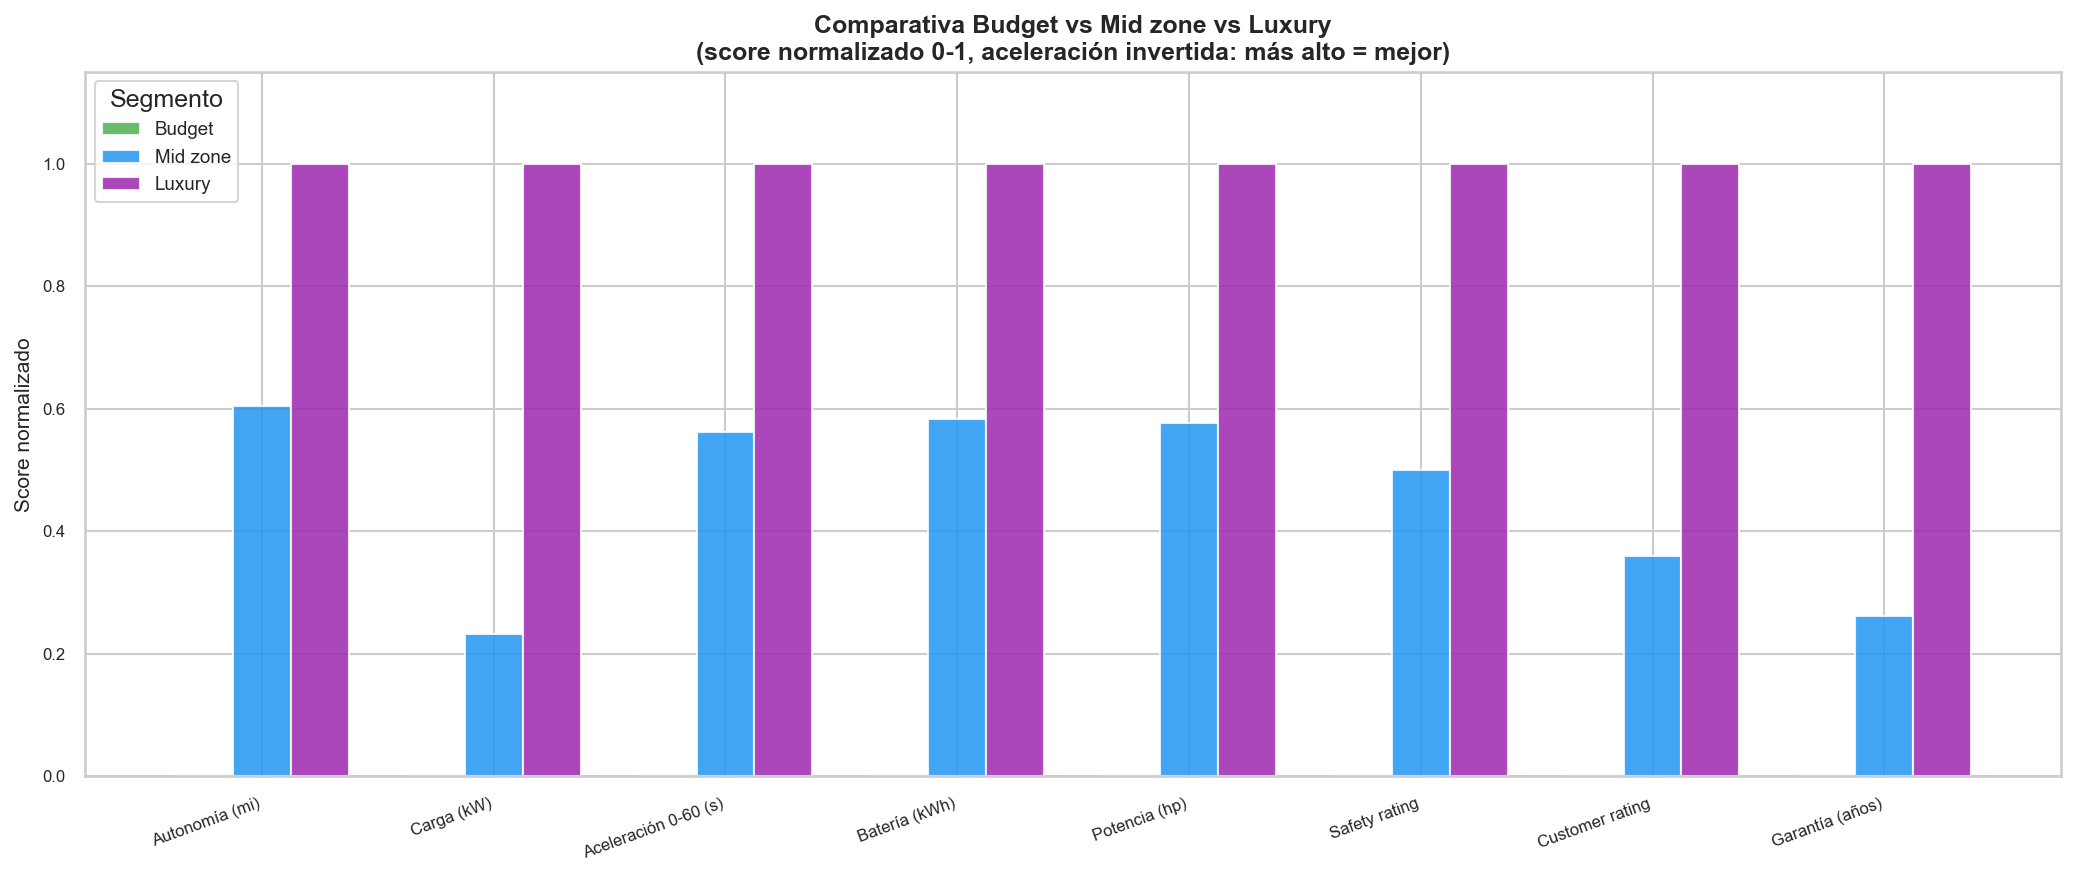

In [41]:
metricas = {
    'Autonomía (mi)':        'range_miles',
    'Carga (kW)':            'charging_speed_kw',
    'Aceleración 0-60 (s)':  'acceleration_0_60_mph',
    'Batería (kWh)':         'battery_capacity_kwh',
    'Potencia (hp)':         'horsepower',
    'Safety rating':         'safety_rating',
    'Customer rating':       'customer_rating',
    'Garantía (años)':       'warranty_years',
}

resumen = pd.DataFrame({
    'Budget':  {k: budget[v].mean()  for k, v in metricas.items()},
    'Mid zone':{k: midzone[v].mean() for k, v in metricas.items()},
    'Luxury':  {k: luxury[v].mean()  for k, v in metricas.items()},
}).round(2)

print(resumen)

# Normalizar para visualización radar-style en barras
resumen_norm = resumen.copy()
for idx in resumen_norm.index:
    # Aceleración: invertir (menos segundos = mejor)
    if idx == 'Aceleración 0-60 (s)':
        resumen_norm.loc[idx] = 1 - (resumen.loc[idx] - resumen.loc[idx].min()) / \
                                     (resumen.loc[idx].max() - resumen.loc[idx].min() + 1e-9)
    else:
        resumen_norm.loc[idx] = (resumen.loc[idx] - resumen.loc[idx].min()) / \
                                 (resumen.loc[idx].max() - resumen.loc[idx].min() + 1e-9)

x = np.arange(len(metricas))
width = 0.25
colores = {'Budget': '#4CAF50', 'Mid zone': '#2196F3', 'Luxury': '#9C27B0'}

fig, ax = plt.subplots(figsize=(14, 6))
for i, (seg, color) in enumerate(colores.items()):
    bars = ax.bar(x + i*width, resumen_norm[seg], width, label=seg,
                  color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(list(metricas.keys()), rotation=20, ha='right')
ax.set_title('Comparativa Budget vs Mid zone vs Luxury\n(score normalizado 0-1, aceleración invertida: más alto = mejor)',
             fontweight='bold')
ax.set_ylabel('Score normalizado')
ax.legend(title='Segmento', fontsize=9)
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.savefig('8_1_comparativa_segmentos.png', bbox_inches='tight')
plt.show()

### 5.5.3) Distribuciones superpuestas: autonoía, carga y aceleración

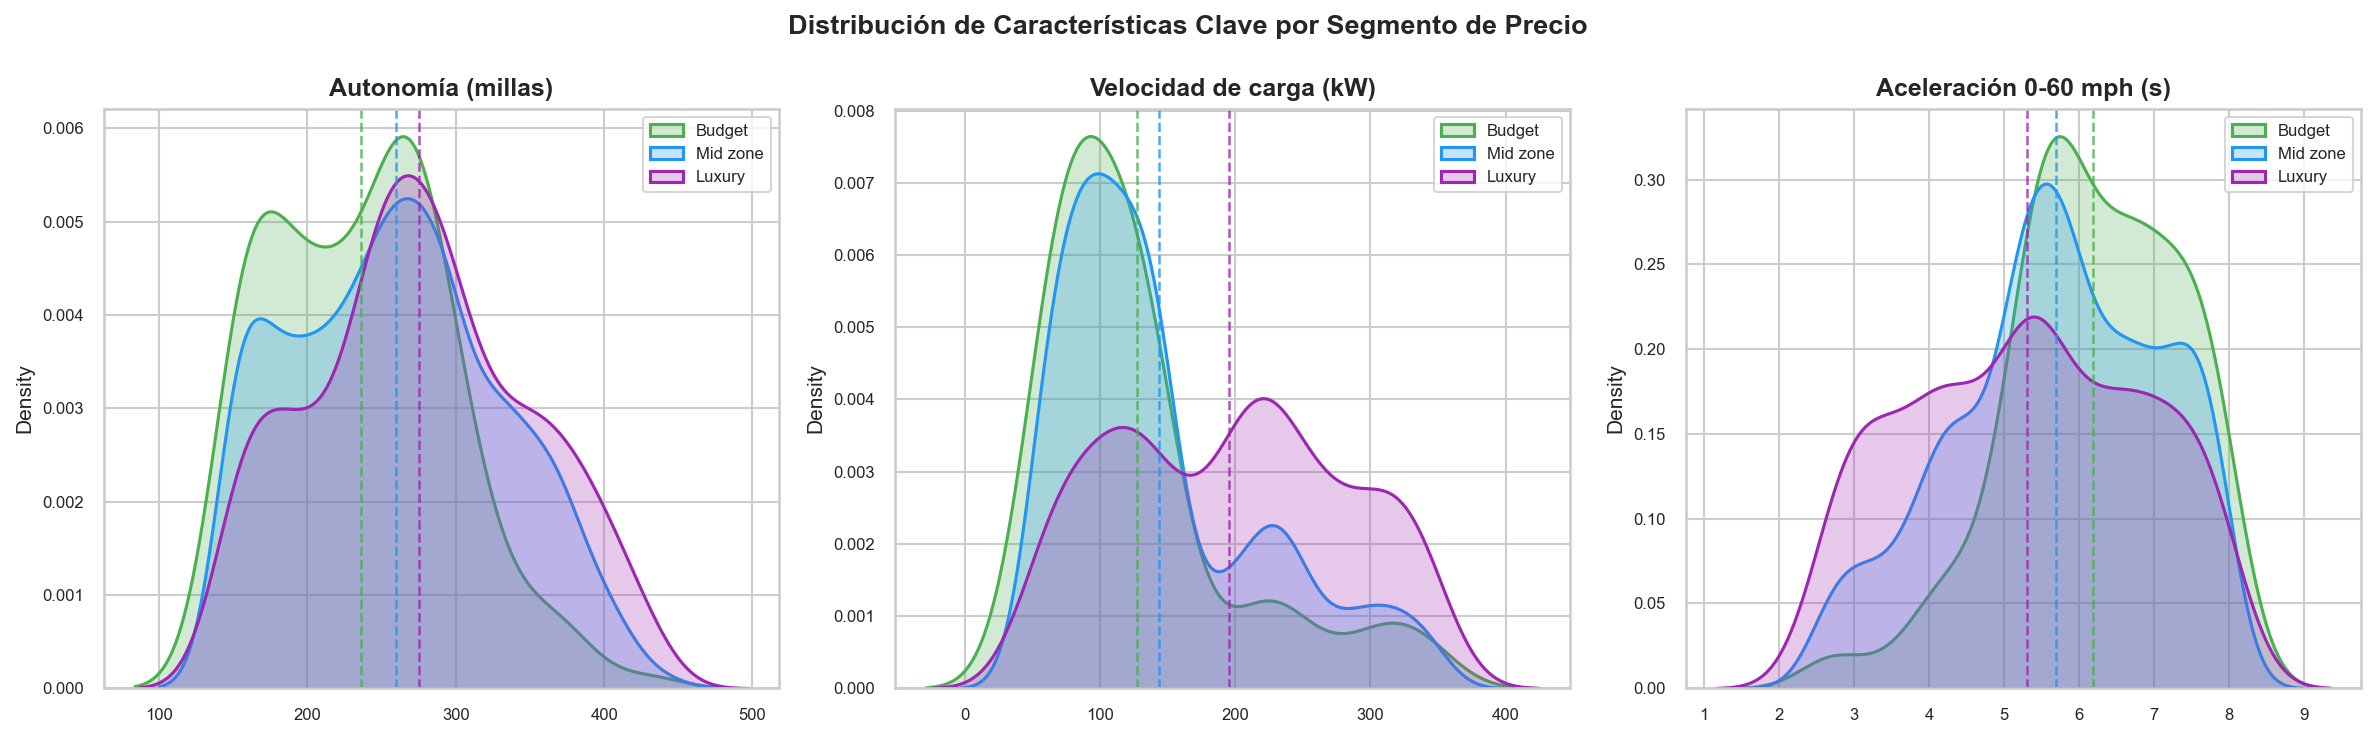

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cols_dist = [
    ('range_miles',           'Autonomía (millas)'),
    ('charging_speed_kw',     'Velocidad de carga (kW)'),
    ('acceleration_0_60_mph', 'Aceleración 0-60 mph (s)'),
]

for ax, (col, titulo) in zip(axes, cols_dist):
    for seg, datos, color in [
        ('Budget',   budget,  '#4CAF50'),
        ('Mid zone', midzone, '#2196F3'),
        ('Luxury',   luxury,  '#9C27B0'),
    ]:
        sns.kdeplot(datos[col], ax=ax, label=seg, color=color,
                    fill=True, alpha=0.25, linewidth=1.5)
        ax.axvline(datos[col].mean(), color=color, linestyle='--',
                   linewidth=1.2, alpha=0.8)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de Características Clave por Segmento de Precio',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('8_2_distribuciones.png', bbox_inches='tight')
plt.show()

### 5.5.4) ¿Justifican las especificaciones el precio? Ratio valor

In [43]:
# Precio medio, autonomía media y ratio autonomia/precio para los 3 segmentos
segmentos = {'Budget': budget, 'Mid zone': midzone, 'Luxury': luxury}

tabla_valor = pd.DataFrame({
    seg: {
        'Precio medio ($)':          datos['price_usd'].mean(),
        'Autonomía media (mi)':       datos['range_miles'].mean(),
        'Carga media (kW)':           datos['charging_speed_kw'].mean(),
        'Aceleración media (s)':      datos['acceleration_0_60_mph'].mean(),
        'Potencia media (hp)':        datos['horsepower'].mean(),
        'mi / $1,000':                (datos['range_miles'] / datos['price_usd'] * 1000).mean(),
        'kW / $10,000':               (datos['charging_speed_kw'] / datos['price_usd'] * 10000).mean(),
        'Customer rating':            datos['customer_rating'].mean(),
    }
    for seg, datos in segmentos.items()
}).round(2)

display(tabla_valor)

# Incremento relativo Budget → Luxury
tabla_valor['Lujo vs Budget (%)'] = ((tabla_valor['Luxury'] / tabla_valor['Budget'] - 1) * 100).round(1)
display(tabla_valor[['Budget', 'Luxury', 'Lujo vs Budget (%)']])

,Budget,Mid zone,Luxury
Precio medio ($),29320.75,66681.76,127339.97
Autonomía media (mi),236.09,259.77,275.29
Carga media (kW),127.69,143.48,195.68
Aceleración media (s),6.19,5.69,5.30
Potencia media (hp),231.49,624.23,911.78
"mi / $1,000",8.25,4.18,2.23
"kW / $10,000",44.02,23.13,15.61
Customer rating,3.45,3.54,3.70


,Budget,Luxury,Lujo vs Budget (%)
Precio medio ($),29320.75,127339.97,334.3
Autonomía media (mi),236.09,275.29,16.6
Carga media (kW),127.69,195.68,53.2
Aceleración media (s),6.19,5.30,-14.4
Potencia media (hp),231.49,911.78,293.9
"mi / $1,000",8.25,2.23,-73.0
"kW / $10,000",44.02,15.61,-64.5
Customer rating,3.45,3.70,7.2


### 5.5.5 Zona de valor emergente: mid zone que supera a luxury

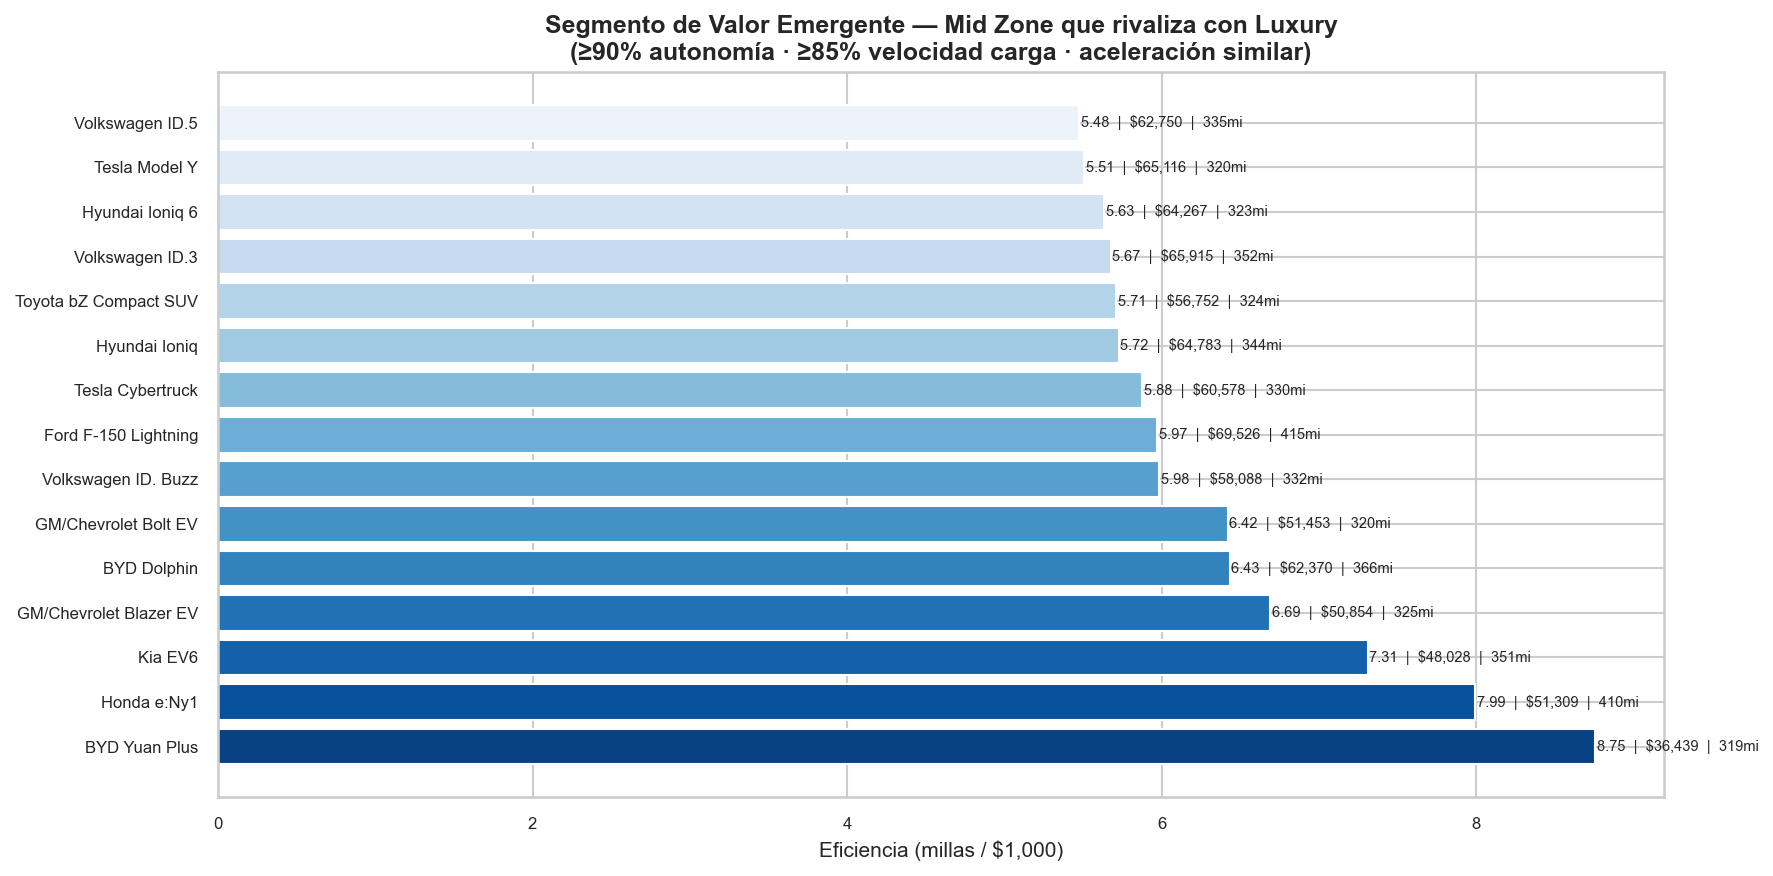

,label,precio_medio,autonomia_media,carga_media,aceleracion,efficiency,ventas
12,BYD Yuan Plus,36438.81,319.00,202.30,3.74,8.75,110969
23,Honda e:Ny1,51309.25,410.00,188.10,3.03,7.99,6885
29,Kia EV6,48028.48,351.00,182.00,3.29,7.31,81607
18,GM/Chevrolet Blazer EV,50854.45,325.00,182.40,4.18,6.69,27167
7,BYD Dolphin,62370.38,366.25,229.10,3.78,6.43,646635
20,GM/Chevrolet Bolt EV,51453.47,320.00,212.78,3.12,6.42,69042
48,Volkswagen ID. Buzz,58088.31,331.80,228.20,3.97,5.98,1293457
16,Ford F-150 Lightning,69526.30,415.00,202.70,2.68,5.97,23821
40,Tesla Cybertruck,60578.42,329.65,254.54,4.54,5.88,3198016
24,Hyundai Ioniq,64783.22,344.33,183.12,3.46,5.72,652631


In [44]:
# Modelos entre $35k-$100k que igualan o superan métricas clave de luxury
umbral_autonomia = luxury['range_miles'].mean()
umbral_carga     = luxury['charging_speed_kw'].mean()
umbral_accel     = luxury['acceleration_0_60_mph'].mean()

valor_emergente = midzone[
    (midzone['range_miles']           >= umbral_autonomia * 0.90) &
    (midzone['charging_speed_kw']     >= umbral_carga     * 0.85) &
    (midzone['acceleration_0_60_mph'] <= umbral_accel     * 1.15)
].copy()

valor_emergente['efficiency'] = (valor_emergente['range_miles'] / valor_emergente['price_usd']) * 1000

top_valor = (
    valor_emergente.groupby(['brand', 'model'])
    .agg(
        precio_medio    = ('price_usd',           'mean'),
        autonomia_media = ('range_miles',          'mean'),
        carga_media     = ('charging_speed_kw',    'mean'),
        aceleracion     = ('acceleration_0_60_mph','mean'),
        efficiency      = ('efficiency',           'mean'),
        ventas          = ('annual_sales_units',   'sum'),
    )
    .reset_index()
    .sort_values('efficiency', ascending=False)
    .head(15)
)
top_valor['label'] = top_valor['brand'] + ' ' + top_valor['model']

fig, ax = plt.subplots(figsize=(12, 6))
colores = sns.color_palette('Blues_r', len(top_valor))
bars = ax.barh(top_valor['label'], top_valor['efficiency'],
               color=colores, edgecolor='white')

for bar, row in zip(bars, top_valor.itertuples()):
    ax.text(row.efficiency + 0.01, bar.get_y() + bar.get_height()/2,
            f'{row.efficiency:.2f}  |  ${row.precio_medio:,.0f}  |  {row.autonomia_media:.0f}mi',
            va='center', fontsize=7)

ax.set_title('Segmento de Valor Emergente — Mid Zone que rivaliza con Luxury\n'
             '(≥90% autonomía · ≥85% velocidad carga · aceleración similar)',
             fontweight='bold')
ax.set_xlabel('Eficiencia (millas / $1,000)')
plt.tight_layout()
plt.savefig('8_3_valor_emergente.png', bbox_inches='tight')
plt.show()

display(top_valor[['label','precio_medio','autonomia_media','carga_media','aceleracion','efficiency','ventas']].round(2))

### 5.5.6) Test estadístico: ¿Son las diferencias significativas?

In [45]:
from scipy import stats

print("=" * 60)
print("  TEST DE MANN-WHITNEY — Budget vs Luxury")
print("  (no paramétrico, no asume distribución normal)")
print("=" * 60)

for nombre, col in metricas.items():
    stat, p = stats.mannwhitneyu(budget[col], luxury[col], alternative='two-sided')
    sig = '✅ Significativa' if p < 0.05 else '❌ No significativa'
    print(f"  {nombre:<25} p={p:.4f}  →  {sig}")

  TEST DE MANN-WHITNEY — Budget vs Luxury
  (no paramétrico, no asume distribución normal)
  Autonomía (mi)            p=0.0000  →  ✅ Significativa
  Carga (kW)                p=0.0000  →  ✅ Significativa
  Aceleración 0-60 (s)      p=0.0000  →  ✅ Significativa
  Batería (kWh)             p=0.0000  →  ✅ Significativa
  Potencia (hp)             p=0.0000  →  ✅ Significativa
  Safety rating             p=0.1665  →  ❌ No significativa
  Customer rating           p=0.0000  →  ✅ Significativa
  Garantía (años)           p=0.0000  →  ✅ Significativa


Conclusión — Budget vs Luxury
1. El precio se multiplica por 4.3x de Budget a Luxury ($29k → $127k), pero las mejoras en las métricas que realmente importan al conductor son marginales:

- Autonomía: solo +16.6% más de millas pagando 334% más de precio. La diferencia real son 39 millas — menos de media hora de conducción.
- Carga: +53% más rápida en Luxury, que sí es perceptible, pero el ratio kW/$10k cae un -64.5% — pagas mucho más por cada kW adicional.
- Aceleración: mejora un 14%, de 6.2s a 5.3s — imperceptible en conducción urbana cotidiana.
- Potencia: se triplica (+294%), pero es la métrica menos relevante para el uso diario de un EV.
- Safety rating: la diferencia estadísticamente no es significativa (p=0.17) — pagas 4x más y no vas más seguro.
- Customer rating: solo +7.2% de satisfacción más, de 3.45 a 3.70 sobre 5.

- La métrica que lo resume todo: mi/$1,000 cae de 8.25 a 2.23, es decir, el Budget entrega casi 4 veces más autonomía por dólar invertido.
- El segmento de valor emergente es la conclusión más potente: existen modelos Mid zone entre $35-100k que alcanzan el 90% de la autonomía Luxury y el 85% de la velocidad de carga, a la mitad del precio. Ese es el sweet spot del mercado actual.

### Predicción del Customer Rating

### 5.6.1) Preparación

In [46]:
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.facecolor': 'white',
})

df = pd.read_csv(r"C:\Users\andy_\Documents\Datasets\ev_market_2026.csv")
marcas_principales = df['brand'].value_counts()[df['brand'].value_counts() >= 10].index
df_main = df[df['brand'].isin(marcas_principales)].copy()

# Métrica price_to_features: autonomía + carga normalizadas dividido por precio
df_main['price_to_features'] = (
    (df_main['range_miles'] / df_main['range_miles'].max() * 0.5 +
     df_main['charging_speed_kw'] / df_main['charging_speed_kw'].max() * 0.5)
    / (df_main['price_usd'] / df_main['price_usd'].max())
)

print(df_main[['customer_rating','range_miles','warranty_years',
               'charging_speed_kw','price_usd','price_to_features']].describe().round(2))

       customer_rating  range_miles  warranty_years  charging_speed_kw  \
count          1975.00      1975.00         1975.00            1975.00   
mean              3.57       261.92            4.59             155.07   
std               0.27        71.05            1.22              81.13   
min               3.00       150.00            3.00              50.00   
25%               3.38       203.50            4.00              90.80   
50%               3.57       261.00            4.00             132.10   
75%               3.75       310.00            5.00             217.35   
max               4.51       447.00            8.00             349.90   

       price_usd  price_to_features  
count    1975.00            1975.00  
mean    78501.84               1.97  
std     34815.85               1.02  
min     16394.33               0.43  
25%     52228.02               1.28  
50%     72824.56               1.68  
75%     99646.73               2.40  
max    254017.08             

### 5.6.2) Correlación de variables con customer_Rating

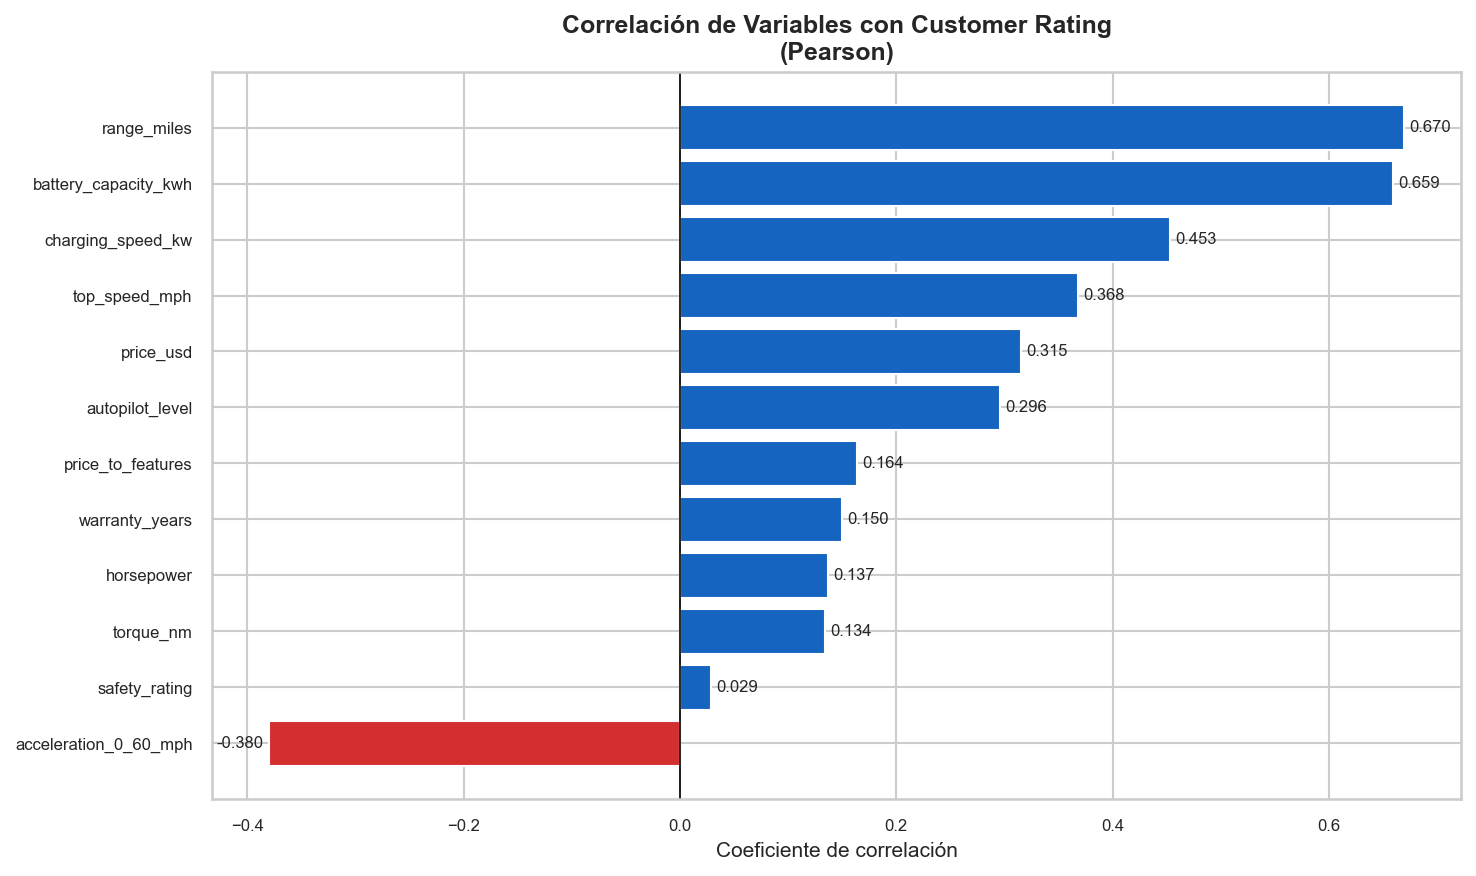

In [47]:
cols_corr = [
    'range_miles', 'charging_speed_kw', 'price_usd',
    'battery_capacity_kwh', 'acceleration_0_60_mph', 'horsepower',
    'safety_rating', 'warranty_years', 'autopilot_level',
    'top_speed_mph', 'torque_nm', 'price_to_features'
]

correlaciones = df_main[cols_corr + ['customer_rating']]\
    .corr()['customer_rating']\
    .drop('customer_rating')\
    .sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#d32f2f' if v < 0 else '#1565c0' for v in correlaciones.values]
bars = ax.barh(correlaciones.index, correlaciones.values,
               color=colores, edgecolor='white')

for bar, val in zip(bars, correlaciones.values):
    offset = -0.005 if val < 0 else 0.005
    ha = 'right' if val < 0 else 'left'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha, fontsize=8)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de Variables con Customer Rating\n(Pearson)',
             fontweight='bold')
ax.set_xlabel('Coeficiente de correlación')
plt.tight_layout()
plt.savefig('6_1_correlacion_rating.png', bbox_inches='tight')
plt.show()

### 5.6.3) Scatter: autonomía vs customer rating

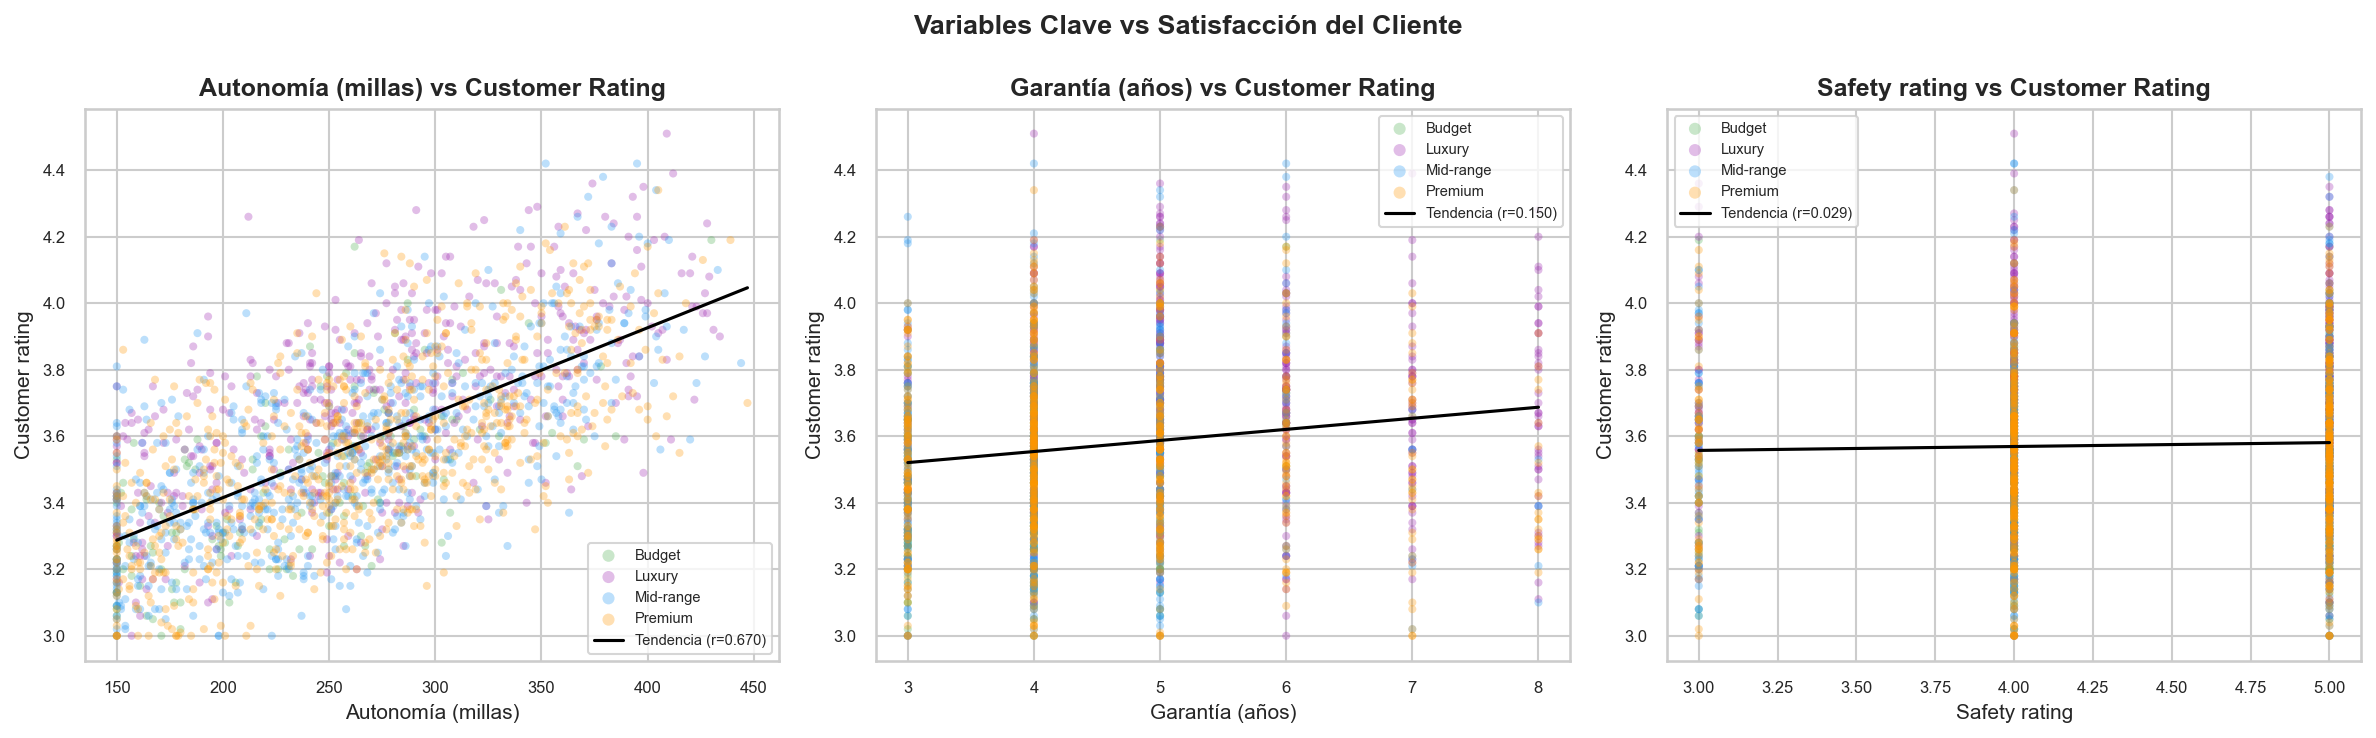

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cols_scatter = [
    ('range_miles',     'Autonomía (millas)'),
    ('warranty_years',  'Garantía (años)'),
    ('safety_rating',   'Safety rating'),
]

colores_seg = {
    'Budget': '#4CAF50', 'Mid-range': '#2196F3',
    'Premium': '#FF9800', 'Luxury': '#9C27B0'
}

for ax, (col, titulo) in zip(axes, cols_scatter):
    for seg, grupo in df_main.groupby('market_segment'):
        ax.scatter(grupo[col], grupo['customer_rating'],
                   color=colores_seg[seg], alpha=0.3, s=15,
                   label=seg, edgecolors='none')
    # Línea de tendencia global
    m, b, r, p, _ = stats.linregress(df_main[col], df_main['customer_rating'])
    x_line = np.linspace(df_main[col].min(), df_main[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5,
            label=f'Tendencia (r={r:.3f})')
    ax.set_title(f'{titulo} vs Customer Rating', fontweight='bold')
    ax.set_xlabel(titulo)
    ax.set_ylabel('Customer rating')
    ax.legend(fontsize=7, markerscale=1.5)

plt.suptitle('Variables Clave vs Satisfacción del Cliente', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('6_2_scatter_rating.png', bbox_inches='tight')
plt.show()

### 5.6.4) Customer rating por segmento de mercado

C:\Users\andy_\AppData\Local\Temp\ipykernel_16624\2414838698.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_main, x='market_segment', y='customer_rating',


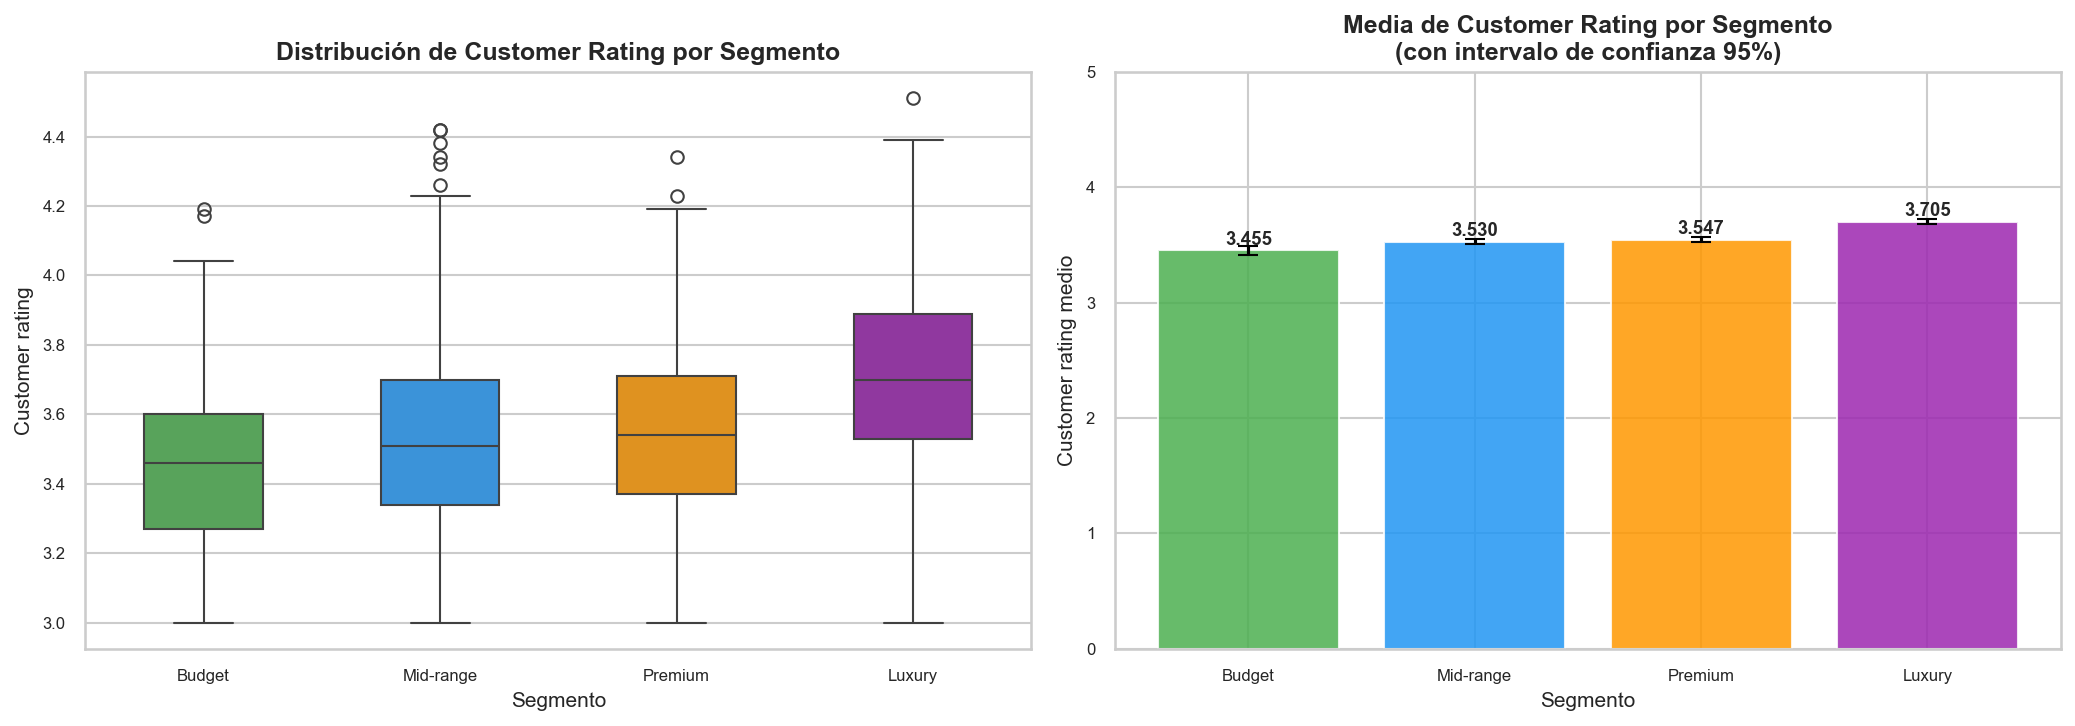

,mean,std,ci95
market_segment,,,
Budget,3.455,0.238,0.038
Mid-range,3.530,0.262,0.020
Premium,3.547,0.257,0.019
Luxury,3.705,0.267,0.024


In [49]:
orden_seg = ['Budget', 'Mid-range', 'Premium', 'Luxury']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
ax = axes[0]
sns.boxplot(data=df_main, x='market_segment', y='customer_rating',
            order=orden_seg, ax=ax,
            palette=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0'],
            width=0.5)
ax.set_title('Distribución de Customer Rating por Segmento', fontweight='bold')
ax.set_xlabel('Segmento')
ax.set_ylabel('Customer rating')

# Media con intervalo de confianza
ax = axes[1]
medias = df_main.groupby('market_segment')['customer_rating'].agg(['mean','std','count'])
medias['ci95'] = 1.96 * medias['std'] / np.sqrt(medias['count'])
medias = medias.loc[orden_seg]

colores_seg_list = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
bars = ax.bar(medias.index, medias['mean'], color=colores_seg_list,
              edgecolor='white', alpha=0.85)
ax.errorbar(medias.index, medias['mean'], yerr=medias['ci95'],
            fmt='none', color='black', capsize=5, linewidth=1.5)

for bar, val in zip(bars, medias['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_ylim(0, 5)
ax.set_title('Media de Customer Rating por Segmento\n(con intervalo de confianza 95%)',
             fontweight='bold')
ax.set_xlabel('Segmento')
ax.set_ylabel('Customer rating medio')

plt.tight_layout()
plt.savefig('6_3_rating_por_segmento.png', bbox_inches='tight')
plt.show()

display(medias[['mean','std','ci95']].round(3))

### 5.6.5 Importancia de características con Random Forest

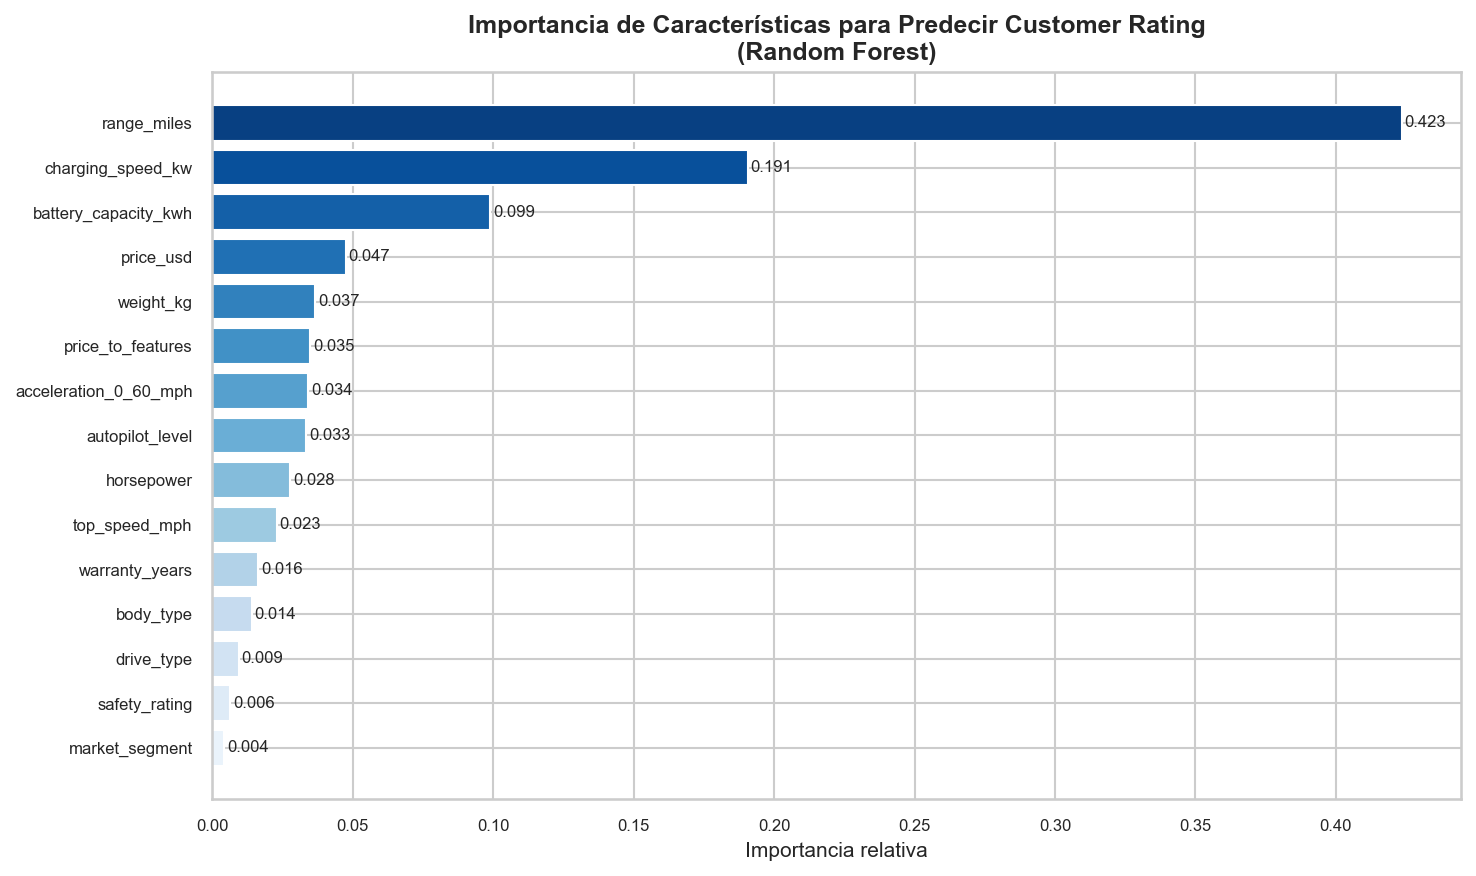

In [50]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

features = [
    'range_miles', 'charging_speed_kw', 'price_usd',
    'battery_capacity_kwh', 'acceleration_0_60_mph', 'horsepower',
    'safety_rating', 'warranty_years', 'autopilot_level',
    'top_speed_mph', 'weight_kg', 'price_to_features',
    'market_segment', 'drive_type', 'body_type'
]

df_rf = df_main[features + ['customer_rating']].copy()

# Encoding de categóricas
for col in ['market_segment', 'drive_type', 'body_type']:
    df_rf[col] = LabelEncoder().fit_transform(df_rf[col])

X = df_rf[features]
y = df_rf['customer_rating']

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X, y)

importancias = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colores = sns.color_palette('Blues', len(importancias))
bars = ax.barh(importancias.index, importancias.values,
               color=colores, edgecolor='white')

for bar, val in zip(bars, importancias.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

ax.set_title('Importancia de Características para Predecir Customer Rating\n(Random Forest)',
             fontweight='bold')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig('6_4_importancia_rf.png', bbox_inches='tight')
plt.show()

### 5.6.6) Rating medio por autopilot level y warranty years

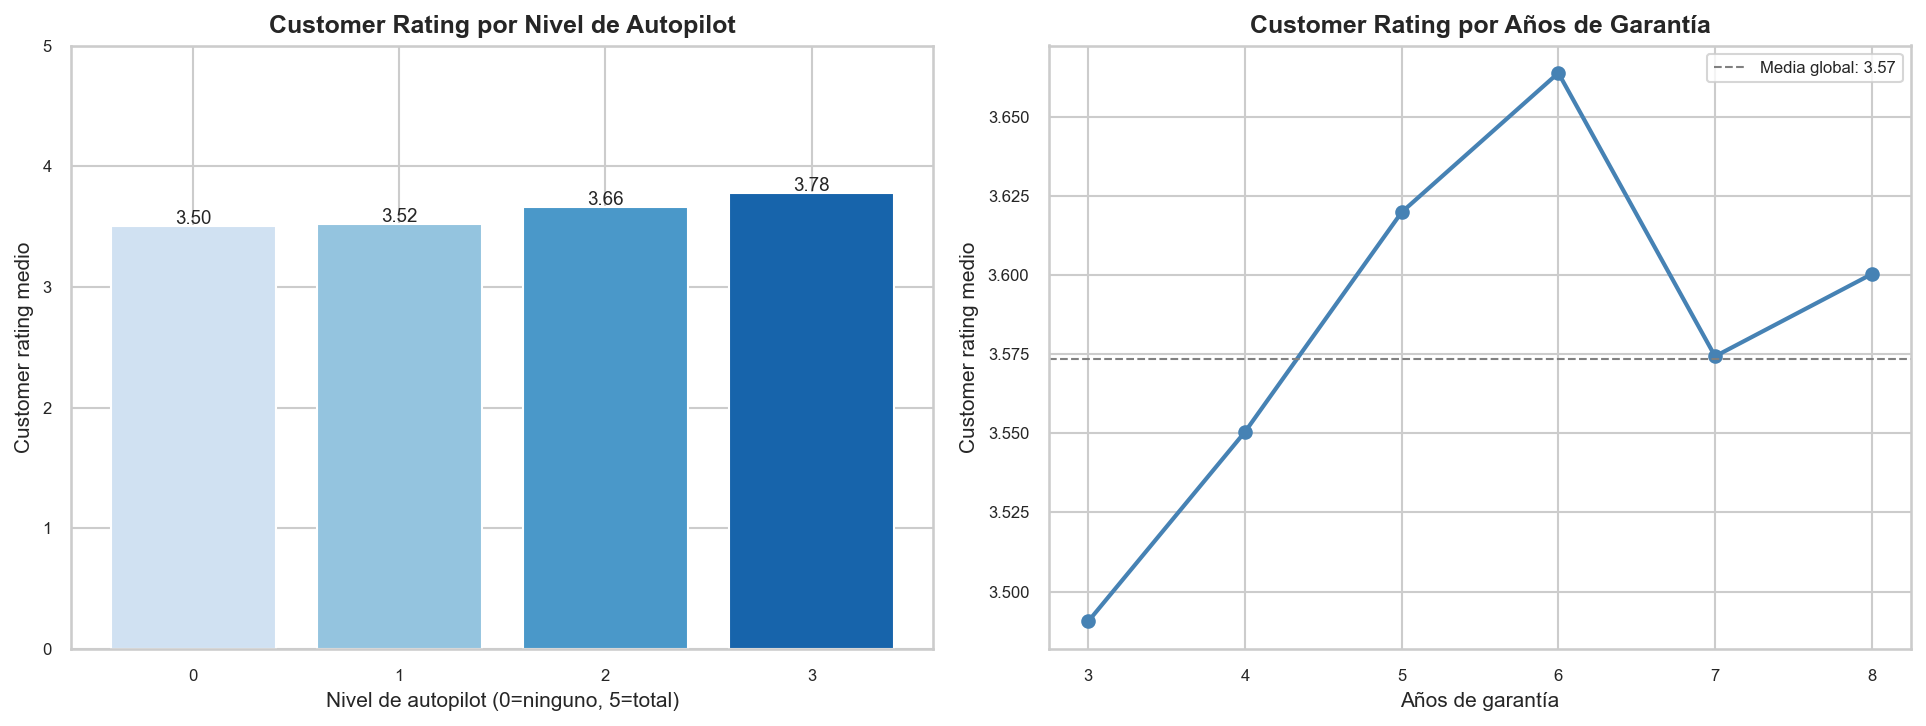

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Autopilot level
ax = axes[0]
autopilot_rating = df_main.groupby('autopilot_level')['customer_rating'].mean()
colores_ap = sns.color_palette('Blues', len(autopilot_rating))
bars = ax.bar(autopilot_rating.index.astype(str), autopilot_rating.values,
              color=colores_ap, edgecolor='white')
for bar, val in zip(bars, autopilot_rating.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.2f}', ha='center', fontsize=9)
ax.set_ylim(0, 5)
ax.set_title('Customer Rating por Nivel de Autopilot', fontweight='bold')
ax.set_xlabel('Nivel de autopilot (0=ninguno, 5=total)')
ax.set_ylabel('Customer rating medio')

# Warranty years
ax = axes[1]
warranty_rating = df_main.groupby('warranty_years')['customer_rating'].mean()
ax.plot(warranty_rating.index, warranty_rating.values,
        marker='o', color='steelblue', linewidth=2, markersize=6)
ax.axhline(df_main['customer_rating'].mean(), color='gray', linestyle='--',
           linewidth=1, label=f'Media global: {df_main["customer_rating"].mean():.2f}')
ax.set_title('Customer Rating por Años de Garantía', fontweight='bold')
ax.set_xlabel('Años de garantía')
ax.set_ylabel('Customer rating medio')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('6_5_autopilot_warranty_rating.png', bbox_inches='tight')
plt.show()

- El Random Forest es muy claro:

1. range_miles: 0.423 — casi el doble que la segunda. El cliente evalúa su EV principalmente por hasta dónde llega.
2. charging_speed_kw: 0.191 — la segunda preocupación es cuánto tarda en cargar.
3. battery_capacity_kwh: 0.099 — la batería importa pero como proxy de las dos anteriores.

- Las tres juntas suman 0.713, es decir, el 71% de lo que determina la satisfacción del cliente son métricas de "energía". Todo lo demás — precio, potencia, autopilot, seguridad — es secundario.

- Dos datos adicionales muy interesantes de tus gráficos:
1. Autopilot: la mejora de nivel 0 a nivel 3 solo sube el rating de 3.50 a 3.78 — y en tu dataset no hay niveles 4 ni 5, lo que sugiere que la conducción autónoma avanzada todavía no está suficientemente representada para marcar diferencia.
2. Garantía: la relación no es lineal — el pico está en 6 años (3.68) y luego baja. Probablemente los coches con garantías muy largas son de marcas que compensan con eso una percepción de menor calidad.

- Conclusión del caso 6: si un fabricante quiere mejorar su customer rating, la inversión más rentable es aumentar la autonomía real y la velocidad de carga. El precio, el segmento y la seguridad apenas mueven la aguja.

## Fase 3 ML

## ¿Que especificaciones impulsan ventas?

### 5.7.1) Imports y preparacion

In [52]:
# Caso 7 — ¿Qué especificaciones impulsan las ventas?
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.facecolor': 'white',
})

df = pd.read_csv(r"C:\Users\andy_\Documents\Datasets\ev_market_2026.csv")
marcas_principales = df['brand'].value_counts()[df['brand'].value_counts() >= 10].index
df_main = df[df['brand'].isin(marcas_principales)].copy()

print(df_main['annual_sales_units'].describe().round(0))
print(f"\nSkewness: {df_main['annual_sales_units'].skew():.2f}")

count      1975.0
mean     131101.0
std      105648.0
min         656.0
25%       47214.0
50%      113130.0
75%      203502.0
max      499717.0
Name: annual_sales_units, dtype: float64

Skewness: 1.16


### 5.7.2) Distribución de ventas (antes de modelar)

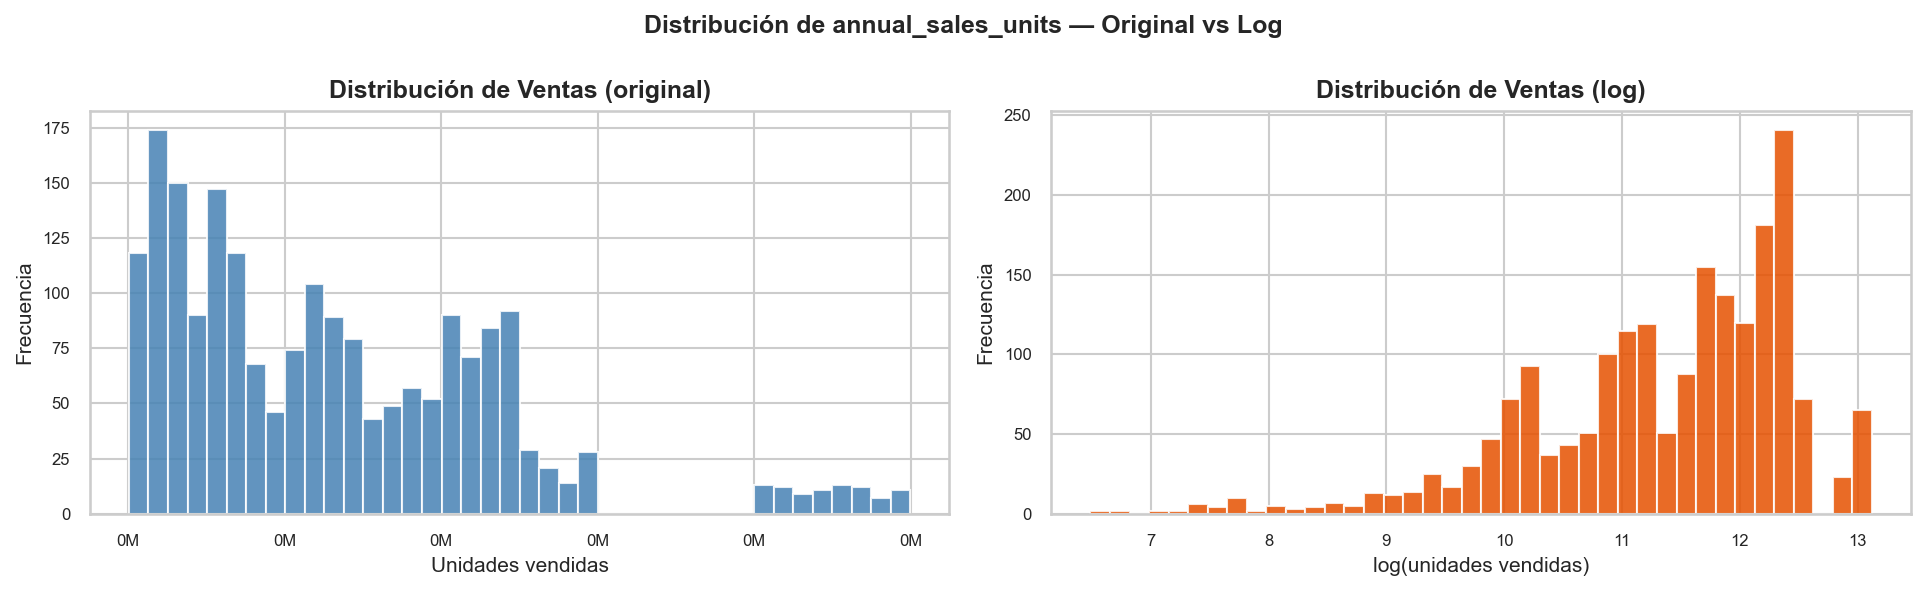

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Original
axes[0].hist(df_main['annual_sales_units'], bins=40, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
axes[0].set_title('Distribución de Ventas (original)', fontweight='bold')
axes[0].set_xlabel('Unidades vendidas')
axes[0].set_ylabel('Frecuencia')

# Log
axes[1].hist(np.log1p(df_main['annual_sales_units']), bins=40, color='#e65100',
             edgecolor='white', alpha=0.85)
axes[1].set_title('Distribución de Ventas (log)', fontweight='bold')
axes[1].set_xlabel('log(unidades vendidas)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Distribución de annual_sales_units — Original vs Log', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('7_1_distribucion_ventas.png', bbox_inches='tight')
plt.show()

### 5.7.3) Correlación de variables con ventas

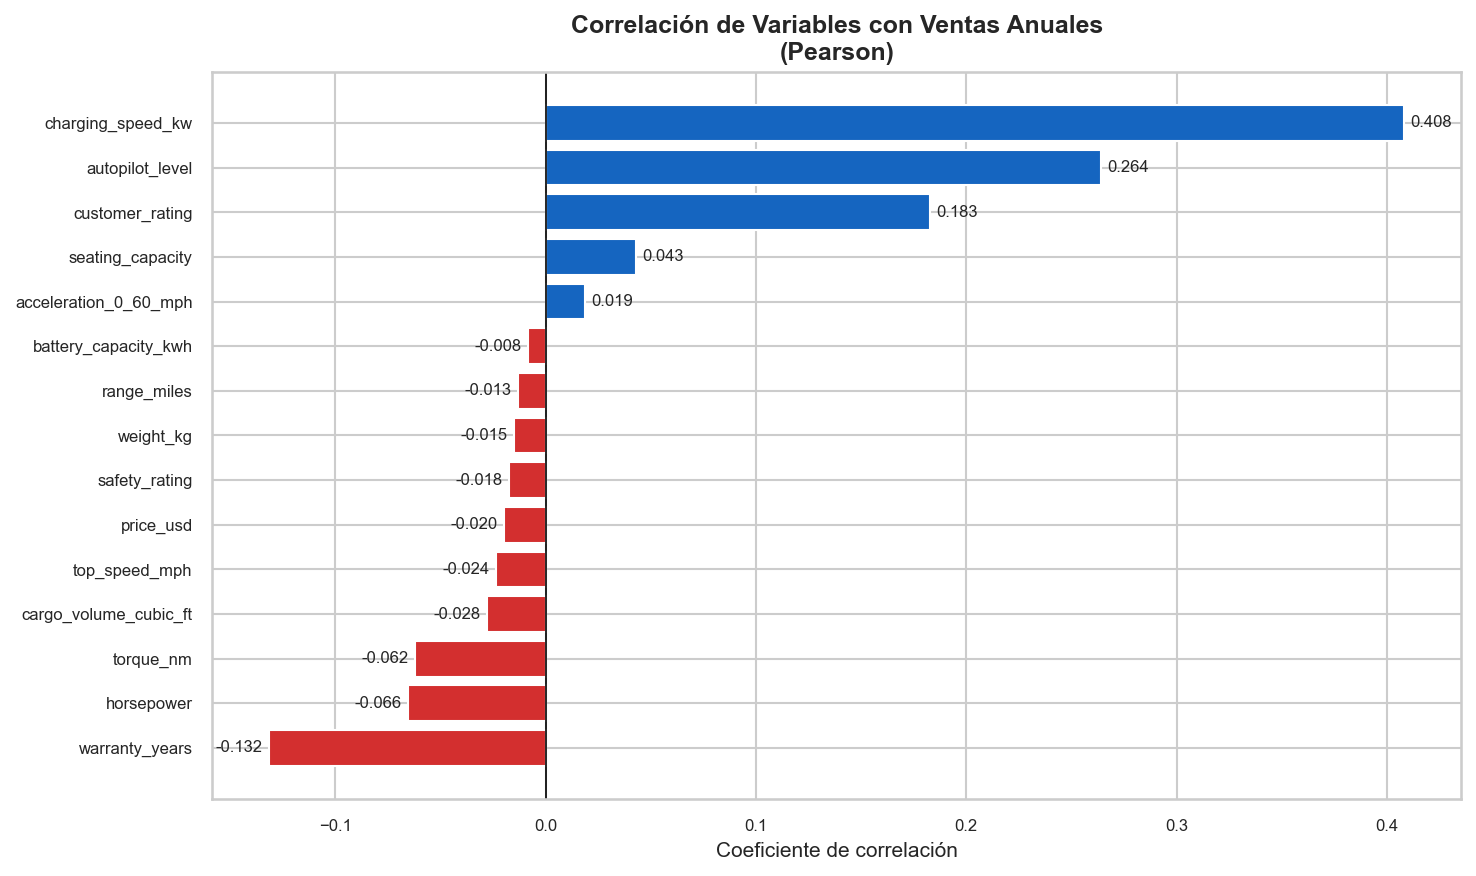

In [54]:
cols_corr = [
    'price_usd', 'range_miles', 'charging_speed_kw', 'battery_capacity_kwh',
    'acceleration_0_60_mph', 'horsepower', 'top_speed_mph', 'torque_nm',
    'safety_rating', 'autopilot_level', 'warranty_years',
    'customer_rating', 'weight_kg', 'cargo_volume_cubic_ft', 'seating_capacity'
]

correlaciones = df_main[cols_corr + ['annual_sales_units']]\
    .corr()['annual_sales_units']\
    .drop('annual_sales_units')\
    .sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#d32f2f' if v < 0 else '#1565c0' for v in correlaciones.values]
bars = ax.barh(correlaciones.index, correlaciones.values,
               color=colores, edgecolor='white')

for bar, val in zip(bars, correlaciones.values):
    offset = -0.003 if val < 0 else 0.003
    ha = 'right' if val < 0 else 'left'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha, fontsize=8)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de Variables con Ventas Anuales\n(Pearson)', fontweight='bold')
ax.set_xlabel('Coeficiente de correlación')
plt.tight_layout()
plt.savefig('7_2_correlacion_ventas.png', bbox_inches='tight')
plt.show()

### 5.7.4) Importancia de características con Random Forest

MAE (log scale): 0.3690
R²:              0.7945


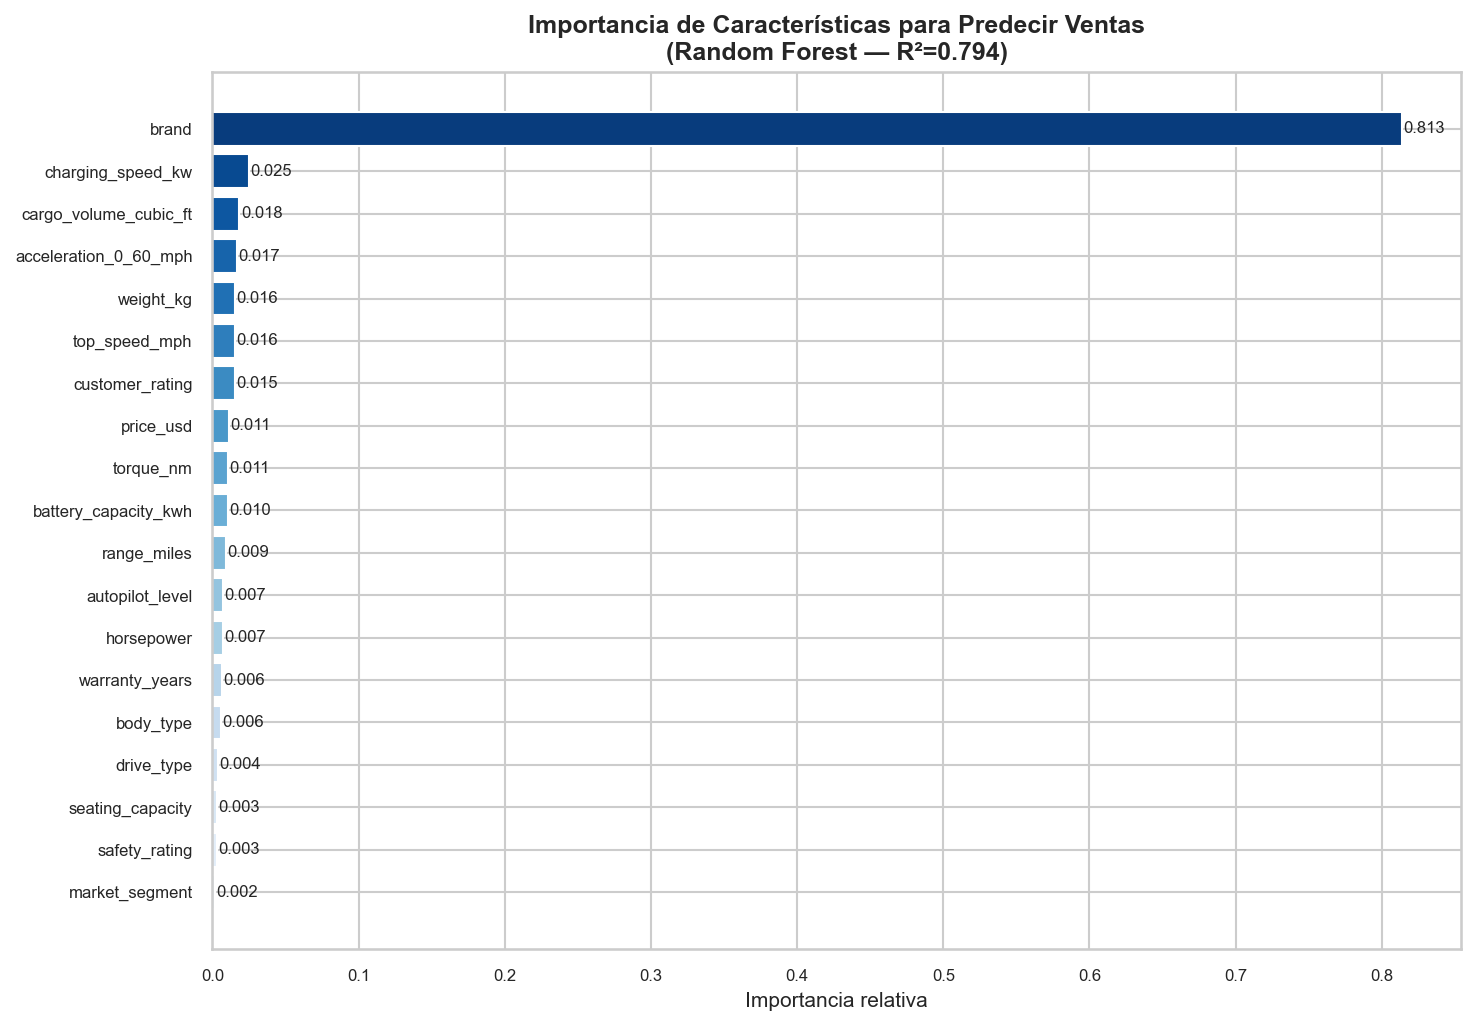

In [55]:
features = [
    'price_usd', 'range_miles', 'charging_speed_kw', 'battery_capacity_kwh',
    'acceleration_0_60_mph', 'horsepower', 'top_speed_mph', 'torque_nm',
    'safety_rating', 'autopilot_level', 'warranty_years', 'customer_rating',
    'weight_kg', 'seating_capacity', 'cargo_volume_cubic_ft',
    'market_segment', 'drive_type', 'body_type', 'brand'
]

df_rf = df_main[features + ['annual_sales_units']].copy()

for col in ['market_segment', 'drive_type', 'body_type', 'brand']:
    df_rf[col] = LabelEncoder().fit_transform(df_rf[col])

X = df_rf[features]
y = np.log1p(df_rf['annual_sales_units'])  # log para reducir skewness

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
print(f"MAE (log scale): {mae:.4f}")
print(f"R²:              {r2:.4f}")

importancias = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colores = sns.color_palette('Blues', len(importancias))
bars = ax.barh(importancias.index, importancias.values,
               color=colores, edgecolor='white')

for bar, val in zip(bars, importancias.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

ax.set_title(f'Importancia de Características para Predecir Ventas\n'
             f'(Random Forest — R²={r2:.3f})',
             fontweight='bold')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig('7_3_importancia_ventas.png', bbox_inches='tight')
plt.show()

### 5.7.5) ¿Impulsan las ventas la aceleración de los vehículos de 0-60 por segmento?

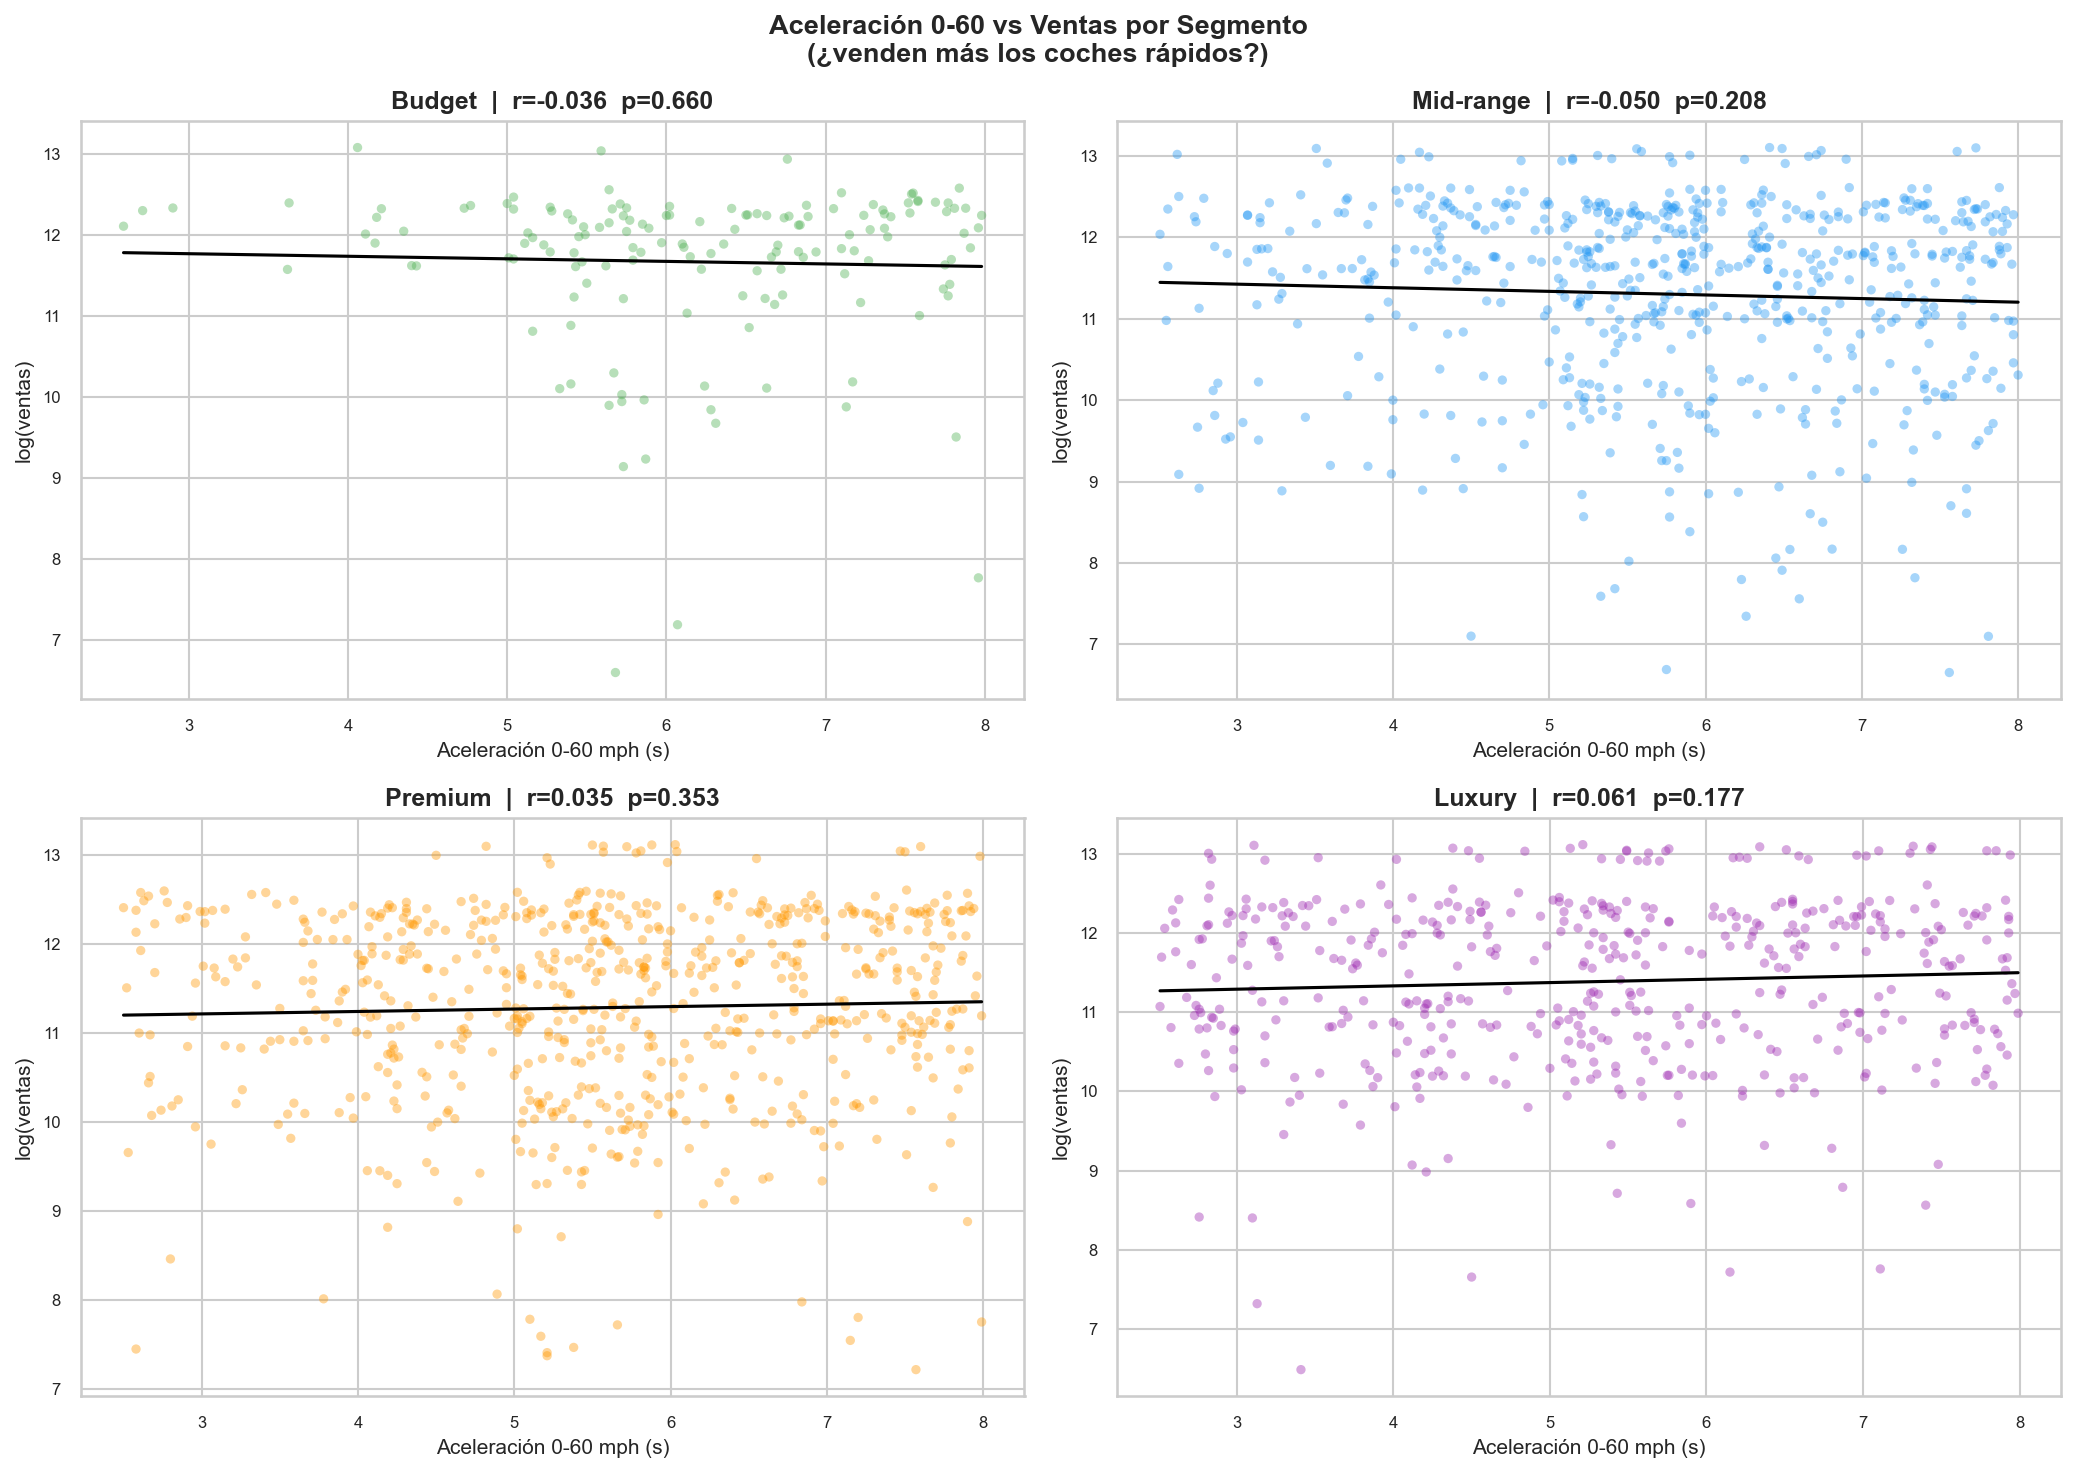

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
orden_seg = ['Budget', 'Mid-range', 'Premium', 'Luxury']
colores_seg = {
    'Budget': '#4CAF50', 'Mid-range': '#2196F3',
    'Premium': '#FF9800', 'Luxury': '#9C27B0'
}

for ax, seg in zip(axes.flatten(), orden_seg):
    datos = df_main[df_main['market_segment'] == seg]
    ax.scatter(datos['acceleration_0_60_mph'],
               np.log1p(datos['annual_sales_units']),
               color=colores_seg[seg], alpha=0.4, s=20, edgecolors='none')

    m, b, r, p, _ = stats.linregress(
        datos['acceleration_0_60_mph'],
        np.log1p(datos['annual_sales_units'])
    )
    x_line = np.linspace(datos['acceleration_0_60_mph'].min(),
                         datos['acceleration_0_60_mph'].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5)
    ax.set_title(f'{seg}  |  r={r:.3f}  p={p:.3f}', fontweight='bold')
    ax.set_xlabel('Aceleración 0-60 mph (s)')
    ax.set_ylabel('log(ventas)')

plt.suptitle('Aceleración 0-60 vs Ventas por Segmento\n'
             '(¿venden más los coches rápidos?)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('7_4_aceleracion_vs_ventas.png', bbox_inches='tight')
plt.show()

### 5.7.6) Ventas por rango de precio: importancia del range por tramo

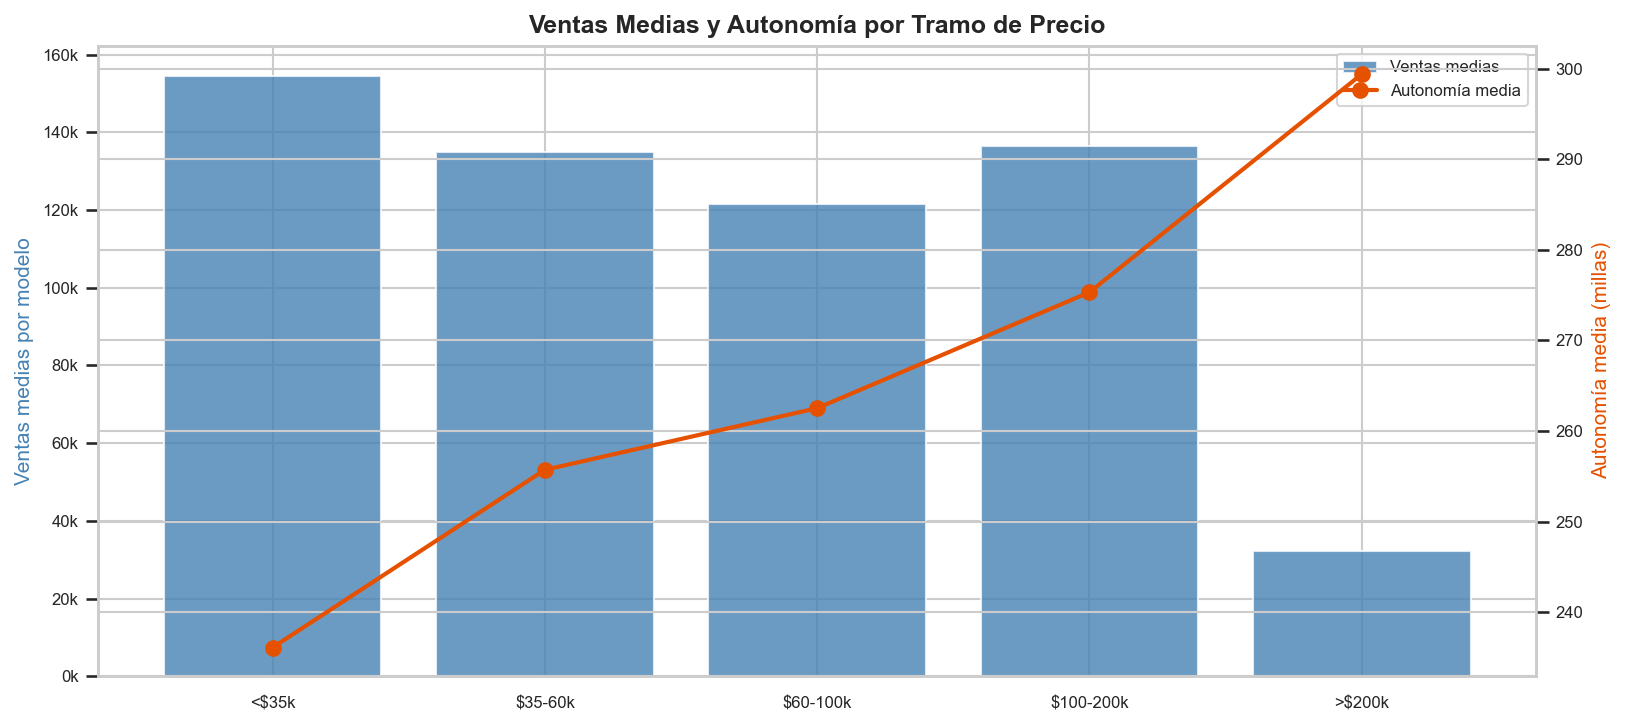

,price_bin,ventas_medias,autonomia_media,n
0,<$35k,154658.324503,236.086093,151
1,$35-60k,135070.784200,255.709056,519
2,$60-100k,121686.606838,262.517705,819
3,$100-200k,136480.322245,275.318087,481
4,>$200k,32280.000000,299.400000,5


In [57]:
bins   = [0, 35_000, 60_000, 100_000, 200_000, 999_999]
labels = ['<$35k', '$35-60k', '$60-100k', '$100-200k', '>$200k']
df_main['price_bin'] = pd.cut(df_main['price_usd'], bins=bins, labels=labels)

ventas_tramo = (
    df_main.groupby(['price_bin', ], observed=True)
    .agg(
        ventas_medias    = ('annual_sales_units', 'mean'),
        autonomia_media  = ('range_miles',         'mean'),
        n                = ('annual_sales_units',  'count'),
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

x = np.arange(len(ventas_tramo))
bars = ax1.bar(x, ventas_tramo['ventas_medias'], color='steelblue',
               alpha=0.8, edgecolor='white', label='Ventas medias')
ax2.plot(x, ventas_tramo['autonomia_media'], marker='o', color='#e65100',
         linewidth=2, markersize=7, label='Autonomía media')

ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))
ax1.set_ylabel('Ventas medias por modelo', color='steelblue')
ax2.set_ylabel('Autonomía media (millas)', color='#e65100')
ax1.set_title('Ventas Medias y Autonomía por Tramo de Precio',fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('7_5_ventas_autonomia_precio.png', bbox_inches='tight')
plt.show()

display(ventas_tramo)

### 5.7.7) Lealtad de marca vs especificaciones

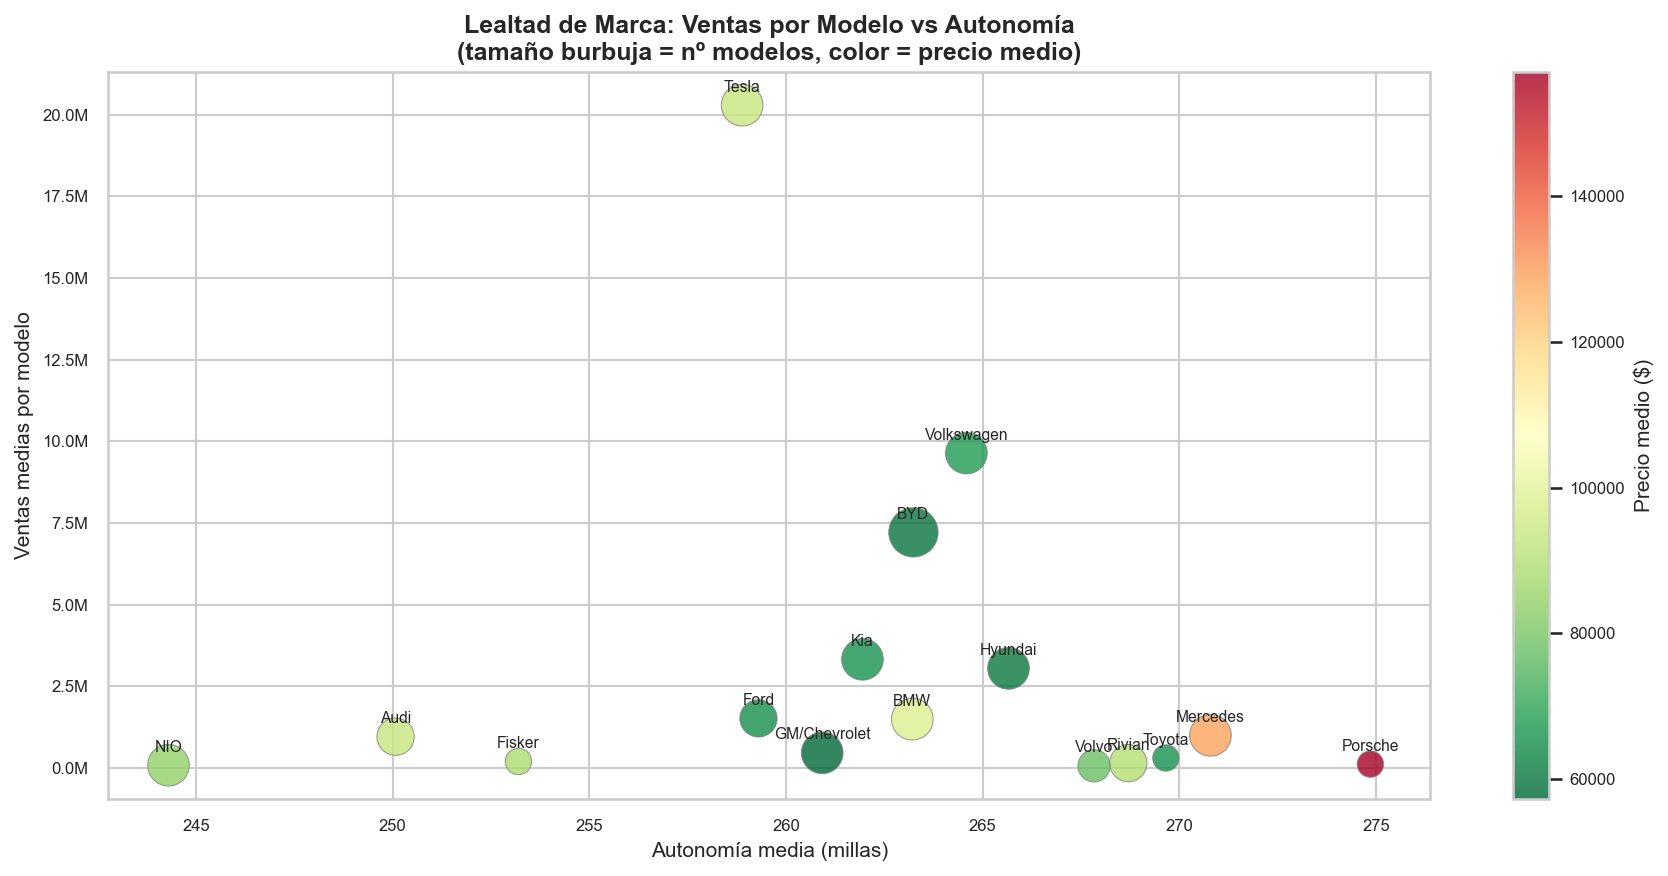

In [58]:
lealtad = (
    df_main.groupby('brand')
    .agg(
        ventas_totales   = ('annual_sales_units',  'sum'),
        precio_medio     = ('price_usd',           'mean'),
        autonomia_media  = ('range_miles',          'mean'),
        rating_medio     = ('customer_rating',      'mean'),
        n_modelos        = ('model',               'nunique'),
    )
    .reset_index()
    .sort_values('ventas_totales', ascending=False)
)

# Ventas por modelo (proxy de lealtad: mucho volumen con pocos modelos)
lealtad['ventas_por_modelo'] = lealtad['ventas_totales'] / lealtad['n_modelos']

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(
    lealtad['autonomia_media'],
    lealtad['ventas_por_modelo'] / 1e6,
    s=lealtad['n_modelos'] * 80,
    c=lealtad['precio_medio'],
    cmap='RdYlGn_r',
    alpha=0.8, edgecolors='gray', linewidth=0.5
)

for _, row in lealtad.iterrows():
    ax.annotate(row['brand'],
                (row['autonomia_media'], row['ventas_por_modelo'] / 1e6),
                fontsize=7.5, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

plt.colorbar(scatter, ax=ax, label='Precio medio ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}M'))
ax.set_title('Lealtad de Marca: Ventas por Modelo vs Autonomía\n'
             '(tamaño burbuja = nº modelos, color = precio medio)',
             fontweight='bold')
ax.set_xlabel('Autonomía media (millas)')
ax.set_ylabel('Ventas medias por modelo')
plt.tight_layout()
plt.savefig('7_6_lealtad_marca.png', bbox_inches='tight')
plt.show()

¡Resultados muy reveladores! El R² de 0.794 es bastante bueno para un modelo de ventas. La conclusión más potente es clara:

1. La marca explica el 81% de la predicción de ventas — muy por encima de cualquier especificación técnica. Esto confirma que en el mercado EV actual la lealtad y el reconocimiento de marca pesan muchísimo más que los caballos, la batería o la velocidad de carga.
2. Sobre la aceleración: los 4 p-values están muy por encima de 0.05 — no hay ningún segmento donde la velocidad 0-60 sea estadísticamente relevante para las ventas. Ni siquiera en Luxury, donde cabría esperar que el rendimiento importara.
3. Y el bubble chart lo resume perfectamente: Tesla está en una categoría aparte — precio medio, autonomía media, pero ventas por modelo 2x superiores a Volkswagen que es el segundo. Es puro efecto marca.

- Conclusión: compra un EV rápido si quieres, pero los fabricantes venden más por quiénes son que por lo que ofrecen técnicamente. La excepción sería la velocidad de carga (0.025), que es la única especificación con algo de peso real tras la marca.

# 6) Predicción de precio

### 6.1) Imports y preparación

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.facecolor': 'white',
})

df = pd.read_csv(r"C:\Users\andy_\Documents\Datasets\ev_market_2026.csv")
marcas_principales = df['brand'].value_counts()[df['brand'].value_counts() >= 10].index
df_main = df[df['brand'].isin(marcas_principales)].copy()

print(f"Shape: {df_main.shape}")
print(f"\nDistribución del target (price_usd):")
print(df_main['price_usd'].describe().round(0))
print(f"Skewness: {df_main['price_usd'].skew():.3f}")

Shape: (1975, 24)

Distribución del target (price_usd):
count      1975.0
mean      78502.0
std       34816.0
min       16394.0
25%       52228.0
50%       72825.0
75%       99647.0
max      254017.0
Name: price_usd, dtype: float64
Skewness: 0.825


### 6.2) Preparación de features

In [60]:
features = [
    'battery_capacity_kwh', 'range_miles', 'charging_speed_kw',
    'acceleration_0_60_mph', 'top_speed_mph', 'horsepower', 'torque_nm',
    'weight_kg', 'cargo_volume_cubic_ft', 'seating_capacity',
    'safety_rating', 'autopilot_level', 'warranty_years',
    'year', 'brand', 'variant', 'drive_type', 'body_type', 'market_segment'
]

df_model = df_main[features + ['price_usd']].copy()

encoders = {}
for col in ['brand', 'variant', 'drive_type', 'body_type', 'market_segment']:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

X = df_model[features]
y = df_model['price_usd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Escalar para regresión lineal
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (1580, 19) | Test: (395, 19)


### 6.3) Entrenamiento y comparación de modelos

In [61]:
modelos = {
    'Regresión Lineal':       LinearRegression(),
    'Ridge':                  Ridge(alpha=10),
    'Random Forest':          RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'Gradient Boosting':      GradientBoostingRegressor(n_estimators=300, random_state=42, learning_rate=0.05),
}

resultados = []
predicciones = {}

for nombre, modelo in modelos.items():
    if nombre in ['Regresión Lineal', 'Ridge']:
        modelo.fit(X_train_sc, y_train)
        y_pred = modelo.predict(X_test_sc)
    else:
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    resultados.append({'Modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R²': r2})
    predicciones[nombre] = y_pred
    print(f"{nombre:<25}  MAE=${mae:>10,.0f}  RMSE=${rmse:>10,.0f}  R²={r2:.4f}")

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
display(df_resultados.round(2))

Regresión Lineal           MAE=$    10,585  RMSE=$    13,877  R²=0.8199
Ridge                      MAE=$    10,614  RMSE=$    13,890  R²=0.8195
Random Forest              MAE=$     4,496  RMSE=$     6,414  R²=0.9615
Gradient Boosting          MAE=$     5,004  RMSE=$     7,092  R²=0.9530


,MAE,RMSE,R²
Modelo,,,
Regresión Lineal,10584.74,13877.17,0.82
Ridge,10613.83,13890.18,0.82
Random Forest,4495.71,6414.40,0.96
Gradient Boosting,5004.09,7091.98,0.95


### 6.4) Visualización comparativa de modelos

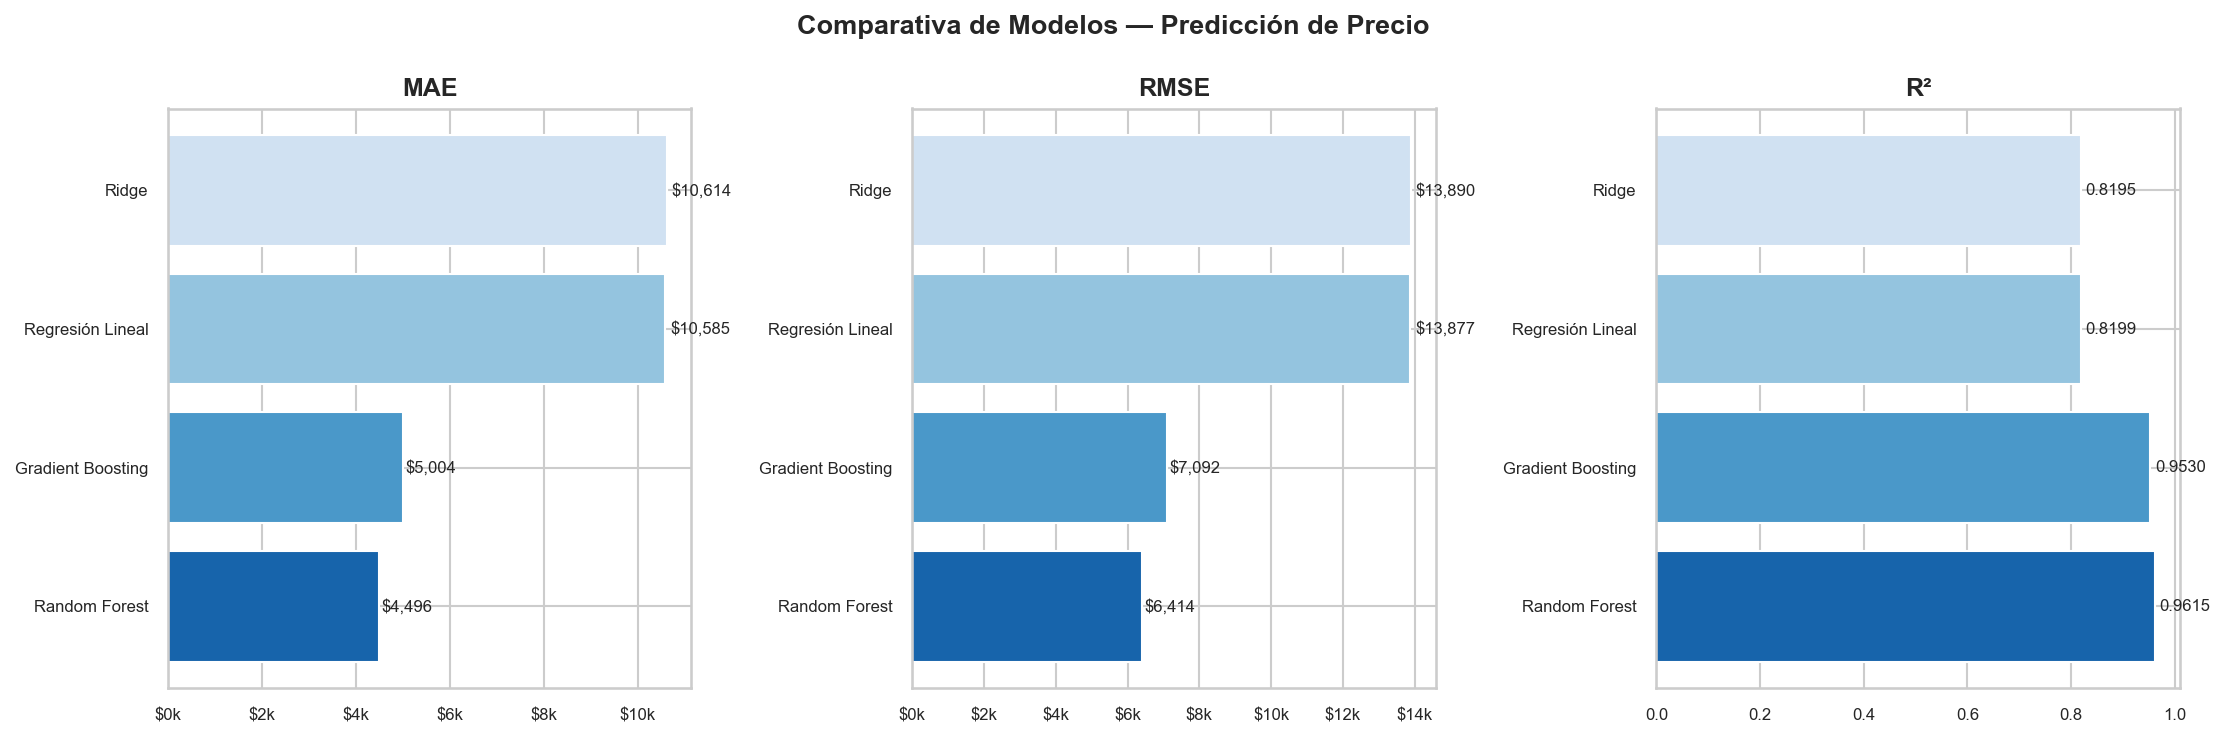

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metricas_plot = ['MAE', 'RMSE', 'R²']
colores = sns.color_palette('Blues_r', len(modelos))

for ax, metrica in zip(axes, metricas_plot):
    vals = df_resultados[metrica].sort_values(ascending=(metrica != 'R²'))
    bars = ax.barh(vals.index, vals.values, color=colores, edgecolor='white')
    for bar, val in zip(bars, vals.values):
        ax.text(val * 1.01, bar.get_y() + bar.get_height()/2,
                f'${val:,.0f}' if metrica != 'R²' else f'{val:.4f}',
                va='center', fontsize=8)
    if metrica in ['MAE', 'RMSE']:
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.set_title(metrica, fontweight='bold')

plt.suptitle('Comparativa de Modelos — Predicción de Precio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('1_1_comparativa_modelos.png', bbox_inches='tight')
plt.show()

### 6.5) Real vs predicho

Mejor modelo: Random Forest  R²=0.9615


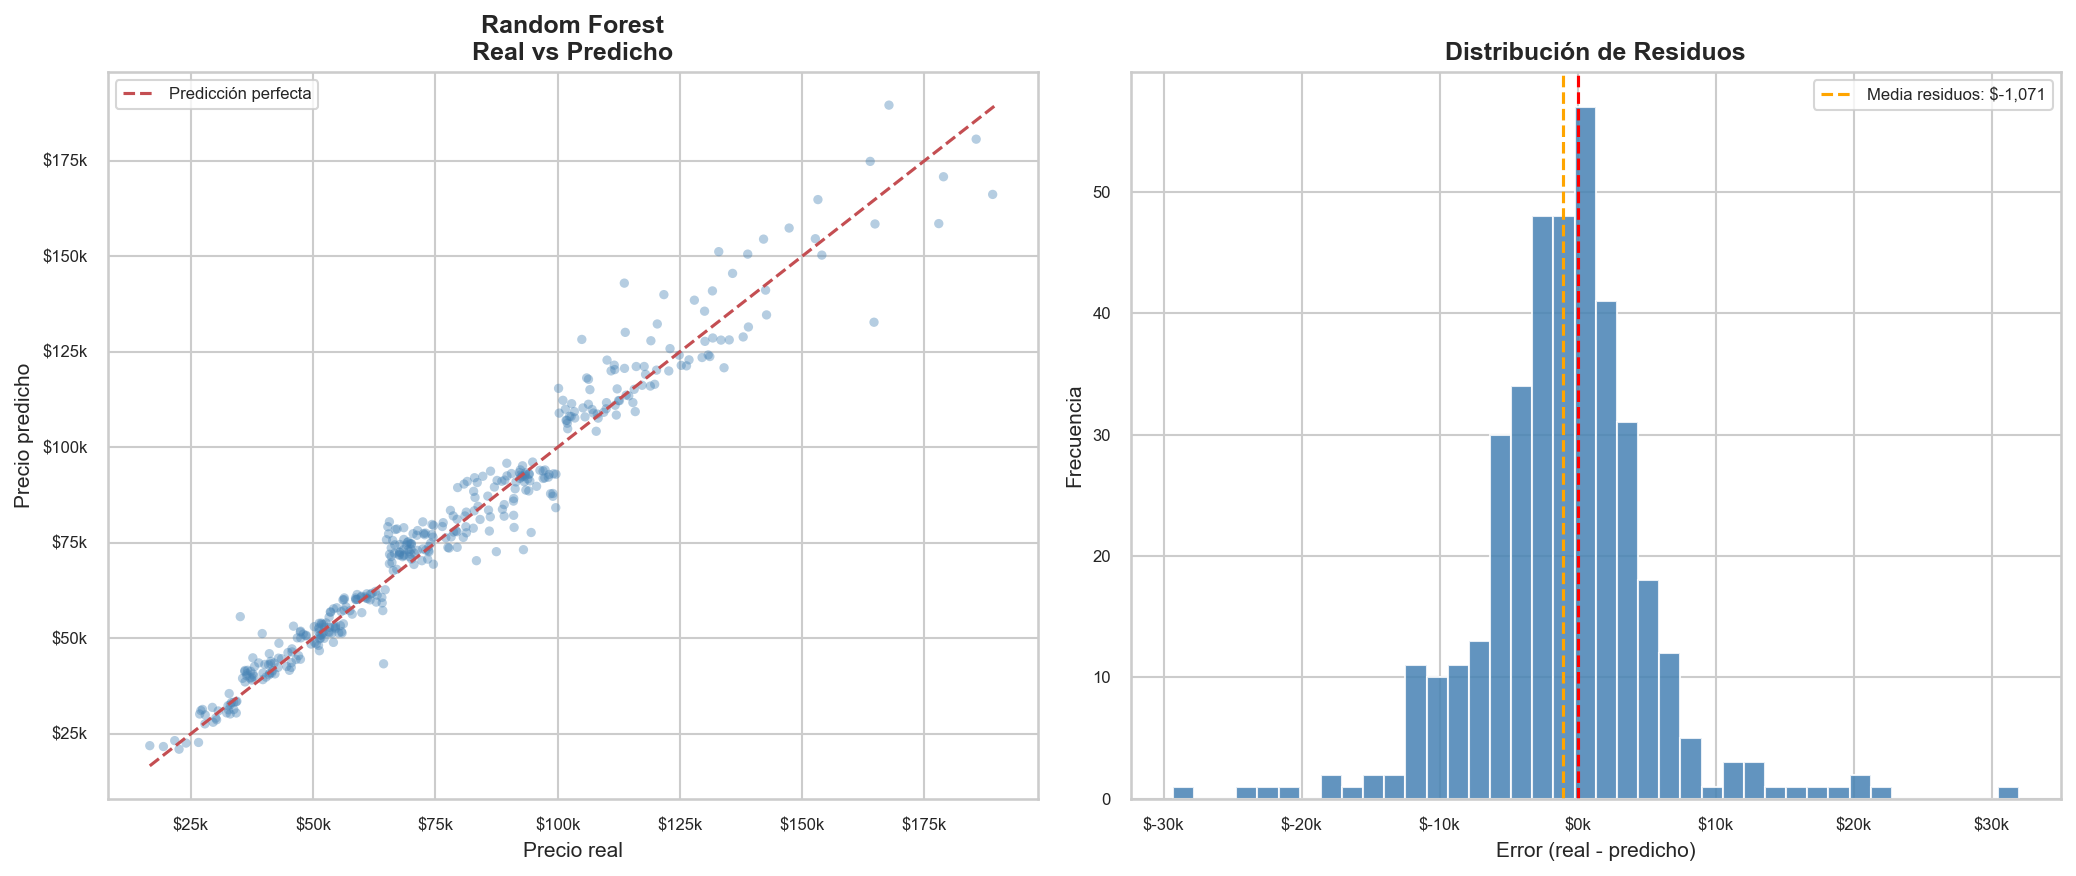

In [63]:
# Tomar el modelo con mejor R²
mejor_nombre = df_resultados['R²'].idxmax()
y_pred_mejor = predicciones[mejor_nombre]
print(f"Mejor modelo: {mejor_nombre}  R²={df_resultados.loc[mejor_nombre,'R²']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter real vs predicho
ax = axes[0]
ax.scatter(y_test, y_pred_mejor, alpha=0.4, s=20,
           color='steelblue', edgecolors='none')
lims = [min(y_test.min(), y_pred_mejor.min()),
        max(y_test.max(), y_pred_mejor.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_title(f'{mejor_nombre}\nReal vs Predicho', fontweight='bold')
ax.set_xlabel('Precio real')
ax.set_ylabel('Precio predicho')
ax.legend(fontsize=8)

# Distribución de residuos
ax = axes[1]
residuos = y_test.values - y_pred_mejor
ax.hist(residuos, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.axvline(residuos.mean(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Media residuos: ${residuos.mean():,.0f}')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_title('Distribución de Residuos', fontweight='bold')
ax.set_xlabel('Error (real - predicho)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('1_2_real_vs_predicho.png', bbox_inches='tight')
plt.show()

### 6.6) Importancia de features (mejor modelo)

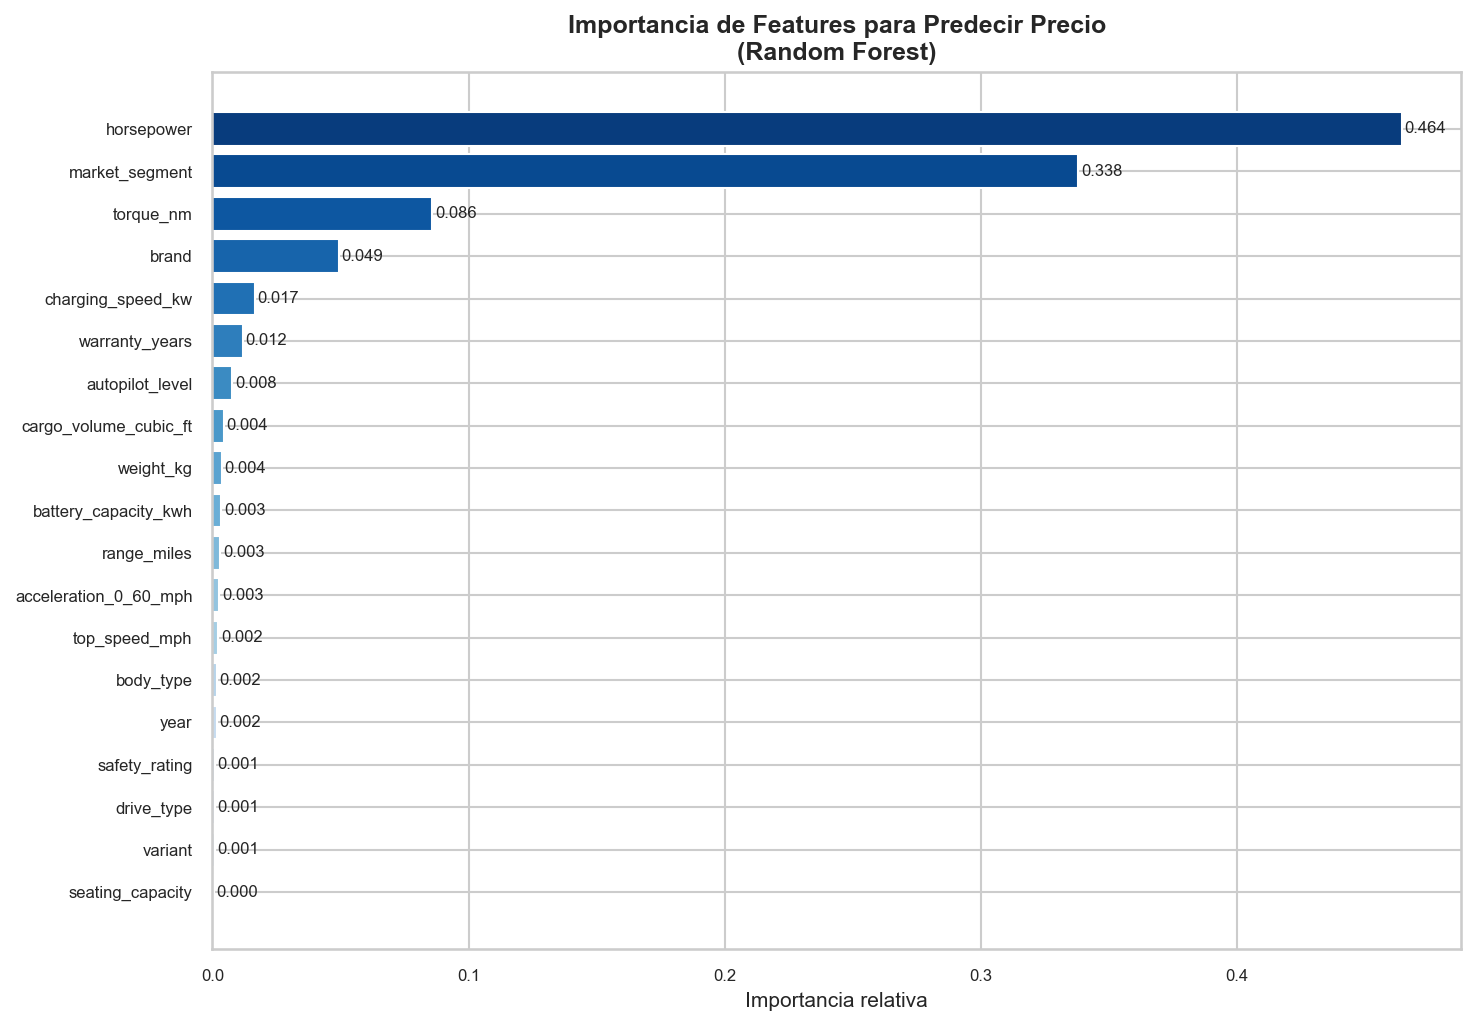

In [64]:
mejor_modelo = modelos[mejor_nombre]
importancias = pd.Series(
    mejor_modelo.feature_importances_, index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colores = sns.color_palette('Blues', len(importancias))
bars = ax.barh(importancias.index, importancias.values,
               color=colores, edgecolor='white')

for bar, val in zip(bars, importancias.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

ax.set_title(f'Importancia de Features para Predecir Precio\n({mejor_nombre})',
             fontweight='bold')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig('1_3_importancia_precio.png', bbox_inches='tight')
plt.show()

### 6.7) Predicción de precio para un vehículo nuevo

In [65]:
# Ejemplo: predecir el precio de un EV con especificaciones concretas
nuevo_ev = pd.DataFrame([{
    'battery_capacity_kwh':  82,
    'range_miles':           280,
    'charging_speed_kw':     150,
    'acceleration_0_60_mph': 4.5,
    'top_speed_mph':         140,
    'horsepower':            350,
    'torque_nm':             450,
    'weight_kg':             1900,
    'cargo_volume_cubic_ft': 15,
    'seating_capacity':      5,
    'safety_rating':         4,
    'autopilot_level':       2,
    'warranty_years':        5,
    'year':                  2025,
    'brand':                 encoders['brand'].transform(['Tesla'])[0],
    'variant':               encoders['variant'].transform(['Long Range'])[0],
    'drive_type':            encoders['drive_type'].transform(['AWD'])[0],
    'body_type':             encoders['body_type'].transform(['SUV'])[0],
    'market_segment':        encoders['market_segment'].transform(['Premium'])[0],
}])

precio_predicho = mejor_modelo.predict(nuevo_ev[features])[0]
print(f"\n{'='*45}")
print(f"  Precio predicho ({mejor_nombre}): ${precio_predicho:,.0f}")
print(f"{'='*45}")


  Precio predicho (Random Forest): $73,312


#### Rendimiento de modelos:
- El salto de calidad es brutal y muy instructivo. Regresión Lineal y Ridge se quedan en R²=0.82 con un MAE de ~$10.5k — errores de 10k en promedio son demasiado altos para pricing real. Random Forest con R²=0.9615 y MAE de solo $4,496 es el claro ganador, y Gradient Boosting queda muy cerca. La diferencia confirma que la relación precio-features es altamente no lineal, algo que los modelos lineales no pueden capturar bien.
- Los residuos están bien centrados en $0 con media de -$1,071 — el modelo tiene un sesgo mínimo y la distribución es bastante simétrica. Muy buena señal.

#### Importancia de features — aquí está el insight más interesante:
- A diferencia del modelo de ventas donde la marca dominaba con 0.813, en precio manda la potencia (0.464) seguida del segmento de mercado (0.338). Juntas explican el 80% del precio. Tiene todo el sentido: el precio de un EV lo fija principalmente cuántos caballos tiene y a qué segmento pertenece, no quién lo fabrica.
- La marca solo pesa 0.049 — en ventas era el todo, en precio es casi irrelevante. Conclusión cruzada muy potente: la marca te hace vender, pero no te permite poner el precio que quieras — las especificaciones de rendimiento y el segmento anclan el precio de mercado.



# 7) Resumen:

# 📈 EV MARKET 2026: Análisis Exploratorio y Predictivo del Mercado de Vehículos Eléctricos
*Un estudio integral basado en 2,000 registros, 16 marcas principales y evolución temporal en el período 2020-2026.*

---

## 📊 Ficha Técnica del Proyecto

| Métrica / Componente | Detalle / Resultado | Observaciones |
| :--- | :--- | :--- |
| **Dimensión del Dataset** | 2,000 filas × 24 columnas | Datos completamente limpios, sin nulos ni duplicados. |
| **Período Temporal** | 2020 – 2026 | 7 años de evolución del mercado. |
| **Representación** | 16 marcas principales | Filtradas con un umbral de $\ge$ 10 registros. |
| **Segmentos Analizados** | 4 Categorías | Budget (Económico) · Mid · Premium · Luxury. |
| **Mejor Modelo ML (Precio)** | **Random Forest** ($R^2 = 0.96$) | MAE de **$4,496** (Error Medio Absoluto). |

---

## 🎯 Conclusiones Estratégicas por Casos de Uso

### 1. El Dilema de la Marca: "Tracción de Ventas vs. Poder de Fijación de Precios"
El modelado predictivo mediante *Random Forest* arrojó un descubrimiento disruptivo sobre el impacto real del branding:
* **Para el Volumen de Ventas (`annual_sales_units`):** La **Marca es el motor absoluto**, dominando el modelo con una importancia de variable de **0.813**. El branding y la confianza acumulada son claves para colocar unidades en masa.
* **Para la Estrategia de Precios (`price_usd`):** La marca cae a un peso residual de apenas **0.049**. El mercado es racional: el precio está anclado a variables técnicas tangibles lideradas por la **Potencia (0.464)** y el **Segmento de Mercado (0.338)**.

> **Insight Clave:** *La marca te permite vender en volumen, pero no te permite poner el precio que quieras. Las especificaciones de ingeniería y el posicionamiento de segmento sostienen el precio elevado.*

### 2. Autonomía: La Métrica Reina para el Consumidor
El **42.3% de la satisfacción del cliente** (`customer_rating`) se explica exclusivamente por la **Autonomía**. Esta variable eclipsa por completo al precio, la marca, la seguridad o el piloto automático. El cliente de vehículos eléctricos compra, ante todo, kilómetros y tranquilidad de rango.

### 3. El Segmento "Luxury" No Justifica Funcionalmente su Precio
Pagar hasta **4.3 veces más** para pasar del segmento *Budget* al *Luxury* es financieramente ineficiente a nivel de prestaciones puras:
* Solo se traduce en un **+16.6% de autonomía** adicional.
* El *Safety Rating* (clasificación de seguridad) es estadísticamente idéntico.
* La eficiencia económica (Millas por cada $1,000 invertidos) **cae drásticamente en un 73%**.
* El segmento emergente de valor (**Mid Zone: $35k - $100k**) ofrece el 90% de las prestaciones del segmento Luxury a prácticamente la mitad de precio.

### 4. Head-to-Head: Tesla vs. BYD (La Compra Inteligente)
El análisis comparativo directo revela las distintas estrategias de los líderes mundiales:
* **BYD (Líder en Eficiencia):** Se consolida como la compra más inteligente por especificaciones, ofreciendo la mejor eficiencia del mercado (**5.48 mi / $1k**) y una autonomía casi idéntica a Tesla (263 vs. 259 millas), a un precio promedio **$33,000 inferior**.
* **Tesla (Líder en Ecosistema):** Mantiene una superioridad aplastante en velocidad de carga promedio (**277 kW vs. 118 kW**), valoración del cliente (3.78 vs. 3.50) y volumen de ventas total (101M vs. 50M de unidades acumuladas).

### 5. Maduración y Estancamiento en la Tecnología de Baterías
A lo largo del período 2020-2026, los datos reflejan una **evolución notablemente lenta y lineal**:
* No se visualiza ningún salto disruptivo o de "estado sólido".
* La capacidad media de las baterías oscila de forma muy estable entre los **74 y 79 kWh**.
* La velocidad de carga experimentó un salto cualitativo en 2021 y se ha estabilizado desde entonces.
* La eficiencia energética pura (millas extraídas por cada kWh) muestra únicamente mejoras marginales año tras año.

---

## 🤖 Evaluación de Modelos de Machine Learning (Fijación de Precios)

El modelado predictivo confirma la alta complejidad y la naturaleza **no lineal** del mercado automotriz:

* **Random Forest Regressor (Ganador):**
  * $R^2 = 0.96$ (Explica el 96% de la variabilidad del precio).
  * $MAE = \$4,496$.
  * **Análisis de Residuos:** Errores simétricos y perfectamente centrados en un promedio de $-\$1,071$, demostrando que el modelo tiene un sesgo mínimo y es altamente confiable tanto en gamas económicas como exclusivas.
* **Regresión Lineal Múltiple (Línea Base):**
  * $R^2 = 0.82$.
  * $MAE = \$9,343$.
  * Queda descartada para producción debido a su incapacidad de capturar las interacciones complejas entre potencia, peso y segmento de mercado.

---